Autor: Carlos González Carballo

La **Practica 3: Transfer Learning** consiste en escoger un dataset de HuggingFace y aplicar transfer learning para clasificar imágenes.


El dataset seleccionado es [Human Action Recognition](https://huggingface.co/datasets/Bingsu/Human_Action_Recognition/viewer/default/test?p=2&views%5B%5D=test).

La práctica comenzará con la importación de las librerías y el dataset. Continuará con el estudio del dataset y aplicación de técnicas de limpieza del dataset y balanceo del mismo. Luego, se aplicará transfer learning con diferentes configuraciones y se evaluará el rendimiento del modelo, con el objetivo de obtener un rendimiento óptimo.

# Importación de librerías

In [1]:
!pip install transformers datasets opencv-python matplotlib scikit-learn pandas

In [2]:
from datasets import load_dataset, DatasetDict
import matplotlib.pyplot as plt
import pandas as pd
import cv2
from PIL import Image
import os
from dotenv import load_dotenv
import seaborn as sns
from collections import Counter
import math
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications import vgg16, vgg19, efficientnet, efficientnet_v2
from tensorflow.keras.optimizers import Adam, SGD
from keras.layers import Dense, Flatten, Dropout, BatchNormalization, GlobalAveragePooling2D
from keras.models import Model
from keras.regularizers import l2
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, top_k_accuracy_score

/home/cgonzalez/cursos/explainability_gradcam/v8/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-07 09:42:41.698120: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-07 09:42:41.744223: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-07 09:42:42.708435: I tensorflow/core/util/port.cc:153] oneDNN cu

Definición de rutas

In [3]:
FOLDER = "./data"
TRAIN_DIR = os.path.join(FOLDER, "train")
TEST_DIR = os.path.join(FOLDER, "test")
FIGURES_DIR = './figures'

os.makedirs(FOLDER, exist_ok=True)
os.makedirs(TRAIN_DIR, exist_ok=True)
os.makedirs(TEST_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

Variables globales

In [4]:
DPI = 300
DPI_SHOW = 100

# Funciones auxiliares

La siguiente función (`save_ds_images`) permite Para un dataset dado almacenarlo en un directorio destino

In [5]:
def save_ds_images(dataset, labels, save_dir):
    """
    Save the dataset images in a given directory.

    Args:
        dataset: Dataset to save.
        labels: List of labels.
        save_dir: Directory to save the images.
    """


    os.makedirs(save_dir, exist_ok=True)
    counter = {label: 0 for label in labels}

    for sample in dataset:
        image = sample["image"]
        file_name = f"{labels[sample['labels']]}_{counter[sample['labels']]:04d}.png"
        file_path = os.path.join(save_dir, file_name)

        try:
            if isinstance(image, Image.Image):
                image.save(file_path)
            elif isinstance(image, np.ndarray):
                Image.fromarray(image).save(file_path)
            counter[sample['label']] += 1
        except Exception as e:
            print(f"Error saving image {file_path}: {e}")

`add_ds_image_size` para incluir en el dataset el tamaño del dataset

In [6]:
def add_ds_image_size(example, img_label = "image"):
    """
    Add the image size to the dataset.

    Args:
        example: Example to add the image size.
        img_label: Label of the image.
    """

    img = example[img_label]
    if isinstance(img, Image.Image):
        example["width"] = img.width
        example["height"] = img.height
        # example["resolution"] = img.width * img.height
    elif isinstance(img, np.ndarray):
        example["width"] = img.shape[1]
        example["height"] = img.shape[0]
        # example["resolution"] = img.shape[1] * img.shape[0]

    return example

Plotear N imágenes del dataset.

In [7]:
def show_N_images(dataset, labels, N=5, N_cols=2, save_dir = None, save_name = None, sup_title = None):
    """
    Show N images from the dataset.

    Args:
        dataset: Dataset to show the images.
        labels: List of labels.
        N: Number of images to show.
        N_cols: Number of columns.
        save_dir: Directory to save the images.
        save_name: Name of the saved image.
        sup_title: Super title.
    """

    N_rows = math.ceil(N / N_cols)

    fig, axes = plt.subplots(
        N_rows,
        N_cols,
        figsize=(5 * N_cols, 5 * N_rows)
    )

    # Asegurar indexación uniforme
    axes = axes.flatten() if N > 1 else [axes]

    for i in range(N):
        image = dataset[i]["image"]
        label = dataset[i]["labels"]

        axes[i].imshow(image)
        axes[i].set_title(f"{labels[label]} | Size: {image.size}")
        axes[i].axis("off")

    # Desactivar subplots sobrantes
    for j in range(N, len(axes)):
        axes[j].axis("off")

    if sup_title:
        plt.suptitle(sup_title)

    plt.tight_layout()
    if save_dir and save_name:
        plt.savefig(os.path.join(save_dir, save_name), dpi=300)
    plt.show()

`analysis_dataset`permite analizar el tamaño de las imágenes del dataset y el número de aparaciones de cada una de las etiquetas.

In [8]:
def analysis_dataset(dataset, labels):
    """
    Analyze the dataset.

    Args:
        dataset: Dataset to analyze.
        labels: List of labels.
    """

    class_counter = {label: 0 for label in labels}
    for sample in dataset:
        label_id = sample["labels"]
        label_name = labels[label_id]

        class_counter[label_name] += 1

    df = pd.DataFrame(class_counter.items(), columns=["Label", "Count"]).sort_values(by="Count", ascending=False)
    return df

# Descarga de los datos

Dataset utilizado: [Human Action Recognition](https://huggingface.co/datasets/Bingsu/Human_Action_Recognition)

A continuación se realiza la importación/descarga del dataset.

In [9]:
ds = load_dataset("Bingsu/Human_Action_Recognition")

# Análisis del dataset

En la siguiente celda se muestra un resumen de las características esenciales del dataset.

In [10]:
labels = ds['train'].features['labels'].names
print(f"Numero de ejemplos de entrenamiento: {ds['train'].shape[0]}")
print(f"Numero de ejemplos de test: {ds['test'].shape[0]}")
print(f"Numero de clases: {len(labels)}")

Numero de ejemplos de entrenamiento: 12600
Numero de ejemplos de test: 5400
Numero de clases: 15


Un estudio muy improtantes es ver que clases tiene el dataset y ver cuantas posibles etiquetas tiene una imagen.

In [11]:
ds['train'].features['labels']

ClassLabel(names=['calling', 'clapping', 'cycling', 'dancing', 'drinking', 'eating', 'fighting', 'hugging', 'laughing', 'listening_to_music', 'running', 'sitting', 'sleeping', 'texting', 'using_laptop'])

In [12]:
set(type(x) for x in ds["train"]["labels"])

{int}

Como se acaba de comprobar, se indica en `feature['labels']` e iterando por las diferentes etiquetas y extrayendo su tipo se observa que todas son números enteros, que se corresponde con la posición de la etiqueta en el array de etiquetas. En caso de que se hubiera obtenido una lista o algo similar indicaría que una imagen puede tener varias etiquetas, pero en este caso, **1 imagen solo tiene 1 etiqueta**.

In [13]:
counter_train_df = analysis_dataset(ds['train'], labels)
counter_test_df = analysis_dataset(ds['test'], labels)

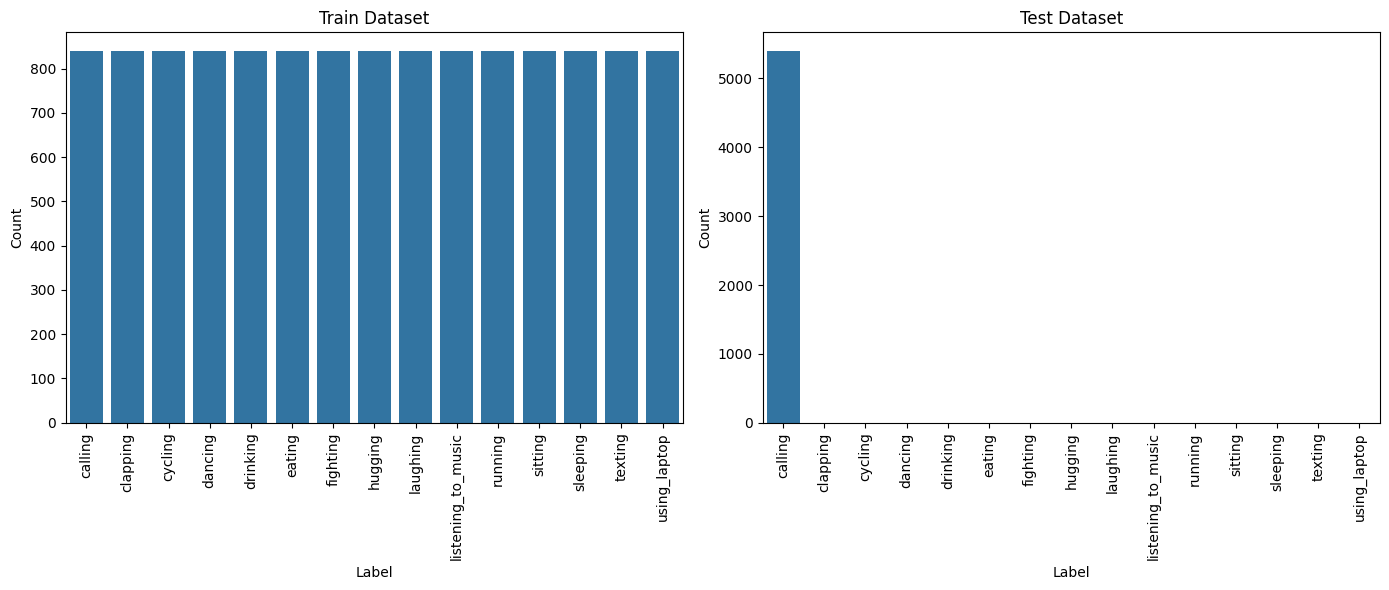

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6), dpi = DPI_SHOW)

sns.barplot(
    data=counter_train_df,
    x="Label",
    y="Count",
    ax=ax[0]
)
ax[0].set_title("Train Dataset")
ax[0].tick_params(axis="x", rotation=90)

sns.barplot(
    data=counter_test_df,
    x="Label",
    y="Count",
    ax=ax[1]
)
ax[1].set_title("Test Dataset")
ax[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/counter_train_test.png", dpi = DPI)
plt.show()

Los datos de entrenamiento sí están balanceados, mientras que los datos de test no lo están. Antes de tomar una decisión sobre que proceso aplicar para rebalancear y ajustar los datos a continuación se ilustra un set de 4 ejemplos de entrenamiento y 4 de test.

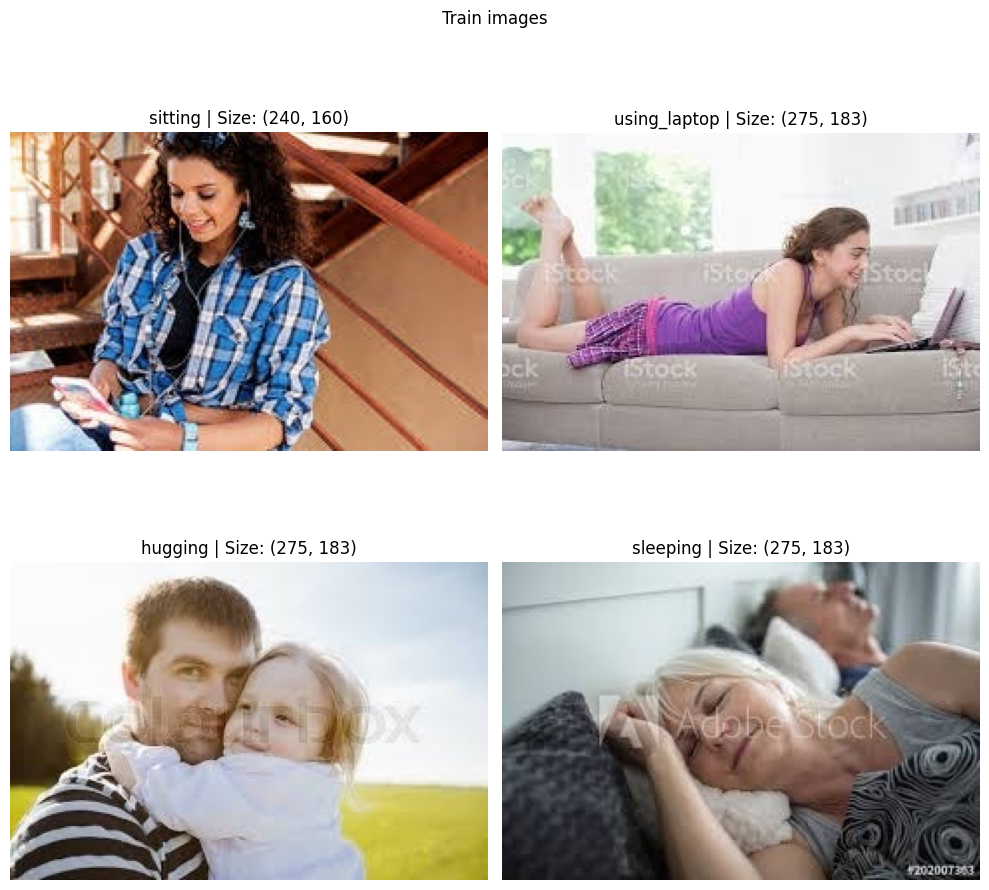

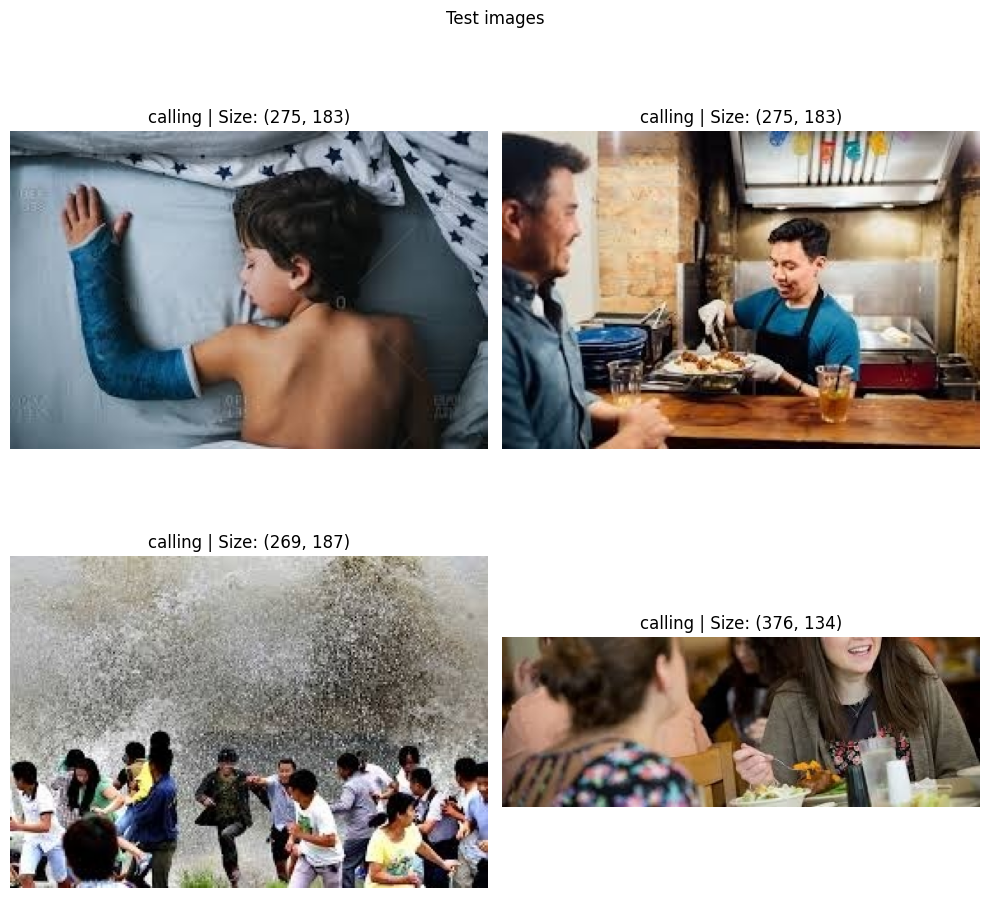

In [15]:
show_N_images(ds['train'], labels, 4, sup_title="Train images", save_dir=FIGURES_DIR, save_name="train_images.png")
show_N_images(ds['test'], labels, 4, sup_title="Test images", save_dir=FIGURES_DIR, save_name="test_images.png")

Se observa que el conjunto de datos de test presenta un fuerte desbalanceo entre clases y, adicionalmente, se detectan inconsistencias en el etiquetado. Dado que este conjunto no cumple las condiciones necesarias para una evaluación fiable del modelo, se decide no utilizarlo en la fase de entrenamiento ni validación.

No obstante, este conjunto no se elimina, sino que se aparta deliberadamente. La motivación es doble. Por un lado, evitar que datos potencialmente mal etiquetados introduzcan ruido durante el aprendizaje y perjudiquen la convergencia del modelo. Por otro, preservar estas muestras para un uso futuro en un escenario de aprendizaje semisupervisado. El aprendizaje semisupervisado puede facilitarse teniendo varios modelos entrenados sobre el mismo dataset, y realizar una votación (basado en sus probabilidades) entre ellos para obtener predicciones más robustas.

Una vez se disponga de un modelo entrenado de forma robusta a partir del conjunto de entrenamiento balanceado, este podrá emplearse como modelo auxiliar para re-etiquetar o corregir parcialmente las etiquetas del conjunto de test, combinando predicciones automáticas con validación manual. Este enfoque permitiría recuperar valor de datos inicialmente descartados, aumentando el volumen efectivo de muestras sin comprometer la calidad del entrenamiento inicial.

En consecuencia, el proceso de balanceo se realiza exclusivamente sobre el conjunto de entrenamiento, garantizando que las decisiones de muestreo no introduzcan sesgos en la evaluación y manteniendo una separación estricta entre datos utilizados para aprender y datos reservados para futuras estrategias de mejora del dataset.

In [16]:
ds = DatasetDict({
    'train': ds['train'],
    'noise': ds['test']
})

El siguiennte paso es analizar la distribución de ancho y alto de las imágenes.

In [17]:
ds['train'] = ds['train'].map(add_ds_image_size)
ds['noise'] = ds['noise'].map(add_ds_image_size)


Ahora se grafica en un scatterplot, con una nube de puntos los anchos y altos de cada imagen en función de su clase, ya que a lo mejor hay tendencias en función de estas

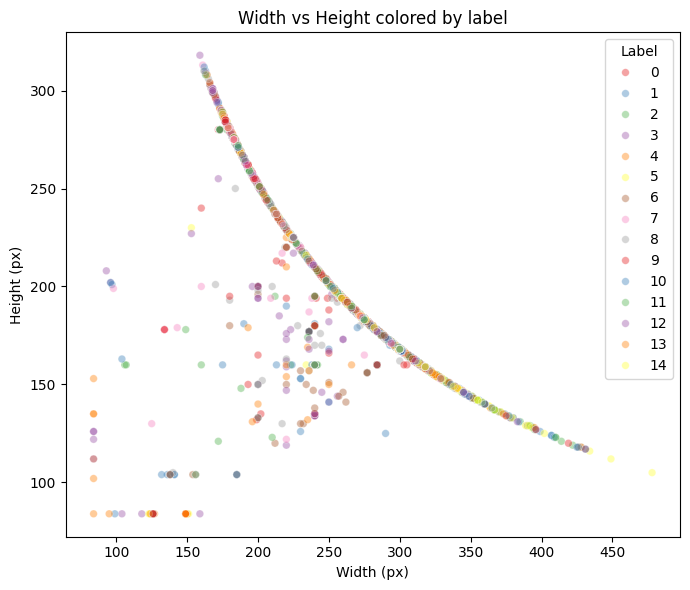

In [18]:
df_vis = pd.DataFrame({
    "width": ds["train"]["width"],
    "height": ds["train"]["height"],
    "label": ds["train"]["labels"]
})

plt.figure(figsize=(7, 6), dpi = DPI_SHOW)
sns.scatterplot(
    data=df_vis,
    x="width",
    y="height",
    hue="label",
    alpha=0.4,
    s=30,
    palette="Set1"
)

plt.title("Width vs Height colored by label")
plt.xlabel("Width (px)")
plt.ylabel("Height (px)")
plt.legend(title="Label")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/width_vs_height.png", dpi = DPI)
plt.show()

En el grafico ilustrado se observa que "no hay dos imágenes con el  mismo tamaño", y no hay ninguna tendencia tampoco en función de la clase, pero si, se observa una clara agrupación de nube de puntos, "el arco".

Hay que establecer una manera de filtrar esas imágenes, ya que cuando se entrene un modelo interesa que todas las imágenes tengan resoluciones similares, asi al realizar escalados no se pierde tanta información.

Se procede a estudiar dos posibles formas de filtrar los datos:
1. Utilizar [DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html) ya que con clustering y una buena configuración se puede eliminar los outliers.
2. Eliminando los outliers a partir de los rangos intercuartilicos:
    *  Eliminar los outleirs a partir de $width$ y $height$.
    *  Eliminar los outliers a partir de $resolution$. Donde $resolution$ es el valor de la resolución ($width \times height$) de la imagen.


## Filtrado de datos

### 1. DBSCAN

DBSCAN realiza agrupaciones basado en densidad, es decir, agrupa los puntos que están cerca entre sí, para ello hay que determinar el radio de vecindad (`eps`) y el número mínimo de puntos para formar un cluster (`min_samples`).

Uno de los pasos más importantes en DBSCAN es aplicar el escalado de los datos, en este caso los datos objetivo son la resolución de las imágenes.

In [19]:
from sklearn.preprocessing import StandardScaler
import numpy as np

X = np.column_stack([ds['train']['width'], ds['train']['height']])
X_scaled = StandardScaler().fit_transform(X)

Se ha probado para diferentes valores de `eps` y `min_samples`, finalmente se seleccionó la configuración de `eps=0.30` y `min_samples=20`.

In [20]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.30, min_samples=20)

clusters = dbscan.fit_predict(X_scaled)

DBSCAN marca con un -1 los valores que no pertenecen a ningún cluster.

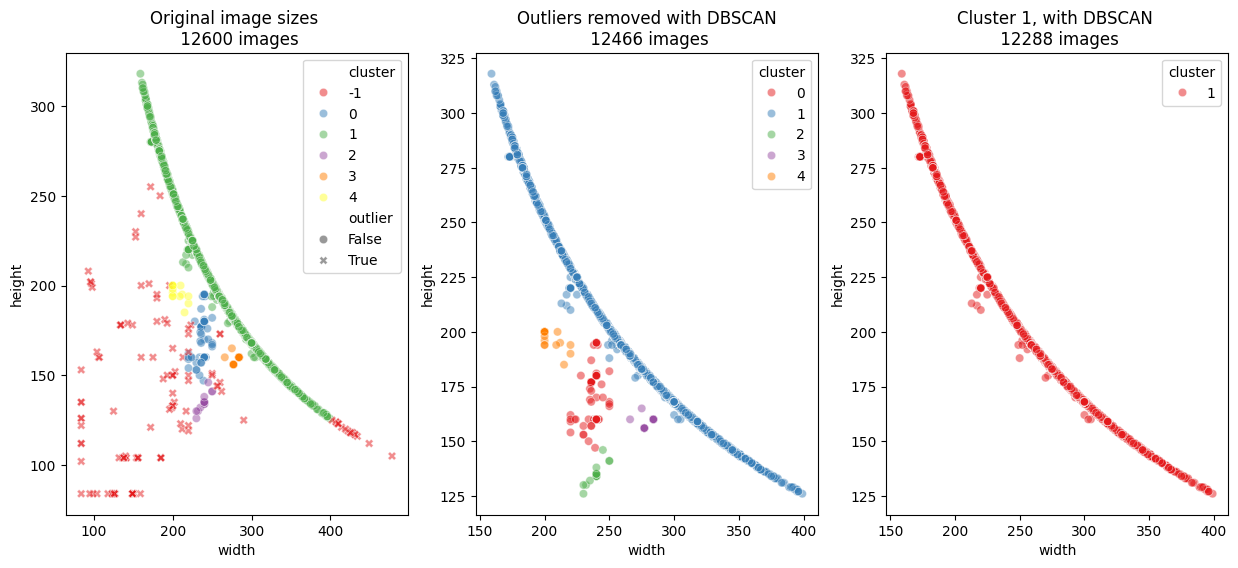

In [21]:
df_dbscan = df_vis.copy()
df_dbscan["cluster"] = clusters
df_dbscan["outlier"] = df_dbscan["cluster"] == -1

fig, axs = plt.subplots(1, 3, figsize=(15, 6), dpi = DPI_SHOW)

sns.scatterplot(
    data=df_dbscan,
    x="width",
    y="height",
    hue="cluster",
    style="outlier",
    palette="Set1",
    alpha=0.5,
    legend="brief",
    ax=axs[0]
)
axs[0].set_title(f"Original image sizes \n {len(df_dbscan)} images")

sns.scatterplot(
    data=df_dbscan[df_dbscan["cluster"] != -1],
    x="width",
    y="height",
    hue="cluster",
    palette="Set1",
    alpha=0.5,
    legend="brief",
    ax=axs[1]
)
axs[1].set_title(f"Outliers removed with DBSCAN\n {len(df_dbscan[df_dbscan['cluster'] != -1])} images")

sns.scatterplot(
    data=df_dbscan[(df_dbscan["cluster"] == 1)],
    x="width",
    y="height",
    hue="cluster",
    palette="Set1",
    alpha=0.5,
    legend="brief",
    ax=axs[2]
)
axs[2].set_title(f"Cluster 1, with DBSCAN \n {len(df_dbscan[(df_dbscan['cluster'] == 1)])} images")
plt.savefig(f"{FIGURES_DIR}/dbscan.png", dpi = DPI)
plt.show()

De esta manera conseguimos reducir muchos outliers y seleccionando los clusters adecuados obtenemos una buena segmentación y filtrado de imagenes con una resolución aceptable.

Si se escogiera este método, filtrando solo con el cluster 1 se reduciría el tamaño del dataset, pero también se mejora su calidad.

In [22]:
df_filtered = df_dbscan[(df_dbscan["cluster"] == 1)]
original_size = ds['train'].shape[0]
filtered_size = df_filtered.shape[0]
print(f"Se han eliminado {original_size-filtered_size} imágenes, de un total de {original_size}.")
print(f"Se ha reducido a un {filtered_size/original_size*100:.2f}% del dataset.")

Se han eliminado 312 imágenes, de un total de 12600.
Se ha reducido a un 97.52% del dataset.


### 2. Eliminación de outliers

In [23]:
def get_quartiles_outliers(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3-q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[column]>upper) | (df[column]<lower)][column]
    min_value = df[column].min()
    max_value = df[column].max()
    return q1, q3, iqr, lower, upper, outliers, min_value, max_value

**Limitar el `width` y `height` a un threshold determinado.**

Para establecer unos límites de threshold se va a emplear el estudio de los rangos intercuartílicos, ya que con ello se puede detectar la presencia de outliers.

In [24]:
q1_w, q3_w, iqr_w, lower_w, upper_w, outliers_w, _,_  = get_quartiles_outliers(df_vis, "width")
q1_h, q3_h, iqr_h, lower_h, upper_h, outliers_h, _,_  = get_quartiles_outliers(df_vis, "height")

df_threshold = df_vis.copy()

df_threshold["outlier"] = (
    (df_threshold["width"] < lower_w) |
    (df_threshold["width"] > upper_w) |
    (df_threshold["height"] < lower_h) |
    (df_threshold["height"] > upper_h)
)

In [25]:
print(f"WIDTH -> Upper limit: {upper_w} | Lower limit: {lower_w}")
print(f"HEIGHT -> Upper limit: {upper_h} | Lower limit: {lower_h}")

WIDTH -> Upper limit: 309.0 | Lower limit: 221.0
HEIGHT -> Upper limit: 213.5 | Lower limit: 161.5


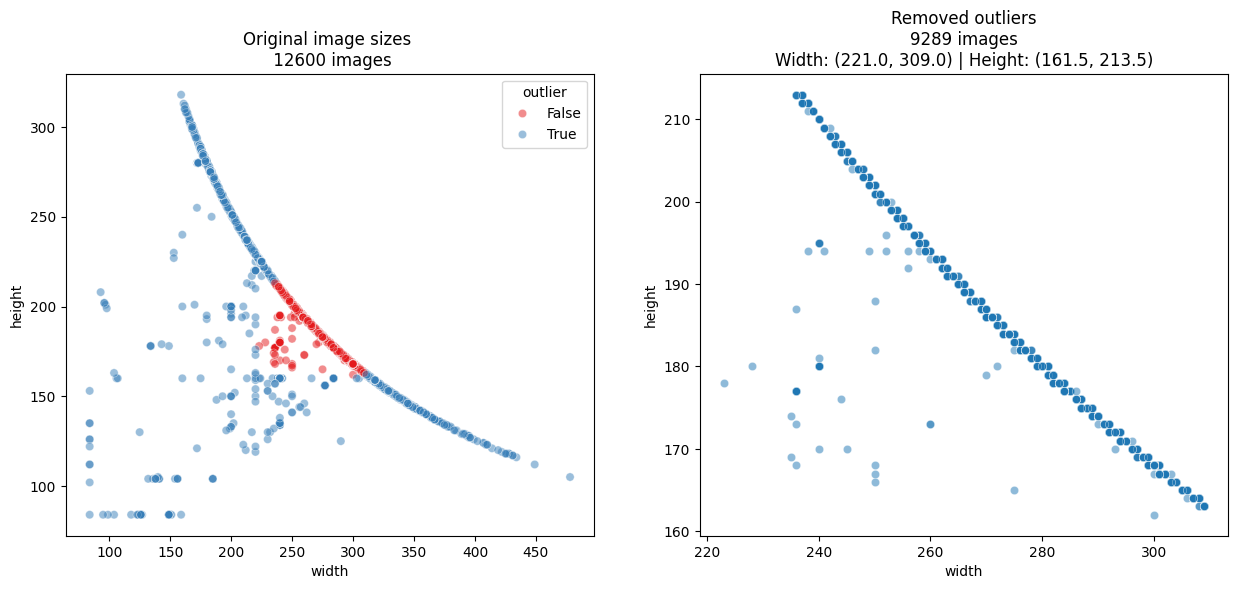

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6), dpi=DPI_SHOW)

sns.scatterplot(
    data=df_threshold,
    x="width",
    y="height",
    hue="outlier",
    palette="Set1",
    alpha=0.5,
    legend="brief",
    ax=axs[0]
)
axs[0].set_title(f"Original image sizes \n {df_threshold.shape[0]} images")

sns.scatterplot(
    data=df_threshold[df_threshold["outlier"] == False],
    x="width",
    y="height",
    alpha=0.5,
    legend="brief",
    ax=axs[1]
)

title = (
    "Removed outliers\n"
    f"{df_threshold[df_threshold['outlier'] == False].shape[0]} images\n"
    f"Width: ({lower_w}, {upper_w}) | Height: ({lower_h}, {upper_h})"
)
axs[1].set_title(title)
plt.savefig(f"{FIGURES_DIR}/width_height_threshold.png", dpi=DPI)
plt.show()

Si se filtrasen los datos eliminando los outliers que se han detectado estudiando los rangos intercuartílicos se obtendría la siguiente reducción de datos:

In [27]:
df_filtered = df_threshold[df_threshold['outlier']==False]
original_size = ds['train'].shape[0]
filtered_size = df_filtered.shape[0]
print(f"Se han eliminado {original_size-filtered_size} imágenes, de un total de {original_size}.")
print(f"Se ha reducido a un {filtered_size/original_size*100:.2f}% del dataset.")

Se han eliminado 3311 imágenes, de un total de 12600.
Se ha reducido a un 73.72% del dataset.


**Limitar el resolution a un threshold determinado**

In [28]:
df_vis["resolution"] = df_vis["width"] * df_vis["height"]
q1_r, q3_r, iqr_r, lower_r, upper_r, outliers_r, _, _ = get_quartiles_outliers(df_vis, 'resolution')
df_threshold = df_vis.copy()

df_threshold["outlier"] = (
    (df_threshold["resolution"] < lower_r) |
    (df_threshold["resolution"] > upper_r)
)

In [29]:
print(f"RESOLUTION -> Upper limit: {upper_r} | Lower limit: {lower_r}")

RESOLUTION -> Upper limit: 50572.5 | Lower limit: 50176.5


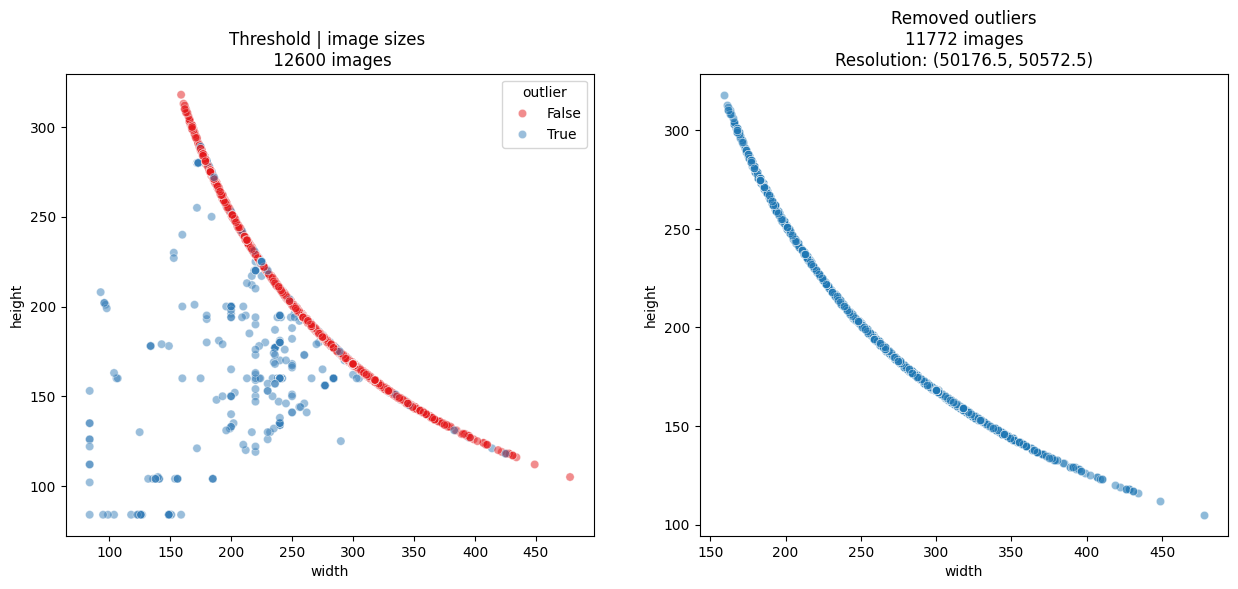

In [30]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6), dpi = DPI_SHOW)

sns.scatterplot(
    data=df_threshold,
    x="width",
    y="height",
    hue="outlier",
    palette="Set1",
    alpha=0.5,
    legend="brief",
    ax=axs[0]
)
axs[0].set_title(f"Threshold | image sizes \n {len(df_threshold)} images")

sns.scatterplot(
    data=df_threshold[df_threshold["outlier"] == False],
    x="width",
    y="height",
    alpha=0.5,
    legend="brief",
    ax=axs[1]
)
title = (
    "Removed outliers\n"
    f"{df_threshold[df_threshold['outlier'] == False].shape[0]} images\n"
    f"Resolution: ({lower_r}, {upper_r})"
)
axs[1].set_title(title)

plt.savefig(f"{FIGURES_DIR}/resolution_threshold.png", dpi=DPI)
plt.show()

Se obtiene menos eliminaciones de datos que previamente filtrando con `height` y `width`.

A continuación se muestra la reducción obtenida con este proceso.

In [31]:
df_filtered = df_threshold[df_threshold['outlier']==False]
original_size = ds['train'].shape[0]
filtered_size = df_filtered.shape[0]
print(f"Se han eliminado {original_size-filtered_size} imágenes, de un total de {original_size}.")
print(f"Se ha reducido un {filtered_size/original_size*100:.2f}% del dataset.")

Se han eliminado 828 imágenes, de un total de 12600.
Se ha reducido un 93.43% del dataset.


**Combinando los dos thresholds**

El objetivo es eliminar solo los datos atípicos de manera intleigente, tratando de preservar la mayor cantidad de datos posibles.

Entonces se va a intentar quedar con los datos que no son outliers tanto al hacer lo del umbral de `height` y `width` y lo del umbral de `resolution`.

In [32]:
q1_w, q3_w, iqr_w, lower_w, upper_w, outliers_w, _,_  = get_quartiles_outliers(df_vis, "width")
q1_h, q3_h, iqr_h, lower_h, upper_h, outliers_h, _,_  = get_quartiles_outliers(df_vis, "height")

df_threshold = df_vis.copy()

df_threshold["outlier_hw"] = (
    (df_threshold["width"] < lower_w) |
    (df_threshold["width"] > upper_w) |
    (df_threshold["height"] < lower_h) |
    (df_threshold["height"] > upper_h)
)

df_vis["resolution"] = df_vis["width"] * df_vis["height"]
q1_r, q3_r, iqr_r, lower_r, upper_r, outliers_r, _, _ = get_quartiles_outliers(df_vis, 'resolution')

df_threshold["outlier_r"] = (
    (df_threshold["resolution"] < lower_r) |
    (df_threshold["resolution"] > upper_r)
)

In [33]:
def outlier_th(row: pd.Series):
    return (row["outlier_hw"]) & (row["outlier_r"])

df_threshold['outlier'] = df_threshold.apply(outlier_th, axis=1)


In [34]:
print(f"WIDTH -> Upper limit: {upper_w} | Lower limit: {lower_w}")
print(f"HEIGHT -> Upper limit: {upper_h} | Lower limit: {lower_h}")
print(f"RESOLUTION -> Upper limit: {upper_r} | Lower limit: {lower_r}")

WIDTH -> Upper limit: 309.0 | Lower limit: 221.0
HEIGHT -> Upper limit: 213.5 | Lower limit: 161.5
RESOLUTION -> Upper limit: 50572.5 | Lower limit: 50176.5


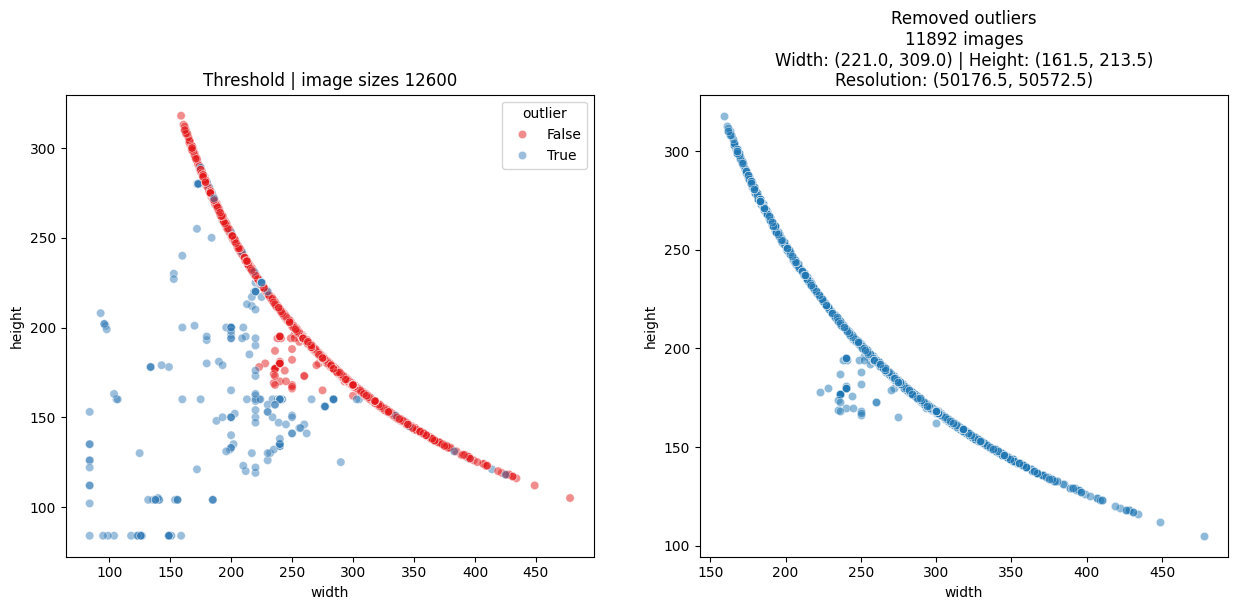

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6), dpi = DPI_SHOW)

sns.scatterplot(
    data=df_threshold,
    x="width",
    y="height",
    hue="outlier",
    palette="Set1",
    alpha=0.5,
    legend="brief",
    ax=axs[0]
)
axs[0].set_title(f"Threshold | image sizes {len(df_threshold)}")

sns.scatterplot(
    data=df_threshold[df_threshold["outlier"] == False],
    x="width",
    y="height",
    alpha=0.5,
    legend="brief",
    ax=axs[1]
)

title = (
    "Removed outliers\n"
    f"{df_threshold[df_threshold['outlier'] == False].shape[0]} images\n"
    f"Width: ({lower_w}, {upper_w}) | Height: ({lower_h}, {upper_h})\n"
    f"Resolution: ({lower_r}, {upper_r})"
)
axs[1].set_title(title)
plt.savefig(f'{FIGURES_DIR}/width_height_resolution_threshold_1.png', dpi=DPI)
plt.show()

Ahora no se tiene tantos outliers, y se obtiene más datos, y de calidad.

A continuación se muestra la reducción final del dataset

In [36]:
df_filtered = df_threshold[df_threshold['outlier']==False]
original_size = ds['train'].shape[0]
filtered_size = df_filtered.shape[0]
print(f"Se han eliminado {original_size-filtered_size} imágenes, de un total de {original_size}.")
print(f"Se ha reducido un {filtered_size/original_size*100:.2f}% del dataset.")

Se han eliminado 708 imágenes, de un total de 12600.
Se ha reducido un 94.38% del dataset.


Se puede ser algo más laxo y reducir a 5\% los limites inferiores y aumentar un 5\% los límites superiores, ya que hay algunas muestras que se están excluyendo y perderlas no merece la pena con la cantidad de datos que se tienen.

In [37]:
q1_w, q3_w, iqr_w, lower_w, upper_w, outliers_w, _,_  = get_quartiles_outliers(df_vis, "width")
q1_h, q3_h, iqr_h, lower_h, upper_h, outliers_h, _,_  = get_quartiles_outliers(df_vis, "height")

df_threshold = df_vis.copy()

lower_w = lower_w * 0.95
upper_w = upper_w * 1.15
lower_h = lower_h * 0.95
upper_h = upper_h * 1.15
df_threshold["outlier_hw"] = (
    (df_threshold["width"] < lower_w) |
    (df_threshold["width"] > upper_w) |
    (df_threshold["height"] < lower_h) |
    (df_threshold["height"] > upper_h)
)

df_vis["resolution"] = df_vis["width"] * df_vis["height"]
q1_r, q3_r, iqr_r, lower_r, upper_r, outliers_r, _, _ = get_quartiles_outliers(df_vis, 'resolution')

lower_r = lower_r * 0.95
upper_r = upper_r * 1.15
df_threshold["outlier_r"] = (
    (df_threshold["resolution"] < lower_r) |
    (df_threshold["resolution"] > upper_r)
)

In [38]:
def outlier_th(row: pd.Series):
    return (row["outlier_hw"]) & (row["outlier_r"])

df_threshold['outlier'] = df_threshold.apply(outlier_th, axis=1)

In [39]:
print(f"WIDTH -> Upper limit: {upper_w:.2f} | Lower limit: {lower_w:.2f}")
print(f"HEIGHT -> Upper limit: {upper_h:.2f} | Lower limit: {lower_h:.2f}")
print(f"RESOLUTION -> Upper limit: {upper_r:.2f} | Lower limit: {lower_r:.2f}")

WIDTH -> Upper limit: 355.35 | Lower limit: 209.95
HEIGHT -> Upper limit: 245.52 | Lower limit: 153.42
RESOLUTION -> Upper limit: 58158.37 | Lower limit: 47667.67


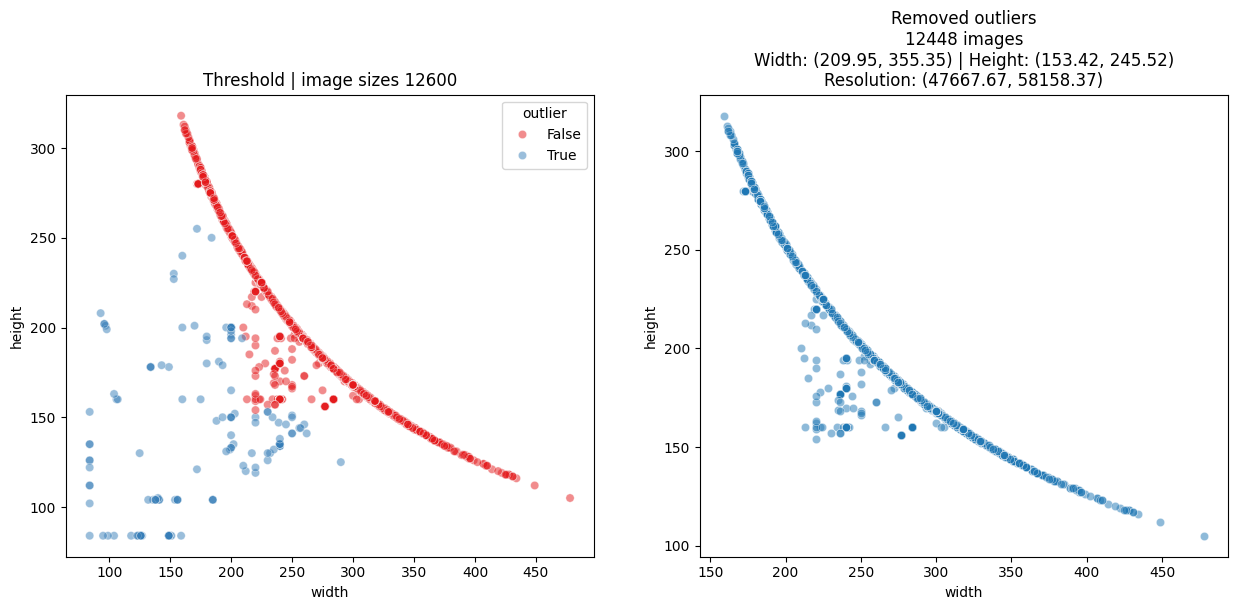

In [40]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6), dpi = DPI_SHOW)

sns.scatterplot(
    data=df_threshold,
    x="width",
    y="height",
    hue="outlier",
    palette="Set1",
    alpha=0.5,
    legend="brief",
    ax=axs[0]
)
axs[0].set_title(f"Threshold | image sizes {len(df_threshold)}")

sns.scatterplot(
    data=df_threshold[df_threshold["outlier"] == False],
    x="width",
    y="height",
    alpha=0.5,
    legend="brief",
    ax=axs[1]
)

title = (
    "Removed outliers\n"
    f"{df_threshold[df_threshold['outlier'] == False].shape[0]} images\n"
    f"Width: ({lower_w:.2f}, {upper_w:.2f}) | Height: ({lower_h:.2f}, {upper_h:.2f})\n"
    f"Resolution: ({lower_r:.2f}, {upper_r:.2f})"
)
axs[1].set_title(title)
plt.savefig(f'{FIGURES_DIR}/width_height_resolution_threshold_2.png', dpi=DPI)
plt.show()

In [41]:
df_filtered = df_threshold[df_threshold['outlier']==False]
original_size = ds['train'].shape[0]
filtered_size = df_filtered.shape[0]
print(f"Se han eliminado {original_size-filtered_size} imágenes, de un total de {original_size}.")
print(f"Se ha reducido un {filtered_size/original_size*100:.2f}% del dataset.")

Se han eliminado 152 imágenes, de un total de 12600.
Se ha reducido un 98.79% del dataset.


Es el resultado que más se ajusta a lo esperado, no se pierde tanta información y elimina los datos con una resolución baja

### 3. Selección final


Tras comparar las alternativas para homogeneizar el dataset (variabilidad de tamaños y resoluciones), se selecciona el método que mejor equilibra calidad de las muestras, interpretabilidad y preservación de datos.


* DBSCAN: permite una segmentación razonable por densidad, pero el resultado depende de la búsqueda de hiperparámetros (eps, min_samples). Además, obliga a decidir a posteriori qué clusters se conservan, lo que reduce la reproducibilidad del pipeline y hace más difícil justificar el criterio de filtrado.

* Eliminación de outliers con umbrales IQR (get_quartiles_outliers):
    - Solo por width y height: el filtrado resulta demasiado agresivo porque marca como atípica una gran cantidad de imágenes válidas (se eliminan muchas muestras), lo que no es deseable para el entrenamiento.
    - Solo por resolution = width · height: el resultado es más favorable, ya que elimina principalmente resoluciones extremas y conserva la estructura principal del conjunto.
    - Criterio combinado (recomendado): eliminar una imagen únicamente si es outlier a la vez en dimensiones y en resolución. Este enfoque es el más equilibrado porque reduce falsos positivos (no elimina tantas muestras) y mantiene un criterio determinista y fácilmente interpretable.

Criterio final adoptado (interpretable y reproducible):

**Se elimina la muestra si: outlier_hw AND outlier_r**

* `outlier_hw`: fuera de los rangos IQR en width o height
* `outlier_r`: fuera del rango IQR en resolution

# Separación de los datos

Hay que dividir el dataset en `train`, `valid` y `test`, preferiblemente la división debe ser aleatoria y balanceada.
* `train`: son los datos empleados para el entrenamiento.
* `valid`: son los datos que se emplean para la evaluación del modelo durante el proceso de entrenamiento.
* `test`: son los datos que nunca ha visto el modelo durante el proceso de entrenamiento y son empleados para una evaluación post entrenamiento.

Posteriormente, se hace el filtrado de los datos, no se hace previamente ya que si no las comparaciones que se hagan a posteriori no serían justas, ya que los datos no serían los mismos. Tal y como se propone así el punto de partida de train y test serían los mismos, aunque esto puede desbalancear un poco el dataset.


In [42]:
splits = ds["train"].train_test_split(
    test_size=0.15,
    seed=42,
    shuffle=True,
    stratify_by_column="labels"
)

ds["train"] = splits["train"]
ds["test"] = splits["test"]

percentage_val = ds["test"].shape[0] / ds["train"].shape[0]
splits = ds["train"].train_test_split(
    test_size=percentage_val,
    seed=42,
    shuffle=True,
    stratify_by_column="labels"
)
ds["train"] = splits["train"]
ds["val"] = splits["test"]

In [43]:
def filtered_data(example):
    w = example["width"]
    h = example["height"]
    r = w * h

    outlier_wh = (w < lower_w or w > upper_w) or (h < lower_h or h > upper_h)
    outlier_r = r < lower_r or r > upper_r

    return not (outlier_wh and outlier_r)

ds_filtered = ds.filter(filtered_data)

In [44]:
print(f"Datos conjunto de entrenamiento:")
print(f"Original: {ds['train'].shape[0]} | Filtrado: {ds_filtered['train'].shape[0]}")

print(f"Datos conjunto de valid:")
print(f"Original: {ds['val'].shape[0]} | Filtrado: {ds_filtered['val'].shape[0]}")

print(f"Datos conjunto de test:")
print(f"Original: {ds['test'].shape[0]} | Filtrado: {ds_filtered['test'].shape[0]}")

print(f"Datos conjunto de noise:")
print(f"Original: {ds['noise'].shape[0]} | Filtrado: {ds_filtered['noise'].shape[0]}")

Datos conjunto de entrenamiento:
Original: 8819 | Filtrado: 8711
Datos conjunto de valid:
Original: 1891 | Filtrado: 1865
Datos conjunto de test:
Original: 1890 | Filtrado: 1872
Datos conjunto de noise:
Original: 5400 | Filtrado: 5344


Observamos de nuevo el nuevo rebalanceo de los datos

In [45]:
counter_train_df = analysis_dataset(ds['train'], labels)
counter_val_df = analysis_dataset(ds['val'], labels)
counter_test_df = analysis_dataset(ds['test'], labels)
counter_train_df_filtered = analysis_dataset(ds_filtered['train'], labels)
counter_val_df_filtered = analysis_dataset(ds_filtered['val'], labels)
counter_test_df_filtered = analysis_dataset(ds_filtered['test'], labels)

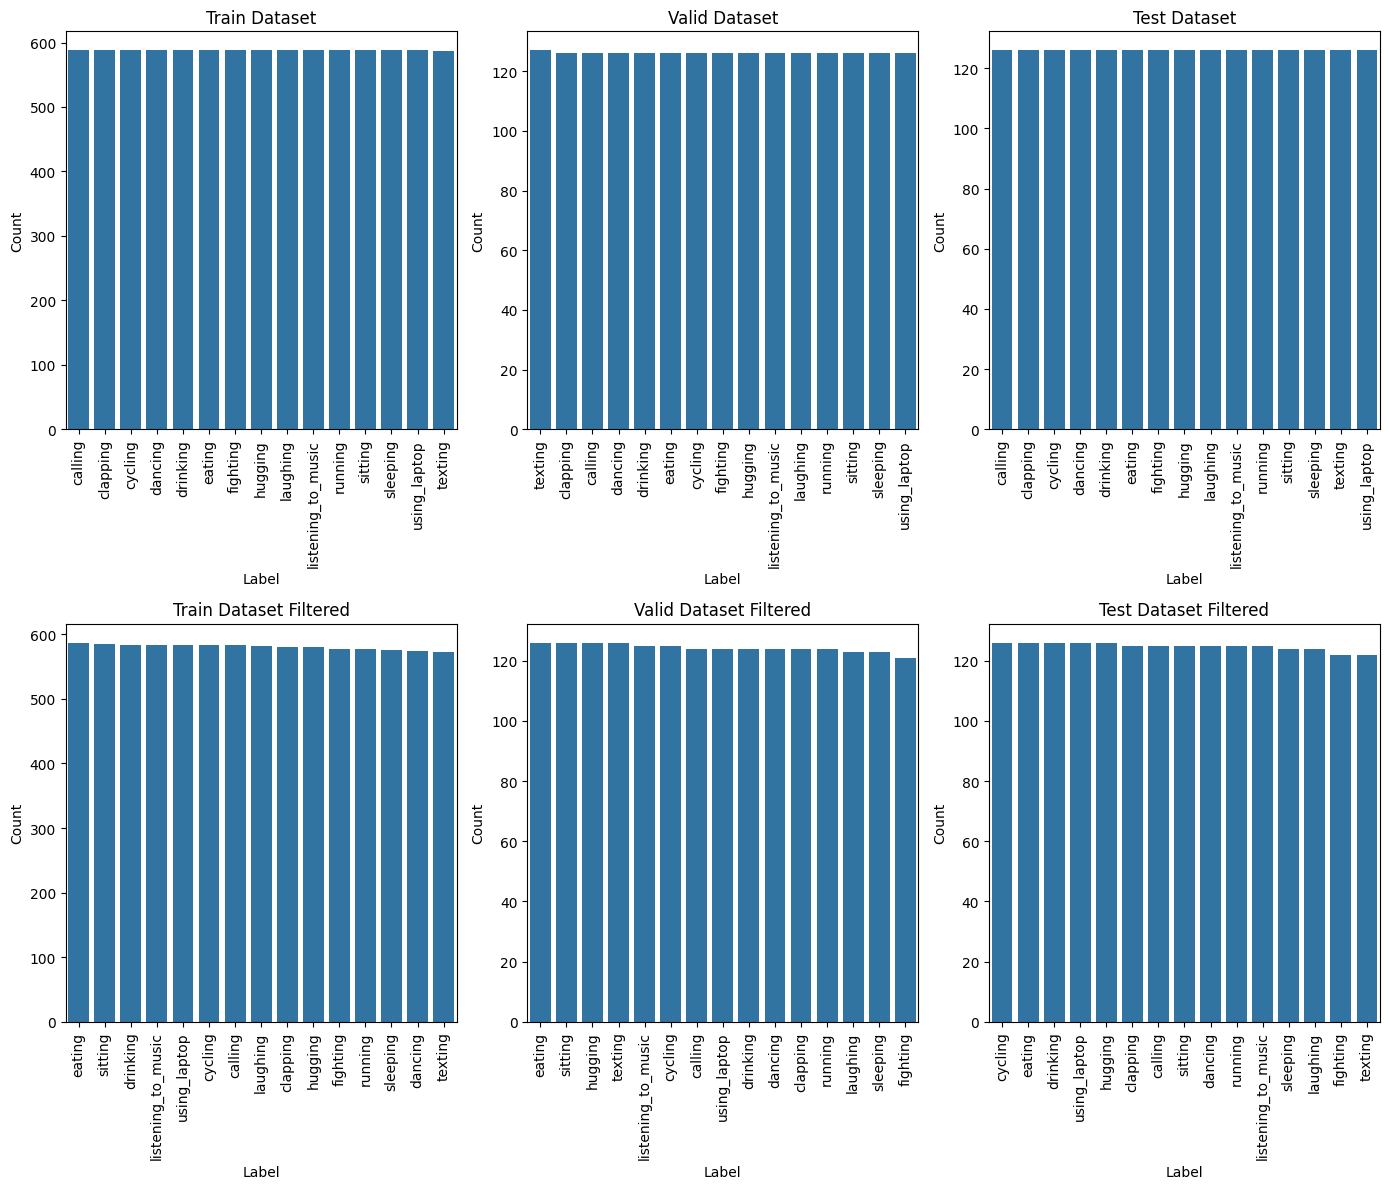

In [46]:
fig, ax = plt.subplots(2, 3, figsize=(14, 12), dpi = DPI_SHOW)

sns.barplot(
    data=counter_train_df,
    x="Label",
    y="Count",
    ax=ax[0,0]
)
ax[0,0].set_title("Train Dataset")
ax[0,0].tick_params(axis="x", rotation=90)

sns.barplot(
    data=counter_val_df,
    x="Label",
    y="Count",
    ax=ax[0,1]
)
ax[0,1].set_title("Valid Dataset")
ax[0,1].tick_params(axis="x", rotation=90)

sns.barplot(
    data=counter_test_df,
    x="Label",
    y="Count",
    ax=ax[0,2]
)
ax[0,2].set_title("Test Dataset")
ax[0,2].tick_params(axis="x", rotation=90)

sns.barplot(
    data=counter_train_df_filtered,
    x="Label",
    y="Count",
    ax=ax[1,0]
)
ax[1,0].set_title("Train Dataset Filtered")
ax[1,0].tick_params(axis="x", rotation=90)

sns.barplot(
    data=counter_val_df_filtered,
    x="Label",
    y="Count",
    ax=ax[1,1]
)
ax[1,1].set_title("Valid Dataset Filtered")
ax[1,1].tick_params(axis="x", rotation=90)

sns.barplot(
    data=counter_test_df_filtered,
    x="Label",
    y="Count",
    ax=ax[1,2]
)
ax[1,2].set_title("Test Dataset Filtered")
ax[1,2].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/counter_train_test_balanced.png', dpi=DPI)
plt.show()


Ahora ya tenemos una visión completa de los datos y su distribución.

Durante el proceso de entrenamiento de los modelos se probará los dos conjutnos de datos. EL primero, un dataset completamente balanceado, pero con imágenes de cualquier tamaño. El segundo, un dataset ligeramente desbalanceado, pero con imágenes de una resolución similar.

# Entrenamiento de los modelos

Para el entrenamiento de clasificación que hay que resolver, hay que establecer el modelo a emplear, el optimizador, la función de pérdida y el tipo de entrenamiento.

* Modelos: los dos posibles modelos serán [EFficientnet B5](https://www.tensorflow.org/api_docs/python/tf/keras/applications/EfficientNetB5),[EfficientNet V2 B0](https://keras.io/api/applications/efficientnet_v2/)  o [VGG16](https://keras.io/api/applications/vgg16/).
* Optimizador: se puede utilizar tanto `SGD` como `Adam`, estos optimizadores ofrecen buenas convergencias, `SGD` tiene una convergencia más estable, mientras que `Adam` es capaz de llegar a la solución más rápido ya que reduce el `learning_rate`.
* Función de pérdida: se puede utilizar tanto `categorical_crossentropy` como `sparse_categorical_crossentropy`, la primera es utilizada cuando el target es una matriz de one-hot encoding, mientras que la segunda es utilizada cuando el target es un vector de enteros, es decir, la que se emplea en este caso.
* Entrenamiento: se puede hacer un trasnfer learning, que consiste en utilizar un modelo previamente entrenado y entrenarlo exclusivamente solo las capas superiores o fine-tuning, que consiste en entrenar el modelo completo.

    

El entrenamiento se realizará sobre 3 escenarios:
* Escenario 1: datos reducidos sobre el dataset ya filtrado. Este dataset reducido simplifica a solo 5 clases en vez de 11, con el objetivo de tener un problema más simple y facilitar la resolución del mismo al modelo.
* Escenario 2: datos filtrados sobre el dataset original.
* Escenario 3: datos reducidos pero no filtrados.

## Funciones auxiliares

Función para graficar la función de pérdidas y accuracy a lo largo del proceso de entrenamiento del modelo. Como el entrenamiento puede dividirse en Trasnfer Learning y Finetuning hay una función específica para poder graficar las dos simultáneamente.

In [47]:
def plot_loss_accuracy(history, save_dir = None, save_name = None):
    """
    Plot the loss and accuracy of the model.

    Args:
        history: History of the model.
        save_dir: Directory to save the plot.
        save_name: Name of the saved plot.
    """

    fig, axs = plt.subplots(1, 3, figsize=(18, 6), dpi=DPI_SHOW)

    axs[0].plot(range(0, len(history.history['accuracy'])), history.history['accuracy'], label='Train')
    axs[0].plot(range(0, len(history.history['val_accuracy'])), history.history['val_accuracy'], label='Valid')
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_title('Accuracy')
    axs[0].legend()

    axs[1].plot(range(0, len(history.history['loss'])), history.history['loss'], label='Train')
    axs[1].plot(range(0, len(history.history['val_loss'])), history.history['val_loss'], label='Valid')
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('Loss')
    axs[1].set_title('Loss')
    axs[1].legend()

    axs[2].plot(range(0, len(history.history['learning_rate'])), history.history['learning_rate'], label = 'lr')
    axs[2].set_xlabel('Epochs')
    axs[2].set_ylabel('Learning Rate')
    axs[2].set_yscale('log')
    axs[2].set_title('Learning Rate')
    axs[2].legend()


    plt.show()
    if save_dir and save_name:
        plt.savefig(os.path.join(save_dir, save_name), dpi=DPI)

def plot_loss_accuracy_tl_ft(history_tf, history_ft, n_trainable_tf, n_trainable_ft, n_params, save_dir = None, save_name = None):
    """
    Plot the loss, accuracy, learning rate and trainable params of the model.

    Args:
        history: History of the model.
        save_dir: Directory to save the plot.
        save_name: Name of the saved plot.
    """

    fig, axs = plt.subplots(2, 2, figsize=(14, 10), dpi=DPI_SHOW)

    # ---------- Accuracy ----------
    ax = axs[0, 0]
    ax.plot(history_tf.history['accuracy'], label='Train (TL)')
    ax.plot(history_tf.history['val_accuracy'], label='Valid (TL)')

    offset = len(history_tf.history['accuracy'])
    ax.plot(
        range(offset, offset + len(history_ft.history['accuracy'])),
        history_ft.history['accuracy'],
        label='Train (FT)'
    )
    ax.plot(
        range(offset, offset + len(history_ft.history['val_accuracy'])),
        history_ft.history['val_accuracy'],
        label='Valid (FT)'
    )

    ax.set_title('Accuracy')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ---------- Loss ----------
    ax = axs[0, 1]
    ax.plot(history_tf.history['loss'], label='Train (TL)')
    ax.plot(history_tf.history['val_loss'], label='Valid (TL)')

    ax.plot(
        range(offset, offset + len(history_ft.history['loss'])),
        history_ft.history['loss'],
        label='Train (FT)'
    )
    ax.plot(
        range(offset, offset + len(history_ft.history['val_loss'])),
        history_ft.history['val_loss'],
        label='Valid (FT)'
    )

    ax.set_title('Loss')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # ---------- Learning Rate ----------
    ax = axs[1, 0]
    ax.plot(history_tf.history['learning_rate'], label='LR (TL)')
    ax.plot(
        range(offset, offset + len(history_ft.history['learning_rate'])),
        history_ft.history['learning_rate'],
        label='LR (FT)'
    )

    ax.set_yscale('log')
    ax.set_title('Learning Rate')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('LR')
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)

    # ---------- Trainable parameters ----------
    ax = axs[1, 1]
    total_epochs = offset + len(history_ft.history['loss'])

    ax.axhline(
        y=n_params,
        linestyle='--',
        color='red',
        linewidth=1,
        label=f'Total params {n_params}'
    )

    ax.plot(range(0, offset), [n_trainable_tf] * offset,
            label=f'Trainable (TL): {n_trainable_tf}')
    ax.plot(range(offset, total_epochs), [n_trainable_ft] * len(history_ft.history['loss']),
            label=f'Trainable (FT): {n_trainable_ft}')

    ax.set_yscale('log')
    ax.set_title('Trainable Parameters')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Parameters')
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)

    plt.tight_layout()

    if save_dir and save_name:
        plt.savefig(os.path.join(save_dir, save_name), dpi=DPI)

    plt.show()

La siguiente función sirve para evaluar a los modelos una vez han sido entrenados y extraer las métricas de accuracy, precision, recall, f1 y la matriz de confusión

In [48]:
def eval_predicts(y_true, y_pred, y_probs=None, k_values=[3], save_dir=None, save_name=None):
    """
    Evaluate the predictions including Top-K accuracy.

    Args:
        y_true: True labels (etiquetas reales).
        y_pred: Predicted labels (etiquetas predichas con argmax).
        y_probs: Raw probabilities from model.predict (necesario para Top-K).
        k: The 'k' for Top-k accuracy (e.g., 3 or 5).
        save_dir: Directory to save the plot.
        save_name: Name of the saved plot.
    """

    # 1. Métricas estándar (usan y_pred labels)
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro')
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')

    top_k_acc = None
    if y_probs is not None:
        # Nota: labels debe contener todas las clases posibles si y_true no las tiene todas
        # top_k_accuracy_score infiere las clases de y_probs.shape[1]

        # Verificación de seguridad: K no puede ser mayor que el número de clases
        n_classes = y_probs.shape[1]
        
        top_k_acc_dict = {}
        for k in k_values:
            if k < n_classes:
                top_k_acc = top_k_accuracy_score(y_true, y_probs, k=k)
            else:
                top_k_acc = 1.0
            top_k_acc_dict[k] = top_k_acc

    # 3. Matriz de Confusión
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 7), dpi = DPI_SHOW)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    if save_dir and save_name:
        plt.savefig(os.path.join(save_dir, save_name), dpi=DPI)
    plt.show()

    results = {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1)
    }

    for k in k_values:
        top_k_acc = top_k_acc_dict.get(k, None)
        if top_k_acc is not None:
            results[f"top_{k}_accuracy"] = top_k_acc

    return results

La siguiente función ayuda a la construcción del modelo en base a una configuración inicial en la que se podrá especificar el modelo (VGG16 o EfficientNet) y Batch Size.

Luego hay otra función que permite especificar las características del entrenamiento especificando de si se trata de trasnfer learning y/o fine tuning, el número de epochs y el learning rate en cada caso.

In [49]:

def load_model(name_model, input_shape):
    """
    Load a pre-trained model based on the configuration.

    Args:
        name_model: Name of the model to load.
        input_shape: Input shape of the model.

    Returns:
        model: Pre-trained model.
    """

    if name_model == 'vgg16':
        model = vgg16.VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    elif name_model == 'vgg19':
        model = vgg19.VGG19(weights='imagenet', include_top=False, input_shape=input_shape)
    elif name_model == 'efficientnetb0':
        model = efficientnet.EfficientNetB0(weights='imagenet', include_top=False, input_shape=input_shape)
    elif name_model == 'efficientnetb3':
        model = efficientnet.EfficientNetB3(weights='imagenet', include_top=False, input_shape=input_shape)
    elif name_model == 'efficientnetV2b0':
        model = efficientnet_v2.EfficientNetV2B0(weights='imagenet', include_top=False, input_shape=input_shape)
    else:
        raise ValueError("Invalid model name'")

    return model


Otro valor importante es devolver el numero de parámetros entrenables de un modelo.

In [50]:
def num_params(model):
    total_params = model.count_params()
    return total_params
def num_non_trainable_params(model):
    return np.sum([np.prod(v.shape) for v in model.non_trainable_variables])
def num_trainable_params(model):
    return np.sum([np.prod(v.shape) for v in model.trainable_variables])

Las funciones que se encuentran a continuación procesa los datos de HuggingFace y transforma esto en un dataset que pueda ser utilizado por el modelo. Además sufren un preprocesado para que los datos sean aptos para el entrenamiento, junto a un data augmentation, para aumentar el volumen de datos.

In [51]:
def hf_to_tf(ds, column, label_column):
    """
    Convert a Hugging Face dataset to a TensorFlow dataset.

    Args:
        ds: Hugging Face dataset.
        column: Column to use as features.
        label_column: Column to use as labels.

    Returns:
        tf_dataset: TensorFlow dataset.
    """
    tf_ds_train = ds["train"].to_tf_dataset(
        columns=column,
        label_cols=label_column,
        shuffle=True,
        batch_size=None)
    tf_ds_val = ds["val"].to_tf_dataset(
        columns=column,
        label_cols=label_column,
        shuffle=False,
        batch_size=None)

    tf_ds_test = ds["test"].to_tf_dataset(
        columns=column,
        label_cols=label_column,
        shuffle=False,
        batch_size=None)

    return tf_ds_train, tf_ds_val, tf_ds_test

In [52]:
IMG_SIZE = 224
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
])


def get_preprocess_fn(name_model):
    name_model = name_model.lower()

    if name_model == "vgg16":
        return vgg16.preprocess_input
    if name_model == "vgg19":
        return vgg19.preprocess_input
    if name_model in ("efficientnetb0", "efficientnetb3"):
        return efficientnet.preprocess_input
    if name_model in ("efficientnetv2b0", "efficientnetv2-b0", "efficientnetv2b0".lower(), "efficientnetv2b0"):
        return efficientnet_v2.preprocess_input

    raise ValueError(f"Unknown model for preprocessing: {name_model}")

def preprocess_hf_to_tf(ds, batch_size, name_model, column='image', label_column='labels'):
    """
    Transform the dataset from Hugging Face to TensorFlow format and process it.

    Args:
        ds: Dataset from Hugging Face.
        config: Configuration for the dataset.

    Returns:
        ds: Processed dataset in TensorFlow format.
    """
    preprocess_fn = get_preprocess_fn(name_model)

    def preprocess_train(image, label):
        image = tf.cast(image, tf.float32)
        image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
        image = data_augmentation(image)
        image = preprocess_fn(image)
        return image, label

    def preprocess_eval(image, label):
        image = tf.cast(image, tf.float32)
        image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
        image = preprocess_fn(image)
        return image, label

    train_tf_ds, val_tf_ds, test_tf_ds = hf_to_tf(ds, column=column, label_column=label_column)

    train_tf_ds = (
        train_tf_ds
        .map(preprocess_train)
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )
    val_tf_ds = (
        val_tf_ds
        .map(preprocess_eval)
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )
    test_tf_ds = (
        test_tf_ds
        .map(preprocess_eval)
        .batch(batch_size)
        .prefetch(tf.data.AUTOTUNE)
    )

    return train_tf_ds, val_tf_ds, test_tf_ds



I0000 00:00:1767775388.007185 2459714 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21306 MB memory:  -> device: 0, name: NVIDIA L40S, pci bus id: 0000:c4:00.0, compute capability: 8.9


Con la siguiente función se pretende simplificar el entrenamiento de los modelos. Para ello es obligatorio cargar el modelo como `base_model` y pasarlo como parámetro, junto al modelo `model` que se desea entrenar, que es el modelo con las capas personalizadas.

In [53]:
def train_tl(base_model,
            model,
            train_dataset,
            val_dataset,
            epochs = 10,
            learning_rate = 0.0001,
            loss = 'sparse_categorical_crossentropy',
            optimizer = 'adam',
            callbacks = None,
            ):
    """
    Train a model using transfer learning.

    Args:
        base_model: The base model to use for transfer learning.
        model: The model to train.
        train_dataset: The training dataset.
        val_dataset: The validation dataset.
        test_dataset: The test dataset.
        epochs: The number of epochs to train for.
        learning_rate: The learning rate to use.
        optimizer: The optimizer to use.
    """

    # Freeze the base model
    for layer in base_model.layers:
        layer.trainable = False

    # Compile the model
    if optimizer == 'Adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer == 'SGD':
        optimizer = SGD(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )
    
    n_params = num_params(model)
    n_non_trainable = num_non_trainable_params(model)
    n_trainable = num_trainable_params(model)
    print(f'Number of parameters: {n_params:.0f}')
    print(f'Number of non-trainable parameters: {n_non_trainable:.0f}')
    print(f'Number of trainable parameters: {n_trainable:.0f}')

    print("Training model...")

    # Train the model
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=epochs,
        callbacks=callbacks
    )


    return history, model, n_params, n_trainable

In [54]:
def train_ft(base_model,
            model,
            train_dataset,
            val_dataset,
            epochs = 10,
            learning_rate = 0.0001,
            loss = 'sparse_categorical_crossentropy',
            optimizer = 'adam',
            callbacks = None,
            ):
    """
    Train a model using transfer learning.

    Args:
        base_model: The base model to use for transfer learning.
        model: The model to train.
        train_dataset: The training dataset.
        val_dataset: The validation dataset.
        epochs: The number of epochs to train for.
        learning_rate: The learning rate to use.
        optimizer: The optimizer to use.
    """

    for layer in base_model.layers:
        if not isinstance(layer, BatchNormalization): # Mantener las capas de BatchNorm congeladas
            layer.trainable = True
        
    # Compile the model
    if optimizer == 'Adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer == 'SGD':
        optimizer = SGD(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss=loss,
        metrics=['accuracy']
    )

    n_params = num_params(model)
    n_non_trainable = num_non_trainable_params(model)
    n_trainable = num_trainable_params(model)
    print(f'Number of parameters: {n_params:.0f}')
    print(f'Number of non-trainable parameters: {n_non_trainable:.0f}')
    print(f'Number of trainable parameters: {n_trainable:.0f}')

    print("Training model...")

    # Train the model
    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=epochs,
        callbacks=callbacks
    )


    return history, model, n_params, n_trainable

## Escenario 1: Entrenamiento dataset reducido y filtrado

Filtramos por las cinco primeras etiquetas y luego se realizarán una serie de experimentos hasta encontrar una buena solución.

In [55]:
ds_reduced_filtered = ds_filtered.copy()

In [56]:
target_labels = [0,1,2,3,4]
ds_reduced_filtered["train"] = ds_reduced_filtered["train"].filter(lambda x: x["labels"] in target_labels)
ds_reduced_filtered["val"] = ds_reduced_filtered["val"].filter(lambda x: x["labels"] in target_labels)
ds_reduced_filtered["test"] = ds_reduced_filtered["test"].filter(lambda x: x["labels"] in target_labels)

In [67]:
red_labels  = [labels[i] for i in target_labels]
print("Labels used:", red_labels)

Labels used: ['calling', 'clapping', 'cycling', 'dancing', 'drinking']


In [57]:
print(f"Datos conjunto de entrenamiento:")
print(f"Original: {ds['train'].shape[0]} | Filtrado: {ds_filtered['train'].shape[0]} | Reducido - Filtrado: {ds_reduced_filtered['train'].shape[0]}")

print(f"Datos conjunto de valid:")
print(f"Original: {ds['val'].shape[0]} | Filtrado: {ds_filtered['val'].shape[0]} | Reducido - Filtrado: {ds_reduced_filtered['val'].shape[0]}")

print(f"Datos conjunto de test:")
print(f"Original: {ds['test'].shape[0]} | Filtrado: {ds_filtered['test'].shape[0]} | Reducido - Filtrado: {ds_reduced_filtered['test'].shape[0]}")

print(f"Datos conjunto de noise:")
print(f"Original: {ds['noise'].shape[0]} | Filtrado: {ds_filtered['noise'].shape[0]}")

Datos conjunto de entrenamiento:
Original: 8819 | Filtrado: 8711 | Reducido - Filtrado: 2907
Datos conjunto de valid:
Original: 1891 | Filtrado: 1865 | Reducido - Filtrado: 621
Datos conjunto de test:
Original: 1890 | Filtrado: 1872 | Reducido - Filtrado: 627
Datos conjunto de noise:
Original: 5400 | Filtrado: 5344


En la siguiente celda se definen 2 callbacks que serán utilizados durante el proceso de entrenamiento.
* Learning Rate Scheduler: reduce el learning rate cada 10 épocas al multiplicarse por un factor de 0.1.
* Early Stopping: paraliza el entrenamiento si lleva 3 épocas sin mejorar el resultadpo.

In [58]:
def step_decay(epoch, lr):
    if epoch > 0 and epoch % 5 == 0:
        return lr * 0.1
    return lr

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(
    step_decay,
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)
# checkpoint = tf.keras.callbacks.ModelCheckpoint(
#     f"models/best_vgg16.keras",
#     monitor="val_loss",
#     save_best_only=True,
#     verbose=1
# )

callbacks = [
    lr_scheduler,
    # early_stopping,
    # checkpoint
]

### Experimento 1

En este primer experimento se realizará un entrenamiento sobre el modelo de `VGG16`. El entrenamiento se realizará empleando el optimizador **Adam**, la función de perdidas **sparse categorical crossentropy** y con un Batch Size de 8. Por otro lado, se realizarán el entrenamiento en dos etapas:
* Primera etapa: Trasnfer Learning de 10 épocas y un learning rate de $10^{-4}$
* Segunda etapa: Trasnfer Finetuning de 10 épocas y un learning rate de $10^{-5}$

In [59]:
NAME_MODEL = 'vgg16'
IMG_SIZE = 224
BATCH_SIZE = 8
OPTIMIZER = 'Adam'
LOSS = 'sparse_categorical_crossentropy'
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = len(target_labels)
LEARNING_RATE_TL = 1e-4
EPOCHS_TL = 10

Se transforma el dataset de HuggingFace en un tensor (preprocesado) para que sea interpretable por el modelo

In [60]:
tf_ds_train,  tf_ds_valid, tf_ds_test = preprocess_hf_to_tf(
    ds_reduced_filtered,
    BATCH_SIZE, NAME_MODEL,
    column = 'image',
    label_column='labels')

El siguiente paso es definir el cargar el modelo.

In [61]:
base_model = load_model(
    name_model = NAME_MODEL,
    input_shape = (IMG_SIZE, IMG_SIZE, 3)
)

Para definir la arquitectura final se puede aplicar `GlobalAveragePooling2D()` o `Flatten()` a la salida de las capas convolucoines de VGG16. Se decidió emplear `GlobalAveragePooling()` ya que hará que se entrenen muchos menos parámetros y este sea más rápido.

In [62]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu',kernel_regularizer=l2(5e-5))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

output = Dense(NUM_CLASSES, activation='softmax')(x)
model = keras.Model(inputs=base_model.input, outputs=output)

In [63]:
history_tl, model, n_params_tl, n_trainable_tl = train_tl(
    base_model,
    model,
    tf_ds_train,
    tf_ds_valid,
    epochs=EPOCHS_TL,
    learning_rate = LEARNING_RATE_TL,
    loss=LOSS,
    optimizer=OPTIMIZER,
    callbacks=callbacks
)

Number of parameters: 14981957
Number of non-trainable parameters: 14715714
Number of trainable parameters: 266245
Training model...

Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 1/10


2026-01-07 09:43:10.043849: I external/local_xla/xla/service/service.cc:163] XLA service 0x7df41c020a80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-01-07 09:43:10.043875: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA L40S, Compute Capability 8.9
2026-01-07 09:43:10.086756: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-01-07 09:43:10.344032: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701


  9/364 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.2330 - loss: 2.0977

I0000 00:00:1767775393.121363 2463391 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


364/364 ━━━━━━━━━━━━━━━━━━━━ 24s 56ms/step - accuracy: 0.5187 - loss: 1.3935 - val_accuracy: 0.7279 - val_loss: 0.7501 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 2/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.6484 - loss: 0.9855 - val_accuracy: 0.7536 - val_loss: 0.6590 - learning_rate: 1.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 3/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 18s 48ms/step - accuracy: 0.7159 - loss: 0.8364 - val_accuracy: 0.7842 - val_loss: 0.5960 - learning_rate: 1.0000e-04

Epoch 4: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 4/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 16s 44ms/step - accuracy: 0.7221 - loss: 0.7779 - val_accuracy: 0.8164 - val_loss: 0.5464 - learning_rate: 1.0000e-04

Epoch 5: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 5/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - acc

Visualización de la función de pérdidas

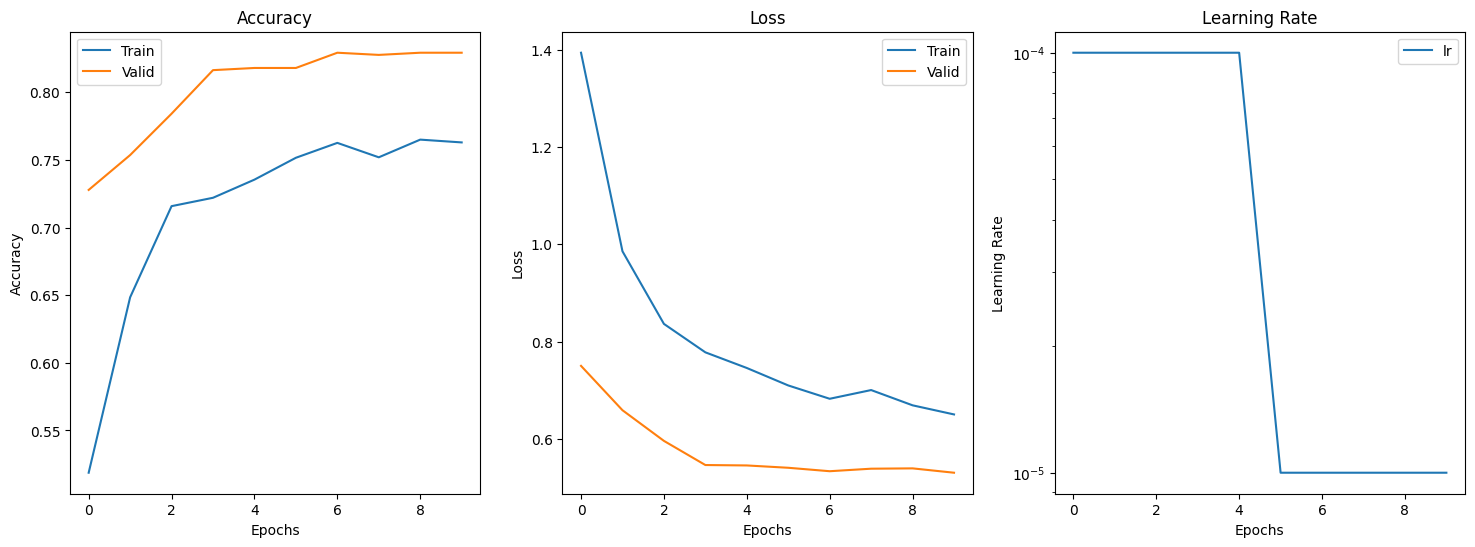

<Figure size 640x480 with 0 Axes>

In [64]:
plot_loss_accuracy(history_tl,
                   save_dir = FIGURES_DIR,
                   save_name = f'acc_loss_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_filt.png')

Evaluamos el modelo sobre los datos de test.


SUMMARY history
Final train accuracy: 0.76298588514328
Final train loss: 0.6503487229347229
Final test accuracy: 0.8293075561523438
Final test loss: 0.5306054949760437
======Test======
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step


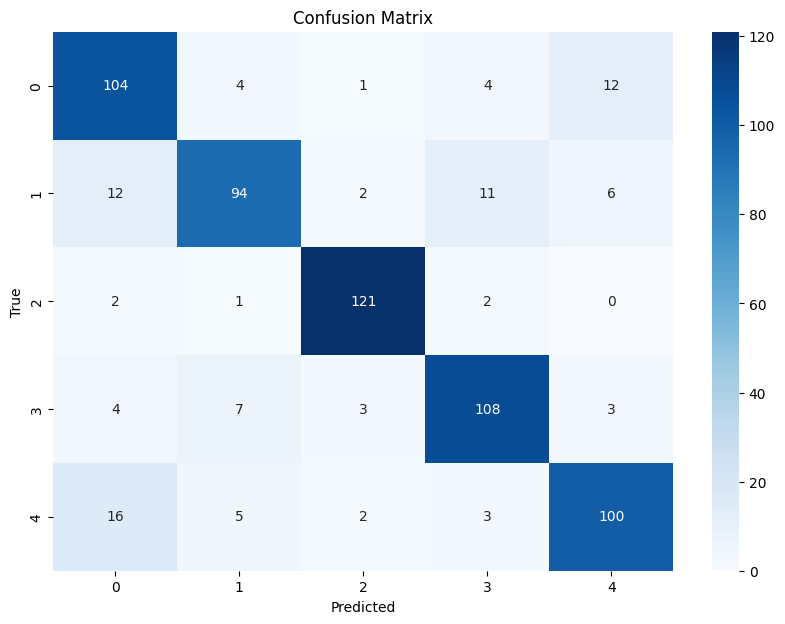

{
  "accuracy": 0.8405103668261563,
  "precision": 0.841730162473682,
  "recall": 0.8403936507936509,
  "f1": 0.8399951683902473,
  "top_3_accuracy": 0.9808612440191388
}


In [65]:
print("SUMMARY history")
print(f'Final train accuracy: {history_tl.history["accuracy"][-1]}')
print(f'Final train loss: {history_tl.history["loss"][-1]}')
print(f'Final valid accuracy: {history_tl.history["val_accuracy"][-1]}')
print(f'Final valid loss: {history_tl.history["val_loss"][-1]}')


print("======Test======")
y_true = ds_reduced_filtered['test']['labels']
y_pred = model.predict(tf_ds_test)
results_tl = eval_predicts(y_true, np.argmax(y_pred, axis=1), y_pred, k_values=[3],
        save_dir=FIGURES_DIR,
        save_name=f'cm_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_filt_test.png')
print(json.dumps(results_tl, indent=2))

In [66]:
LEARNING_RATE_FT = 1e-5
EPOCHS_FT = 10

In [67]:
history_ft, model, n_params_ft, n_trainable_ft = train_ft(
    base_model,
    model,
    tf_ds_train,
    tf_ds_valid,
    epochs=EPOCHS_FT,
    learning_rate = LEARNING_RATE_FT,
    loss=LOSS,
    optimizer=OPTIMIZER,
    callbacks=callbacks
)

Number of parameters: 14981957
Number of non-trainable parameters: 1026
Number of trainable parameters: 14980933
Training model...

Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 1/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 42s 90ms/step - accuracy: 0.6749 - loss: 0.9065 - val_accuracy: 0.7246 - val_loss: 0.7622 - learning_rate: 1.0000e-05

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 2/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 26s 71ms/step - accuracy: 0.6763 - loss: 0.8807 - val_accuracy: 0.6618 - val_loss: 1.1356 - learning_rate: 1.0000e-05

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 3/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 27s 74ms/step - accuracy: 0.7190 - loss: 0.8286 - val_accuracy: 0.7424 - val_loss: 0.7489 - learning_rate: 1.0000e-05

Epoch 4: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 4/10
364/364 ━━━━━━━━━━━━━━━━━━━━ 27s 73ms/step - accuracy: 0.7052 - 

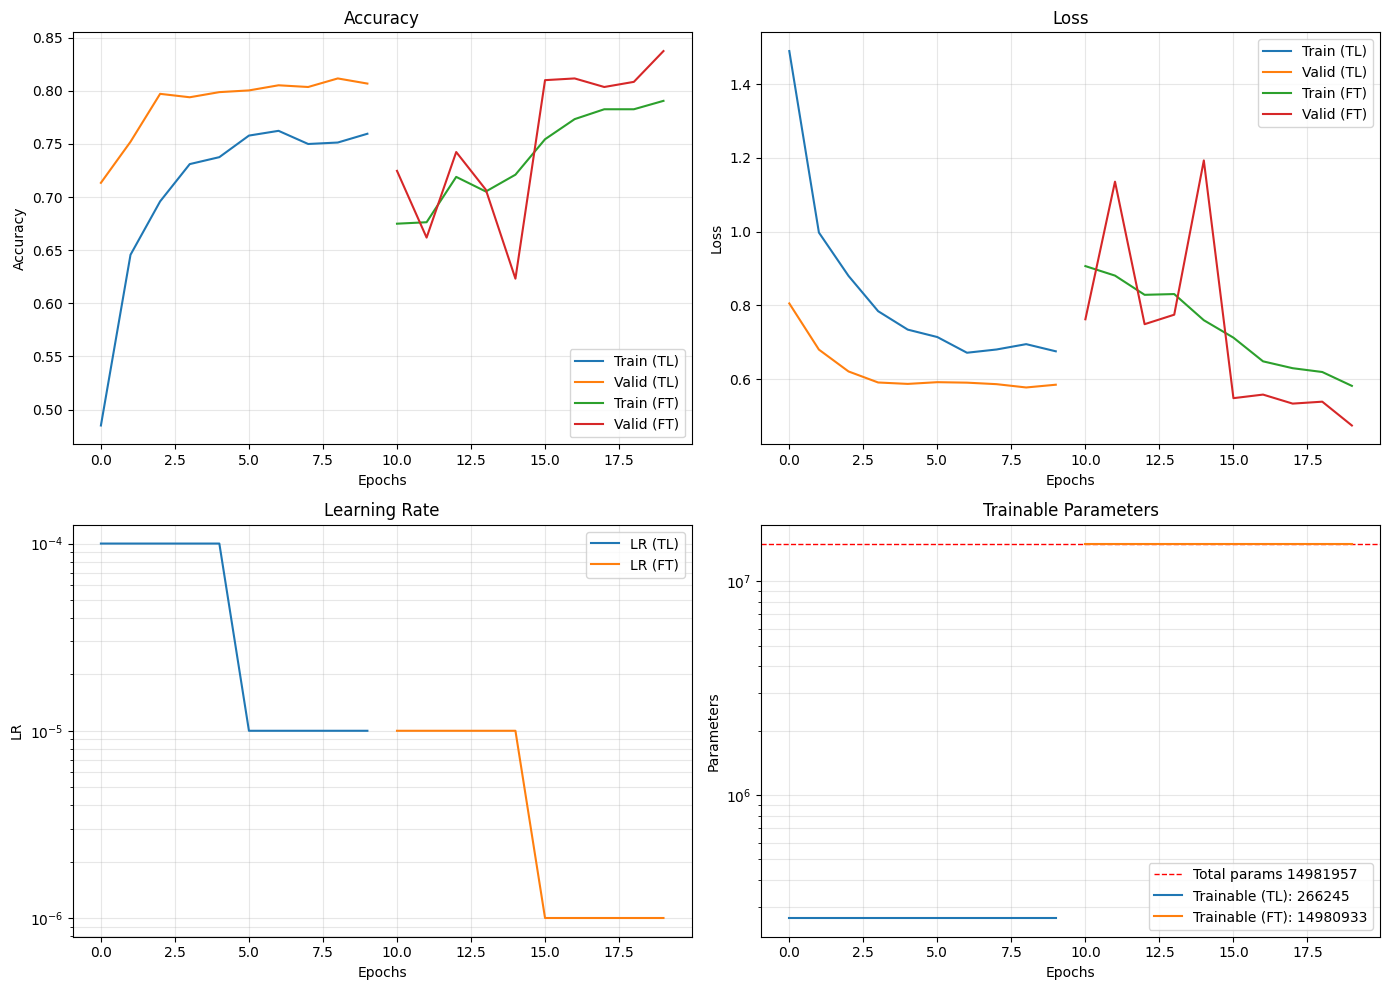

In [68]:
plot_loss_accuracy_tl_ft(history_tl,history_ft, n_trainable_tl, n_trainable_ft, n_params_tl,
                   save_dir = FIGURES_DIR,
                   save_name = f'acc_loss_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_filt.png')

SUMMARY history
Final train accuracy: 0.7905056476593018
Final train loss: 0.5815871953964233
Final test accuracy: 0.8373590707778931
Final test loss: 0.47407200932502747
======Test======
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step


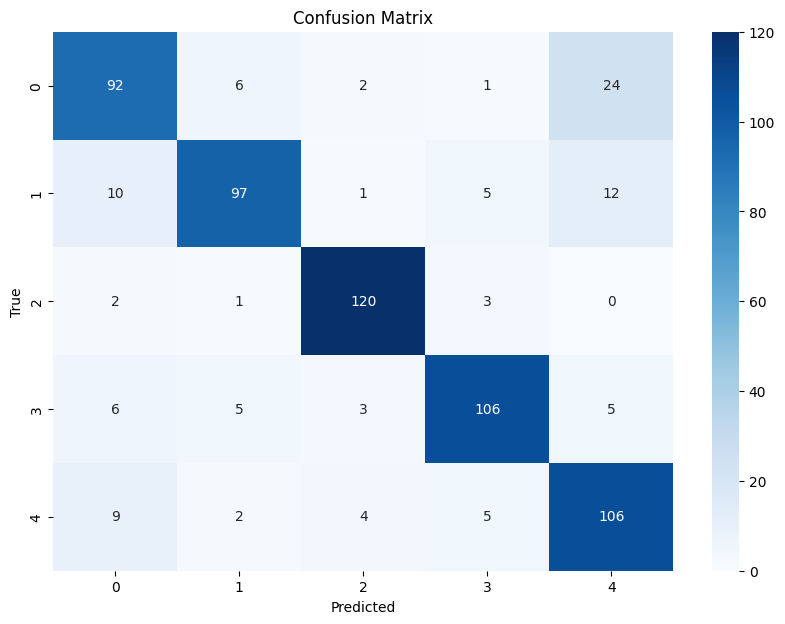

{
  "accuracy": 0.8309409888357256,
  "precision": 0.8348963618711517,
  "recall": 0.8307301587301585,
  "f1": 0.8310990315933158,
  "top_3_accuracy": 0.9952153110047847
}


In [ ]:
print("SUMMARY history")
print(f'Final train accuracy: {history_ft.history["accuracy"][-1]}')
print(f'Final train loss: {history_ft.history["loss"][-1]}')
print(f'Final valid accuracy: {history_ft.history["val_accuracy"][-1]}')
print(f'Final valid loss: {history_ft.history["val_loss"][-1]}')


print("======Test======")
y_true = ds_reduced_filtered['test']['labels']
y_pred = model.predict(tf_ds_test)
results_ft = eval_predicts(y_true, np.argmax(y_pred, axis=1), y_pred, k_values=[3],
        save_dir=FIGURES_DIR,
        save_name=f'cm_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_filt_test.png')
print(json.dumps(results_ft, indent=2))

Para la configuracion actual se observa una buena progresión del modelo, con un poco de underfitting en las curvas de la función de perdidas y precisión, y presenta unas métricas sobre los datos de test. Se observa una empeora al realizar la segunda etapa de entrenamiento, debido a empezar a modificar todos los pesos.

### Experimento 2

En este nuevo experimento se replica la configuración del entrenamiento anterior modificando el optimizador y seleccionando el optimizador **SGD**, se conoce que este optimizador converge más lentamente por tanto se decide aumentar a 20 épocas tanto para el trasnfer learning como para el finetuning.

In [70]:
NAME_MODEL = 'vgg16'
IMG_SIZE = 224
BATCH_SIZE = 8
OPTIMIZER = 'SGD'
LOSS = 'sparse_categorical_crossentropy'
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = len(target_labels)
LEARNING_RATE_TL = 1e-4
EPOCHS_TL = 20

In [71]:
tf_ds_train,  tf_ds_valid, tf_ds_test = preprocess_hf_to_tf(
    ds_reduced_filtered,
    BATCH_SIZE, NAME_MODEL,
    column = 'image',
    label_column='labels')

In [72]:
base_model = load_model(
    name_model = NAME_MODEL,
    input_shape = (IMG_SIZE, IMG_SIZE, 3)
)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu',kernel_regularizer=l2(5e-5))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)
model = keras.Model(inputs=base_model.input, outputs=output)

In [73]:
history_tl, model, n_params_tl, n_trainable_tl = train_tl(
    base_model,
    model,
    tf_ds_train,
    tf_ds_valid,
    epochs=EPOCHS_TL,
    learning_rate = LEARNING_RATE_TL,
    loss=LOSS,
    optimizer=OPTIMIZER,
    callbacks=callbacks
)

Number of parameters: 14981957
Number of non-trainable parameters: 14715714
Number of trainable parameters: 266245
Training model...

Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 1/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 21s 52ms/step - accuracy: 0.2635 - loss: 2.2299 - val_accuracy: 0.3671 - val_loss: 1.7256 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 2/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.3564 - loss: 1.8566 - val_accuracy: 0.4654 - val_loss: 1.4228 - learning_rate: 1.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 3/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 17s 45ms/step - accuracy: 0.4207 - loss: 1.6207 - val_accuracy: 0.5282 - val_loss: 1.2454 - learning_rate: 1.0000e-04

Epoch 4: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 4/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 13s 35ms/step - accuracy: 0.4709 

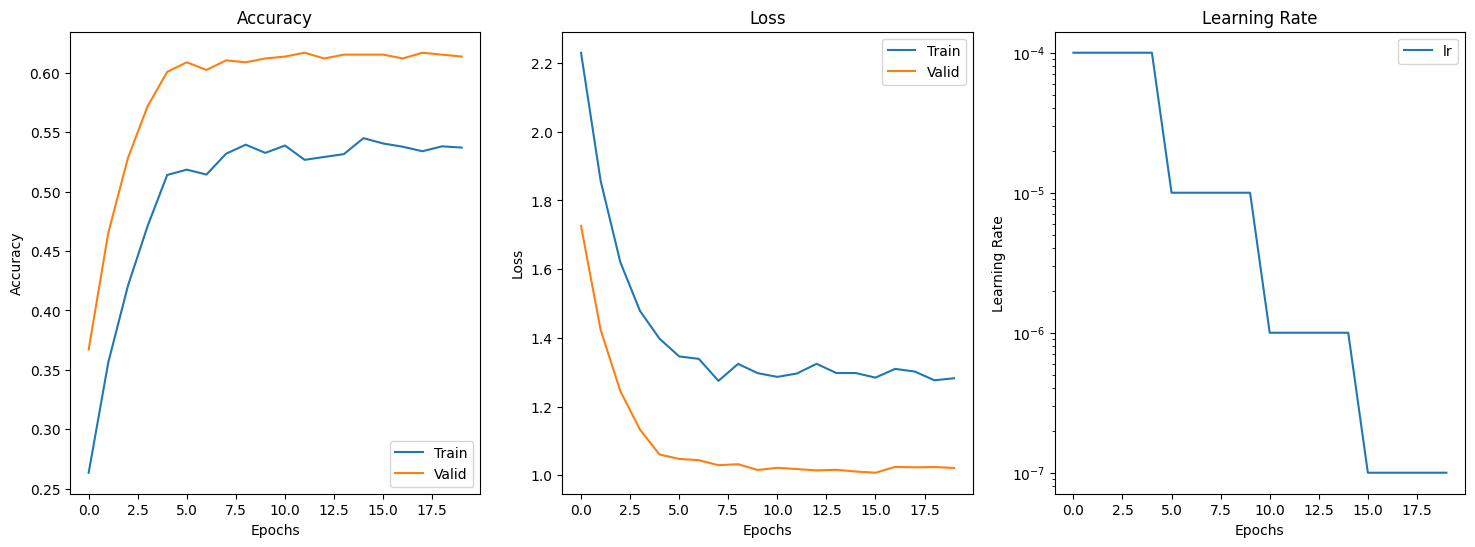

<Figure size 640x480 with 0 Axes>

In [74]:
plot_loss_accuracy(history_tl,
                   save_dir = FIGURES_DIR,
                   save_name = f'acc_loss_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_filt.png')

SUMMARY history
Final train accuracy: 0.5369796752929688
Final train loss: 1.2823759317398071
Final test accuracy: 0.6135265827178955
Final test loss: 1.0213176012039185
======Test======
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step


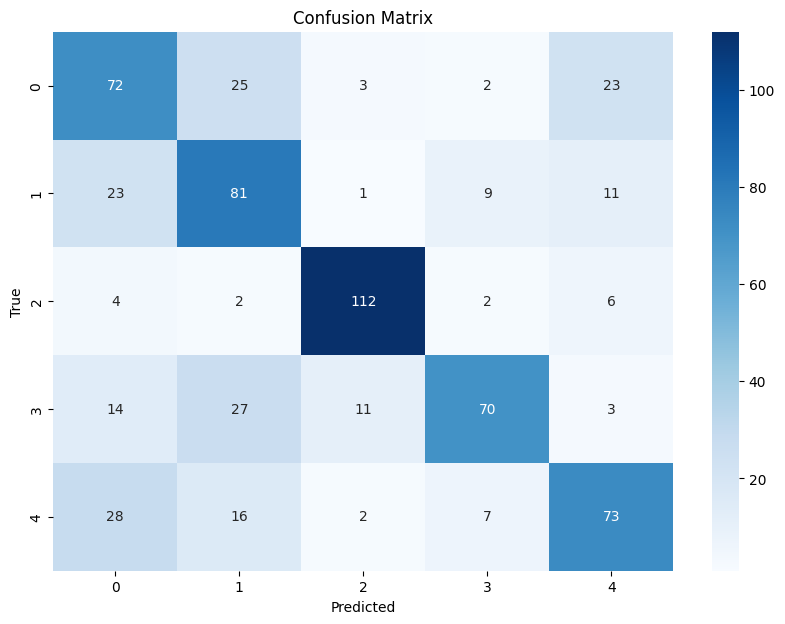

{
  "accuracy": 0.6507177033492823,
  "precision": 0.6644734631601745,
  "recall": 0.6504507936507936,
  "f1": 0.6522419707136875,
  "top_3_accuracy": 0.9266347687400319
}


In [ ]:
print("SUMMARY history")
print(f'Final train accuracy: {history_tl.history["accuracy"][-1]}')
print(f'Final train loss: {history_tl.history["loss"][-1]}')
print(f'Final valid accuracy: {history_tl.history["val_accuracy"][-1]}')
print(f'Final valid loss: {history_tl.history["val_loss"][-1]}')


print("======Test======")
y_true = ds_reduced_filtered['test']['labels']
y_pred = model.predict(tf_ds_test)
results_tl = eval_predicts(y_true, np.argmax(y_pred, axis=1), y_pred, k_values=[3],
        save_dir=FIGURES_DIR,
        save_name=f'cm_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_filt_test.png')
print(json.dumps(results_tl, indent=2))

Se procede a continuar con un breve ***finetuning***

In [76]:
LEARNING_RATE_FT = 1e-5
EPOCHS_FT = 20

In [77]:
history_ft, model, n_params_ft, n_trainable_ft = train_ft(
    base_model,
    model,
    tf_ds_train,
    tf_ds_valid,
    epochs=EPOCHS_FT,
    learning_rate = LEARNING_RATE_FT,
    loss=LOSS,
    optimizer=OPTIMIZER,
    callbacks=callbacks
)

Number of parameters: 14981957
Number of non-trainable parameters: 1026
Number of trainable parameters: 14980933
Training model...

Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 1/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 31s 75ms/step - accuracy: 0.5359 - loss: 1.2796 - val_accuracy: 0.6393 - val_loss: 0.9774 - learning_rate: 1.0000e-05

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 2/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 26s 70ms/step - accuracy: 0.5655 - loss: 1.2305 - val_accuracy: 0.6554 - val_loss: 0.9234 - learning_rate: 1.0000e-05

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 3/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - accuracy: 0.5765 - loss: 1.1655 - val_accuracy: 0.6538 - val_loss: 0.8866 - learning_rate: 1.0000e-05

Epoch 4: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 4/20
364/364 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - accuracy: 0.5937 - 

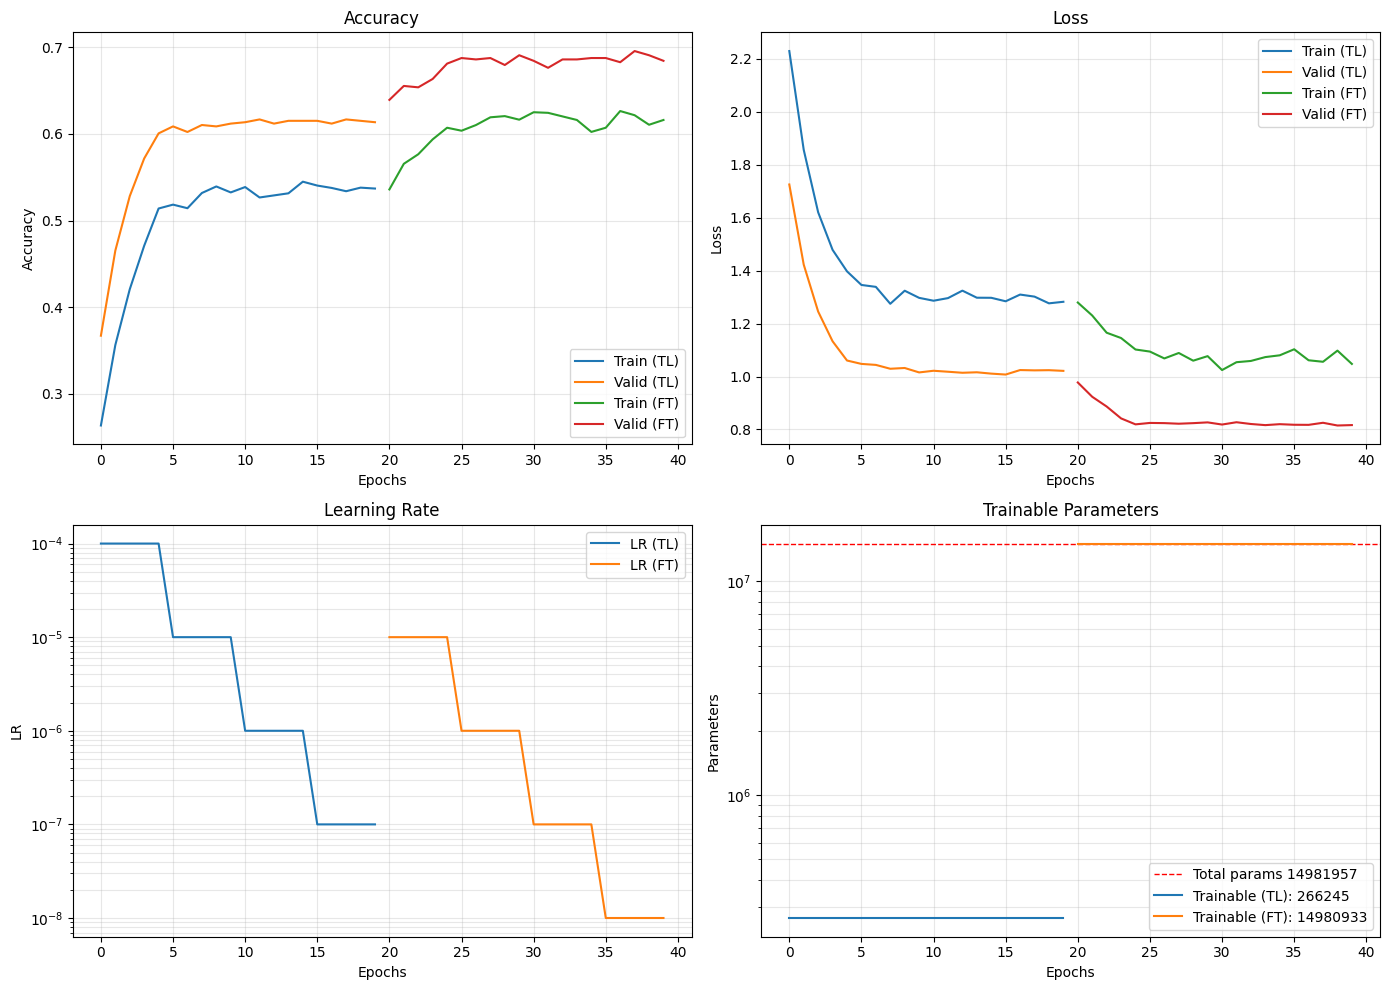

In [78]:
plot_loss_accuracy_tl_ft(history_tl,history_ft, n_trainable_tl, n_trainable_ft, n_params_tl,
                   save_dir = FIGURES_DIR,
                   save_name = f'acc_loss_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_filt.png')

SUMMARY history
Final train accuracy: 0.6160990595817566
Final train loss: 1.0474867820739746
Final test accuracy: 0.684380054473877
Final test loss: 0.8164075016975403
======Test======
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step


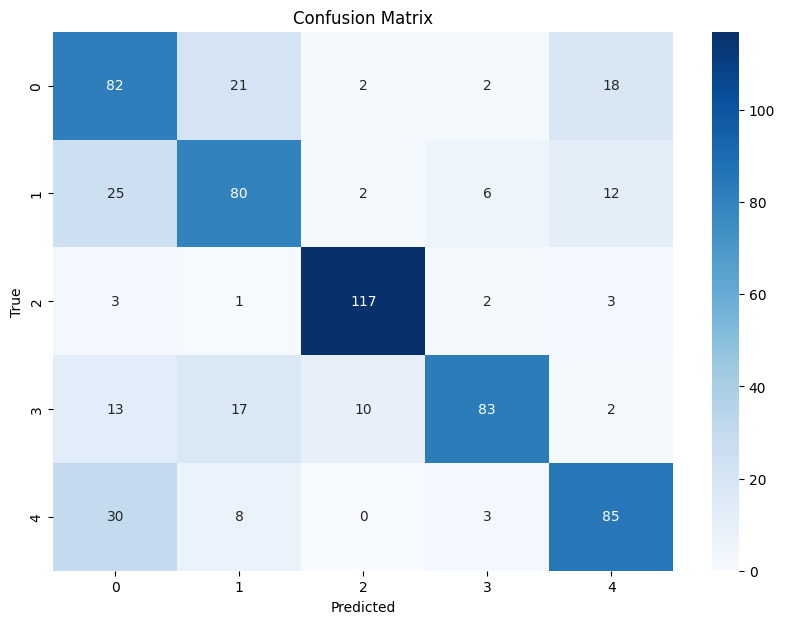

{
  "accuracy": 0.7129186602870813,
  "precision": 0.7263830819839707,
  "recall": 0.7126349206349207,
  "f1": 0.7155085322678059,
  "top_3_accuracy": 0.9617224880382775
}


In [ ]:
print("SUMMARY history")
print(f'Final train accuracy: {history_ft.history["accuracy"][-1]}')
print(f'Final train loss: {history_ft.history["loss"][-1]}')
print(f'Final valid accuracy: {history_ft.history["val_accuracy"][-1]}')
print(f'Final valid loss: {history_ft.history["val_loss"][-1]}')


print("======Test======")
y_true = ds_reduced_filtered['test']['labels']
y_pred = model.predict(tf_ds_test)
results_ft = eval_predicts(y_true, np.argmax(y_pred, axis=1), y_pred, k_values=[3],
        save_dir=FIGURES_DIR,
        save_name=f'cm_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_filt_test.png')
print(json.dumps(results_ft, indent=2))

Este segundo experimento ofrece peor evolución que el anterior, por tanto, aunque la convergencia de SGD ha sido más estable sus métricas son peores que previamente a pesar de haberle dedicado más épocas al proceso de entrenamiento, además sufre mucho underfitting.

### Experimento 3

Tras realizar los dos experimentos anteriores y observar que el experimento 1 ofrece mejores resultados se de ide probar a replicar el primer experimento pero modificando el batch size multiplicandolo por 8.

In [80]:
NAME_MODEL = 'vgg16'
IMG_SIZE = 224
BATCH_SIZE = 64
OPTIMIZER = 'Adam'
LOSS = 'sparse_categorical_crossentropy'
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = len(target_labels)
LEARNING_RATE_TL = 1e-4
EPOCHS_TL = 10

In [81]:
tf_ds_train,  tf_ds_valid, tf_ds_test = preprocess_hf_to_tf(
    ds_reduced_filtered,
    BATCH_SIZE, NAME_MODEL,
    column = 'image',
    label_column='labels')

In [82]:
base_model = load_model(
    name_model = NAME_MODEL,
    input_shape = (IMG_SIZE, IMG_SIZE, 3)
)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu',kernel_regularizer=l2(5e-5))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)
model = keras.Model(inputs=base_model.input, outputs=output)

In [83]:
history_tl, model, n_params_tl, n_trainable_tl = train_tl(
    base_model,
    model,
    tf_ds_train,
    tf_ds_valid,
    epochs=EPOCHS_TL,
    learning_rate = LEARNING_RATE_TL,
    loss=LOSS,
    optimizer=OPTIMIZER,
    callbacks=callbacks
)

Number of parameters: 14981957
Number of non-trainable parameters: 14715714
Number of trainable parameters: 266245
Training model...

Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 1/10


2026-01-05 18:49:48.738707: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-05 18:49:49.235783: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1787', 64 bytes spill stores, 64 bytes spill loads



45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.2508 - loss: 2.4352

2026-01-05 18:50:11.296263: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-05 18:50:11.794448: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_680', 20 bytes spill stores, 20 bytes spill loads



46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.2527 - loss: 2.4259

2026-01-05 18:50:18.210491: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_253', 4 bytes spill stores, 4 bytes spill loads

2026-01-05 18:50:18.420046: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_253', 52 bytes spill stores, 52 bytes spill loads



46/46 ━━━━━━━━━━━━━━━━━━━━ 37s 604ms/step - accuracy: 0.3412 - loss: 2.0087 - val_accuracy: 0.6345 - val_loss: 1.0870 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 348ms/step - accuracy: 0.5920 - loss: 1.1511 - val_accuracy: 0.7134 - val_loss: 0.8109 - learning_rate: 1.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 355ms/step - accuracy: 0.6581 - loss: 0.9626 - val_accuracy: 0.7585 - val_loss: 0.7012 - learning_rate: 1.0000e-04

Epoch 4: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 15s 317ms/step - accuracy: 0.6973 - loss: 0.8667 - val_accuracy: 0.7746 - val_loss: 0.6400 - learning_rate: 1.0000e-04

Epoch 5: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 15s 327ms/step - accuracy

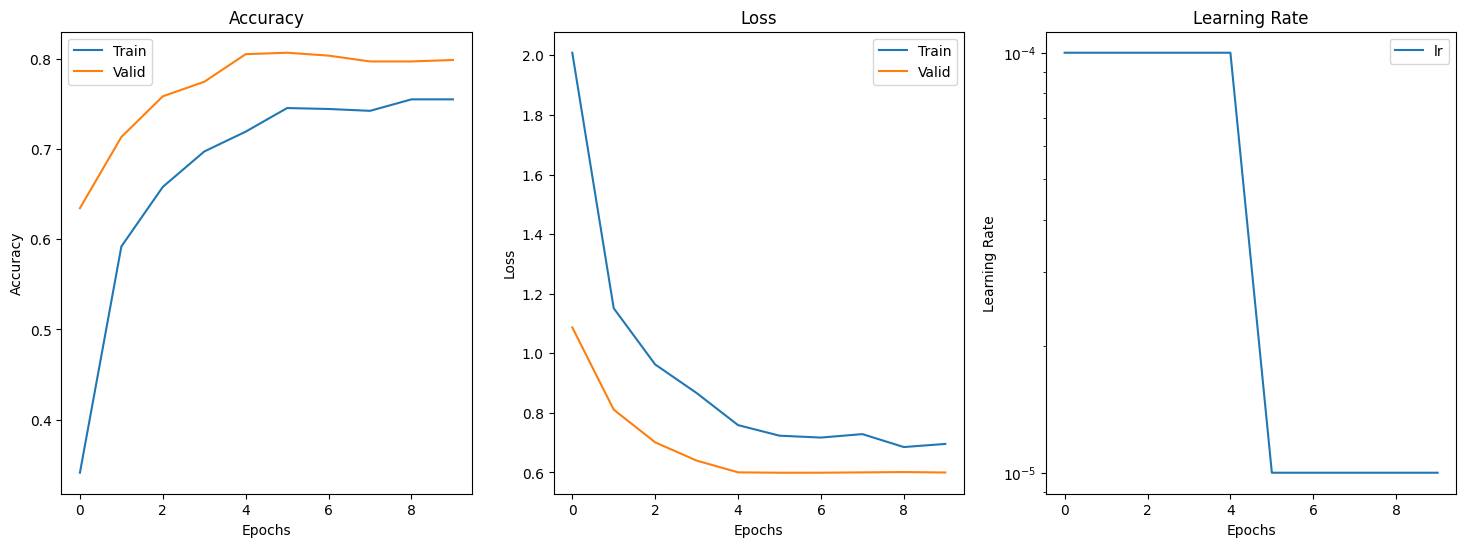

<Figure size 640x480 with 0 Axes>

In [84]:
plot_loss_accuracy(history_tl,
                   save_dir = FIGURES_DIR,
                   save_name = f'acc_loss_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_filt.png')

SUMMARY history
Final train accuracy: 0.7550739645957947
Final train loss: 0.6958562731742859
Final test accuracy: 0.7987117767333984
Final test loss: 0.5999726057052612
======Test======
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step

2026-01-05 18:52:46.557374: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_226', 4 bytes spill stores, 4 bytes spill loads

2026-01-05 18:52:46.819255: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_226', 52 bytes spill stores, 52 bytes spill loads



10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 777ms/step


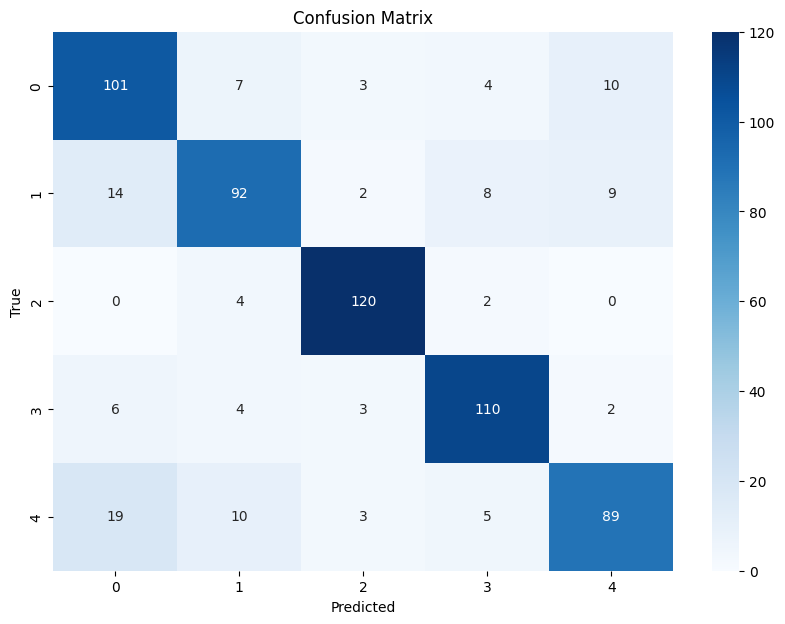

{
  "accuracy": 0.8165869218500797,
  "precision": 0.8171175958979969,
  "recall": 0.8165460317460317,
  "f1": 0.8153651779905344,
  "top_3_accuracy": 0.9760765550239234
}


In [ ]:
print("SUMMARY history")
print(f'Final train accuracy: {history_tl.history["accuracy"][-1]}')
print(f'Final train loss: {history_tl.history["loss"][-1]}')
print(f'Final valid accuracy: {history_tl.history["val_accuracy"][-1]}')
print(f'Final valid loss: {history_tl.history["val_loss"][-1]}')


print("======Test======")
y_true = ds_reduced_filtered['test']['labels']
y_pred = model.predict(tf_ds_test)
results_tl = eval_predicts(y_true, np.argmax(y_pred, axis=1), y_pred, k_values=[3],
        save_dir=FIGURES_DIR,
        save_name=f'cm_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_filt_test.png')
print(json.dumps(results_tl, indent=2))

In [86]:
LEARNING_RATE_FT = 1e-5
EPOCHS_FT = 10

In [87]:
history_ft, model, n_params_ft, n_trainable_ft = train_ft(
    base_model,
    model,
    tf_ds_train,
    tf_ds_valid,
    epochs=EPOCHS_FT,
    learning_rate = LEARNING_RATE_FT,
    loss=LOSS,
    optimizer=OPTIMIZER,
    callbacks=callbacks
)

Number of parameters: 14981957
Number of non-trainable parameters: 1026
Number of trainable parameters: 14980933
Training model...

Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 1/10


2026-01-05 18:53:11.265793: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng57{k2=0,k13=2,k14=2,k18=1,k23=0} for conv (f32[64,3,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,3,224,224]{3,2,1,0}, f32[64,64,224,224]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-01-05 18:53:11.725410: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.459701378s
Trying algorithm eng57{k2=0,k13=2,k14=2,k18=1,k23=0} for conv (f32[64,3,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[64,3,224,224]{3,2,1,0}, f32[64,64,224,224]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__

45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.7573 - loss: 0.6781

2026-01-05 18:53:47.397178: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-05 18:53:47.616253: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1859', 8 bytes spill stores, 8 bytes spill loads

2026-01-05 18:53:47.618520: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1859', 12 bytes spill stores, 12 bytes spill loads



46/46 ━━━━━━━━━━━━━━━━━━━━ 70s 821ms/step - accuracy: 0.7671 - loss: 0.6779 - val_accuracy: 0.8019 - val_loss: 0.5888 - learning_rate: 1.0000e-05

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 26s 564ms/step - accuracy: 0.7984 - loss: 0.5733 - val_accuracy: 0.8277 - val_loss: 0.5116 - learning_rate: 1.0000e-05

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 22s 482ms/step - accuracy: 0.8249 - loss: 0.5136 - val_accuracy: 0.8341 - val_loss: 0.5140 - learning_rate: 1.0000e-05

Epoch 4: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 24s 529ms/step - accuracy: 0.8431 - loss: 0.4678 - val_accuracy: 0.8454 - val_loss: 0.4817 - learning_rate: 1.0000e-05

Epoch 5: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 24s 528ms/step - accuracy

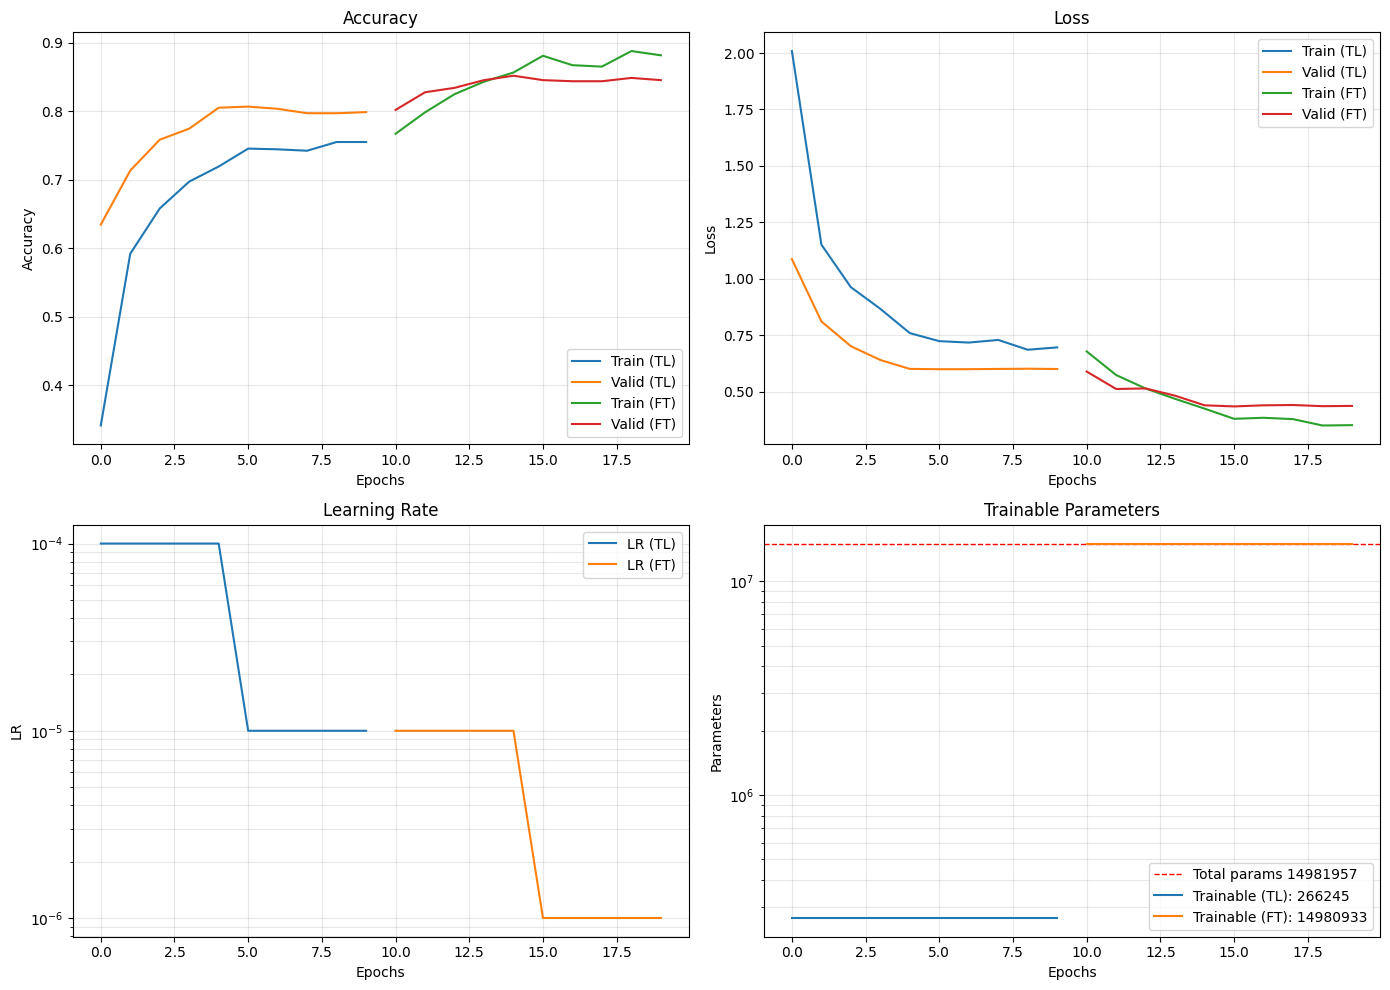

In [88]:
plot_loss_accuracy_tl_ft(history_tl,history_ft, n_trainable_tl, n_trainable_ft, n_params_tl,
                   save_dir = FIGURES_DIR,
                   save_name = f'acc_loss_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_filt.png')

SUMMARY history
Final train accuracy: 0.8816649317741394
Final train loss: 0.35131561756134033
Final test accuracy: 0.8454106450080872
Final test loss: 0.4365198612213135
======Test======
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 173ms/step


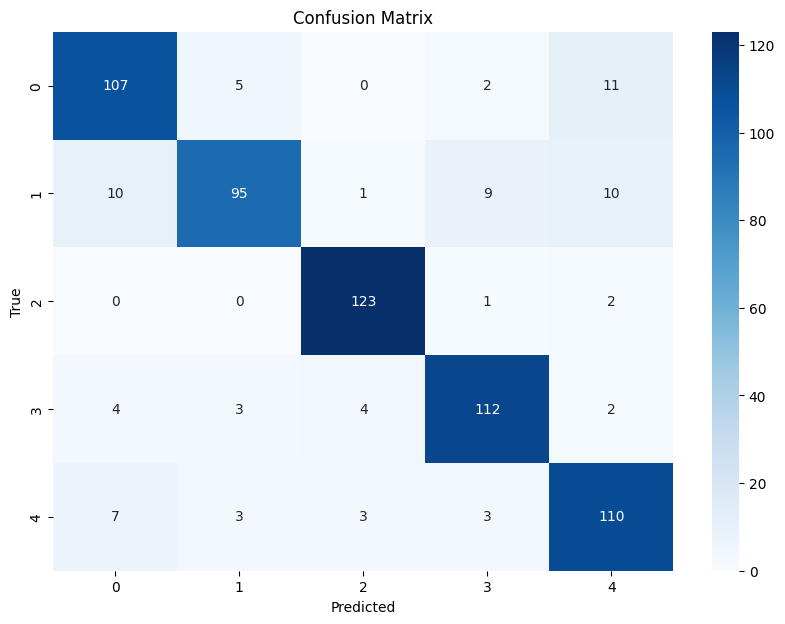

{
  "accuracy": 0.8724082934609251,
  "precision": 0.8735599582797212,
  "recall": 0.8722412698412698,
  "f1": 0.8714719669491311,
  "top_3_accuracy": 0.9872408293460925
}


In [ ]:
print("SUMMARY history")
print(f'Final train accuracy: {history_ft.history["accuracy"][-1]}')
print(f'Final train loss: {history_ft.history["loss"][-1]}')
print(f'Final valid accuracy: {history_ft.history["val_accuracy"][-1]}')
print(f'Final valid loss: {history_ft.history["val_loss"][-1]}')


print("======Test======")
y_true = ds_reduced_filtered['test']['labels']
y_pred = model.predict(tf_ds_test)
results_ft = eval_predicts(y_true, np.argmax(y_pred, axis=1), y_pred, k_values=[3],
        save_dir=FIGURES_DIR,
        save_name=f'cm_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_filt_test.png')
print(json.dumps(results_ft, indent=2))

Este entrenamiento ofrece una mejor generalización del modelo al incluir un BatchSize más grande, ofrece buenas métricas y un buen compromiso durante el proceso de entrenamiento entre los datos de train y validación

### Experimento 4

En este cuarto experimento se replica el mejor resultado probado previamente pero modificando el modelo a EfficientnetB0

In [90]:
NAME_MODEL = 'efficientnetb0'
IMG_SIZE = 224
BATCH_SIZE = 64
OPTIMIZER = 'Adam'
LOSS = 'sparse_categorical_crossentropy'
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = len(target_labels)
LEARNING_RATE_TL = 1e-4
EPOCHS_TL = 10

In [91]:
tf_ds_train,  tf_ds_valid, tf_ds_test = preprocess_hf_to_tf(
    ds_reduced_filtered,
    BATCH_SIZE, NAME_MODEL,
    column = 'image',
    label_column='labels')

In [92]:
base_model = load_model(
    name_model = NAME_MODEL,
    input_shape = (IMG_SIZE, IMG_SIZE, 3)
)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu',kernel_regularizer=l2(5e-5))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)
model = keras.Model(inputs=base_model.input, outputs=output)

In [93]:
history_tl, model, n_params_tl, n_trainable_tl = train_tl(
    base_model,
    model,
    tf_ds_train,
    tf_ds_valid,
    epochs=EPOCHS_TL,
    learning_rate = LEARNING_RATE_TL,
    loss=LOSS,
    optimizer=OPTIMIZER,
    callbacks=callbacks
)

Number of parameters: 4710056
Number of non-trainable parameters: 4050615
Number of trainable parameters: 659461
Training model...

Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 1/10


2026-01-05 18:57:55.267252: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-05 18:57:55.743761: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_11150', 64 bytes spill stores, 64 bytes spill loads

2026-01-05 18:57:59.647006: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 18:57:59.746704: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please 

45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step - accuracy: 0.3944 - loss: 1.8176

2026-01-05 18:58:17.804464: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 18:58:17.899231: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 18:58:17.999393: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 18:58:18.097176: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 18:58:18.199451: E external/local_xla/xla/stream_

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.3977 - loss: 1.8074

2026-01-05 18:58:33.253180: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 18:58:33.353172: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 18:58:33.771273: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 18:58:33.864511: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 18:58:33.965087: E external/local_xla/xla/stream_

46/46 ━━━━━━━━━━━━━━━━━━━━ 49s 703ms/step - accuracy: 0.5483 - loss: 1.3486 - val_accuracy: 0.7987 - val_loss: 0.8546 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 234ms/step - accuracy: 0.7527 - loss: 0.7213 - val_accuracy: 0.8293 - val_loss: 0.6511 - learning_rate: 1.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 203ms/step - accuracy: 0.7960 - loss: 0.5850 - val_accuracy: 0.8647 - val_loss: 0.5366 - learning_rate: 1.0000e-04

Epoch 4: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 214ms/step - accuracy: 0.8208 - loss: 0.5462 - val_accuracy: 0.8744 - val_loss: 0.4602 - learning_rate: 1.0000e-04

Epoch 5: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 9s 200ms/step - accuracy: 

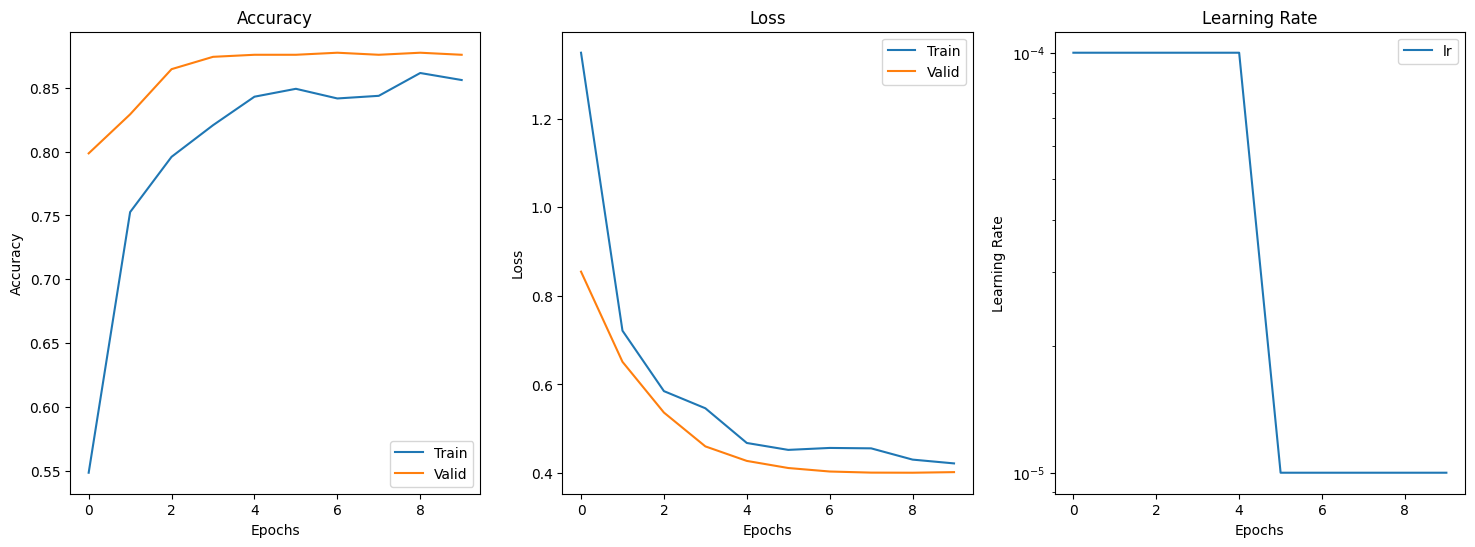

<Figure size 640x480 with 0 Axes>

In [94]:
plot_loss_accuracy(history_tl,
                   save_dir = FIGURES_DIR,
                   save_name = f'acc_loss_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_filt.png')

SUMMARY history
Final train accuracy: 0.8562091588973999
Final train loss: 0.42183324694633484
Final test accuracy: 0.8760064244270325
Final test loss: 0.4021385908126831
======Test======
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step

2026-01-05 19:00:20.483913: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:00:20.581529: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:00:20.684090: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:00:20.782149: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:00:20.884812: E external/local_xla/xla/stream_

10/10 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step


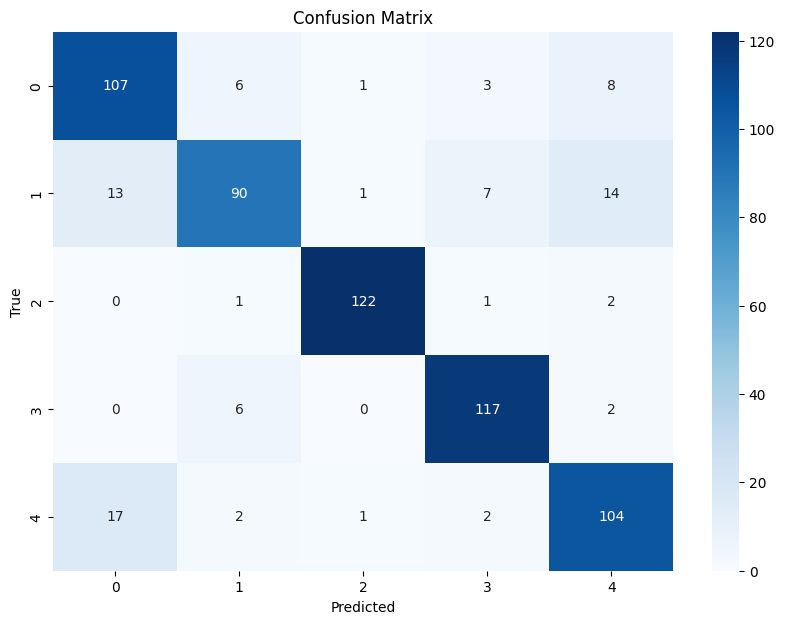

{
  "accuracy": 0.861244019138756,
  "precision": 0.8628329509906152,
  "recall": 0.8611301587301587,
  "f1": 0.860332240278067,
  "top_3_accuracy": 0.988835725677831
}


In [ ]:
print("SUMMARY history")
print(f'Final train accuracy: {history_tl.history["accuracy"][-1]}')
print(f'Final train loss: {history_tl.history["loss"][-1]}')
print(f'Final valid accuracy: {history_tl.history["val_accuracy"][-1]}')
print(f'Final valid loss: {history_tl.history["val_loss"][-1]}')


print("======Test======")
y_true = ds_reduced_filtered['test']['labels']
y_pred = model.predict(tf_ds_test)
results_tl = eval_predicts(y_true, np.argmax(y_pred, axis=1), y_pred, k_values=[3],
        save_dir=FIGURES_DIR,
        save_name=f'cm_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_filt_test.png')
print(json.dumps(results_tl, indent=2))

In [96]:
LEARNING_RATE_FT = 1e-5
EPOCHS_FT = 10

In [97]:
history_ft, model, n_params_ft, n_trainable_ft = train_ft(
    base_model,
    model,
    tf_ds_train,
    tf_ds_valid,
    epochs=EPOCHS_FT,
    learning_rate = LEARNING_RATE_FT,
    loss=LOSS,
    optimizer=OPTIMIZER,
    callbacks=callbacks
)

Number of parameters: 4710056
Number of non-trainable parameters: 85083
Number of trainable parameters: 4624993
Training model...

Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 1/10


2026-01-05 19:00:40.371860: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:00:40.474491: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:00:41.486755: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:00:41.615786: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:00:41.746606: E external/local_xla/xla/stream_

45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.8496 - loss: 0.4630

2026-01-05 19:01:13.977503: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:01:14.074872: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:01:14.176873: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:01:14.277789: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:01:15.028610: E external/local_xla/xla/stream_

46/46 ━━━━━━━━━━━━━━━━━━━━ 71s 826ms/step - accuracy: 0.8610 - loss: 0.4167 - val_accuracy: 0.8792 - val_loss: 0.3912 - learning_rate: 1.0000e-05

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 245ms/step - accuracy: 0.8806 - loss: 0.3671 - val_accuracy: 0.8857 - val_loss: 0.3833 - learning_rate: 1.0000e-05

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 239ms/step - accuracy: 0.8782 - loss: 0.3749 - val_accuracy: 0.8857 - val_loss: 0.3778 - learning_rate: 1.0000e-05

Epoch 4: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 13s 281ms/step - accuracy: 0.8827 - loss: 0.3642 - val_accuracy: 0.8857 - val_loss: 0.3694 - learning_rate: 1.0000e-05

Epoch 5: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 265ms/step - accuracy

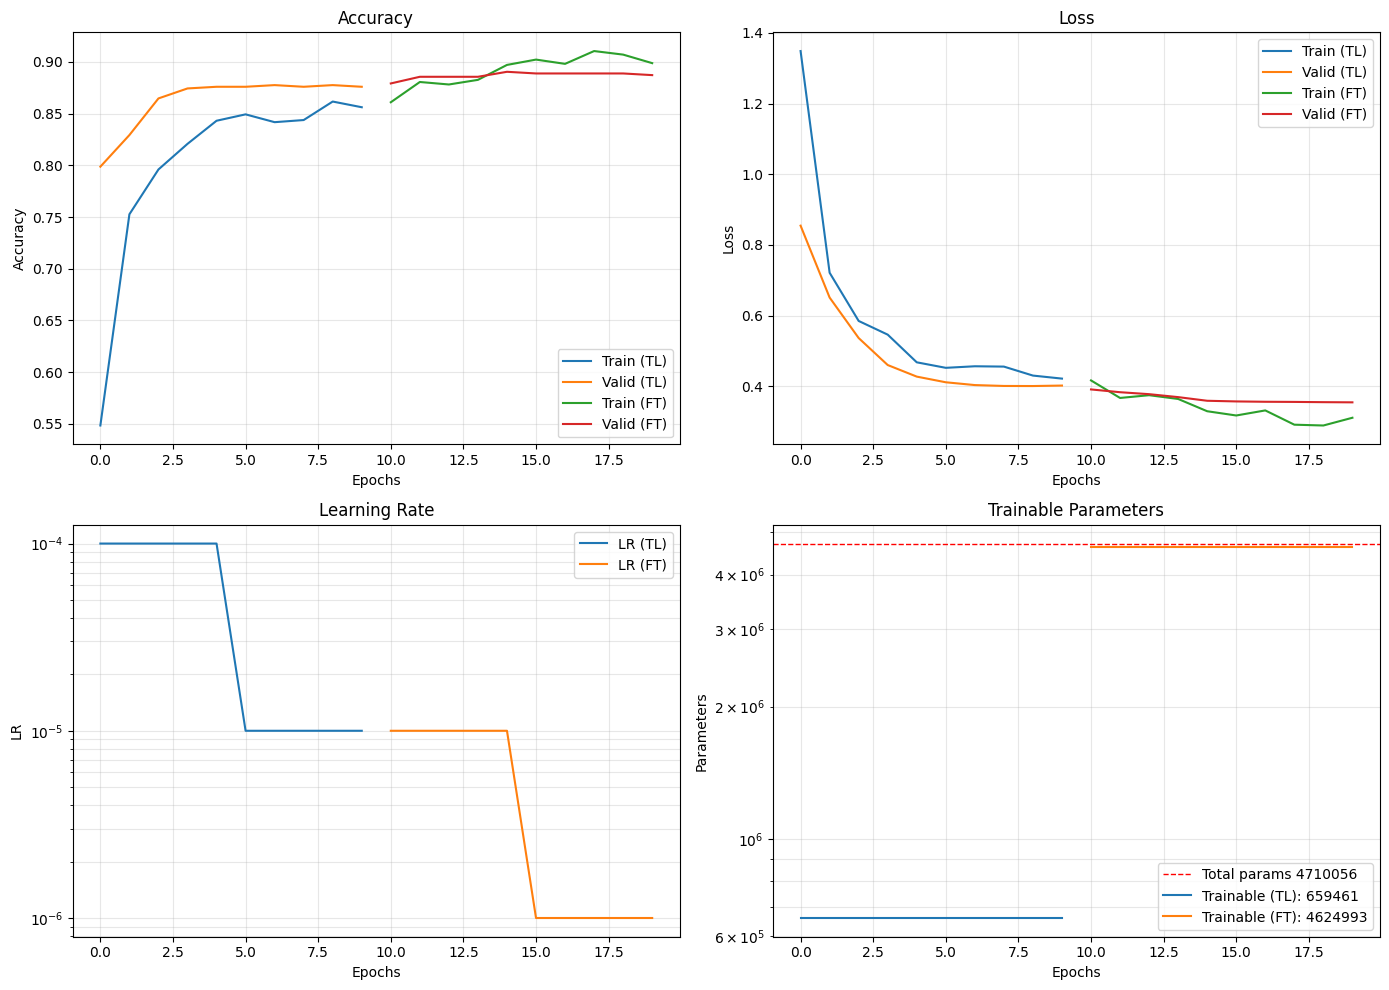

In [98]:
plot_loss_accuracy_tl_ft(history_tl,history_ft, n_trainable_tl, n_trainable_ft, n_params_tl,
                   save_dir = FIGURES_DIR,
                   save_name = f'acc_loss_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_filt.png')

SUMMARY history
Final train accuracy: 0.8988648056983948
Final train loss: 0.31106120347976685
Final test accuracy: 0.8872785568237305
Final test loss: 0.354677677154541
======Test======
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 476ms/step


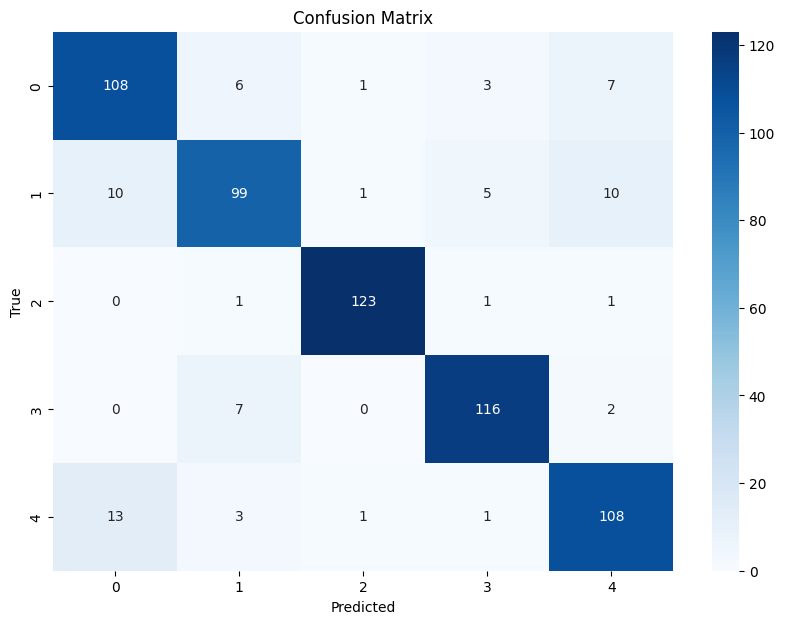

{
  "accuracy": 0.8835725677830941,
  "precision": 0.8836902307206993,
  "recall": 0.8834666666666667,
  "f1": 0.8832427458615953,
  "top_3_accuracy": 0.9920255183413078
}


In [ ]:
print("SUMMARY history")
print(f'Final train accuracy: {history_ft.history["accuracy"][-1]}')
print(f'Final train loss: {history_ft.history["loss"][-1]}')
print(f'Final valid accuracy: {history_ft.history["val_accuracy"][-1]}')
print(f'Final valid loss: {history_ft.history["val_loss"][-1]}')


print("======Test======")
y_true = ds_reduced_filtered['test']['labels']
y_pred = model.predict(tf_ds_test)
results_ft = eval_predicts(y_true, np.argmax(y_pred, axis=1), y_pred, k_values=[3],
        save_dir=FIGURES_DIR,
        save_name=f'cm_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_filt_test.png')
print(json.dumps(results_ft, indent=2))

El modelo Efficientnet B0 ofrece muy buen compromiso entre todas las métricas y aparentemente generaliza ligeramente mejor que VGG16

### Experimento 5

Modeloo con más parámetros de la familia de Efficientnet, se espera que evolucione mejor al contener más parámetros de entrenamiento

In [100]:
NAME_MODEL = 'efficientnetb3'
IMG_SIZE = 224
BATCH_SIZE = 64
OPTIMIZER = 'Adam'
LOSS = 'sparse_categorical_crossentropy'
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = len(target_labels)
LEARNING_RATE_TL = 1e-4
EPOCHS_TL = 10

In [101]:
tf_ds_train,  tf_ds_valid, tf_ds_test = preprocess_hf_to_tf(
    ds_reduced_filtered,
    BATCH_SIZE, NAME_MODEL,
    column = 'image',
    label_column='labels')

In [102]:
base_model = load_model(
    name_model = NAME_MODEL,
    input_shape = (IMG_SIZE, IMG_SIZE, 3)
)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu',kernel_regularizer=l2(5e-5))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)
model = keras.Model(inputs=base_model.input, outputs=output)

In [103]:
history_tl, model, n_params_tl, n_trainable_tl = train_tl(
    base_model,
    model,
    tf_ds_train,
    tf_ds_valid,
    epochs=EPOCHS_TL,
    learning_rate = LEARNING_RATE_TL,
    loss=LOSS,
    optimizer=OPTIMIZER,
    callbacks=callbacks
)

Number of parameters: 11575092
Number of non-trainable parameters: 10784599
Number of trainable parameters: 790533
Training model...

Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 1/10


2026-01-05 19:03:45.771556: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-05 19:03:46.287160: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19154', 64 bytes spill stores, 64 bytes spill loads

2026-01-05 19:03:49.515496: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:03:49.609721: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please 

45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step - accuracy: 0.4483 - loss: 1.7222

2026-01-05 19:04:16.259771: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:04:16.350794: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:04:16.451476: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:04:16.552926: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:04:16.653847: E external/local_xla/xla/stream_

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.4511 - loss: 1.7127

2026-01-05 19:04:36.518895: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:04:36.609393: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:04:36.716353: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:04:36.821412: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:04:36.926401: E external/local_xla/xla/stream_

46/46 ━━━━━━━━━━━━━━━━━━━━ 69s 919ms/step - accuracy: 0.5803 - loss: 1.2850 - val_accuracy: 0.8277 - val_loss: 0.8155 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 235ms/step - accuracy: 0.7726 - loss: 0.7110 - val_accuracy: 0.8406 - val_loss: 0.6247 - learning_rate: 1.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 237ms/step - accuracy: 0.8211 - loss: 0.5865 - val_accuracy: 0.8470 - val_loss: 0.5277 - learning_rate: 1.0000e-04

Epoch 4: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 249ms/step - accuracy: 0.8311 - loss: 0.5204 - val_accuracy: 0.8519 - val_loss: 0.4642 - learning_rate: 1.0000e-04

Epoch 5: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 260ms/step - accuracy

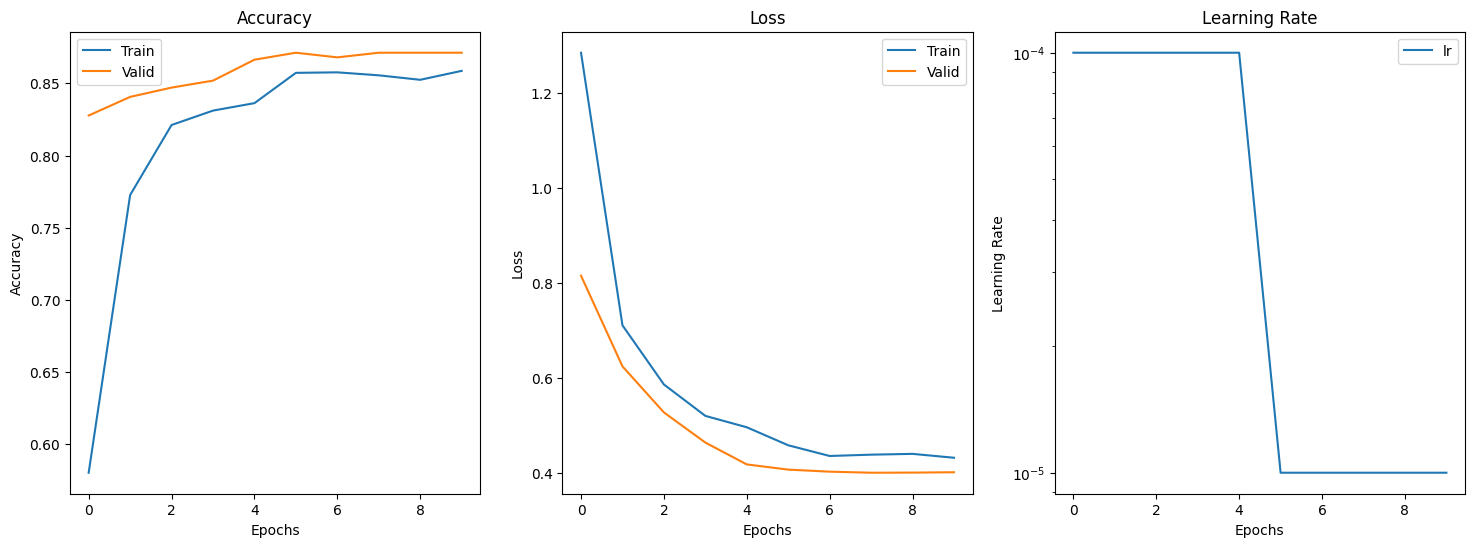

<Figure size 640x480 with 0 Axes>

In [104]:
plot_loss_accuracy(history_tl,
                   save_dir = FIGURES_DIR,
                   save_name = f'acc_loss_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_filt.png')

SUMMARY history
Final train accuracy: 0.8586171269416809
Final train loss: 0.43225324153900146
Final test accuracy: 0.8711755275726318
Final test loss: 0.4017334580421448
======Test======
 9/10 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step

2026-01-05 19:06:38.413380: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:06:38.507418: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:06:38.615957: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:06:38.721504: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:06:38.827369: E external/local_xla/xla/stream_

10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step


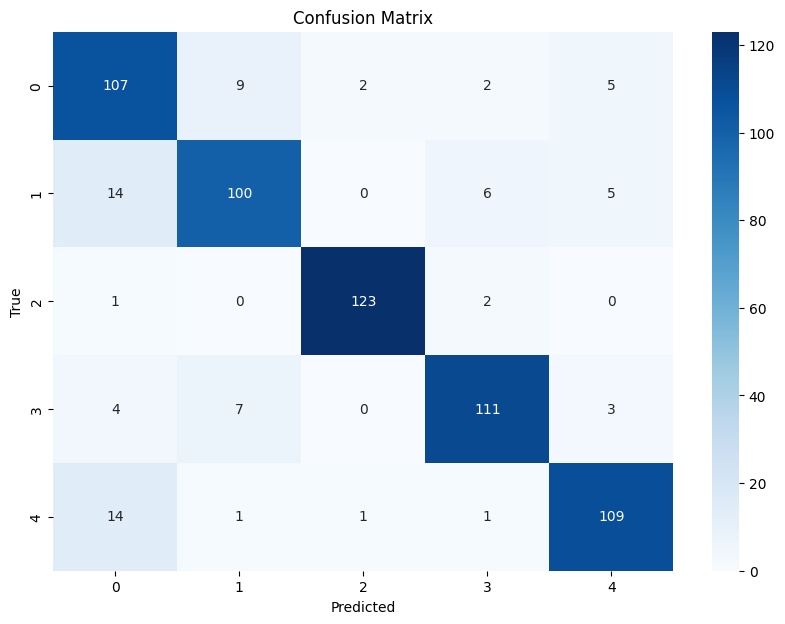

{
  "accuracy": 0.8771929824561403,
  "precision": 0.879691146740327,
  "recall": 0.8770539682539683,
  "f1": 0.8776003220318527,
  "top_3_accuracy": 0.9920255183413078
}


In [ ]:
print("SUMMARY history")
print(f'Final train accuracy: {history_tl.history["accuracy"][-1]}')
print(f'Final train loss: {history_tl.history["loss"][-1]}')
print(f'Final valid accuracy: {history_tl.history["val_accuracy"][-1]}')
print(f'Final valid loss: {history_tl.history["val_loss"][-1]}')


print("======Test======")
y_true = ds_reduced_filtered['test']['labels']
y_pred = model.predict(tf_ds_test)
results_tl = eval_predicts(y_true, np.argmax(y_pred, axis=1), y_pred, k_values=[3],
        save_dir=FIGURES_DIR,
        save_name=f'cm_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_filt_test.png')
print(json.dumps(results_tl, indent=2))

In [106]:
LEARNING_RATE_FT = 1e-5
EPOCHS_FT = 10

In [107]:
history_ft, model, n_params_ft, n_trainable_ft = train_ft(
    base_model,
    model,
    tf_ds_train,
    tf_ds_valid,
    epochs=EPOCHS_FT,
    learning_rate = LEARNING_RATE_FT,
    loss=LOSS,
    optimizer=OPTIMIZER,
    callbacks=callbacks
)

Number of parameters: 11575092
Number of non-trainable parameters: 175663
Number of trainable parameters: 11399469
Training model...

Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 1/10


2026-01-05 19:07:10.171856: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:07:10.274459: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:07:11.336975: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:07:11.480340: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:07:12.503947: E external/local_xla/xla/stream_

45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 282ms/step - accuracy: 0.8598 - loss: 0.4315

2026-01-05 19:07:52.205910: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:07:52.307624: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:07:53.268598: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:07:53.398158: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-05 19:07:54.278657: E external/local_xla/xla/stream_

46/46 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.8586 - loss: 0.4302 - val_accuracy: 0.8744 - val_loss: 0.3872 - learning_rate: 1.0000e-05

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 15s 332ms/step - accuracy: 0.8813 - loss: 0.3950 - val_accuracy: 0.8808 - val_loss: 0.3661 - learning_rate: 1.0000e-05

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 347ms/step - accuracy: 0.8944 - loss: 0.3378 - val_accuracy: 0.8905 - val_loss: 0.3560 - learning_rate: 1.0000e-05

Epoch 4: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 337ms/step - accuracy: 0.8996 - loss: 0.3332 - val_accuracy: 0.9002 - val_loss: 0.3453 - learning_rate: 1.0000e-05

Epoch 5: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 15s 329ms/step - accuracy: 0

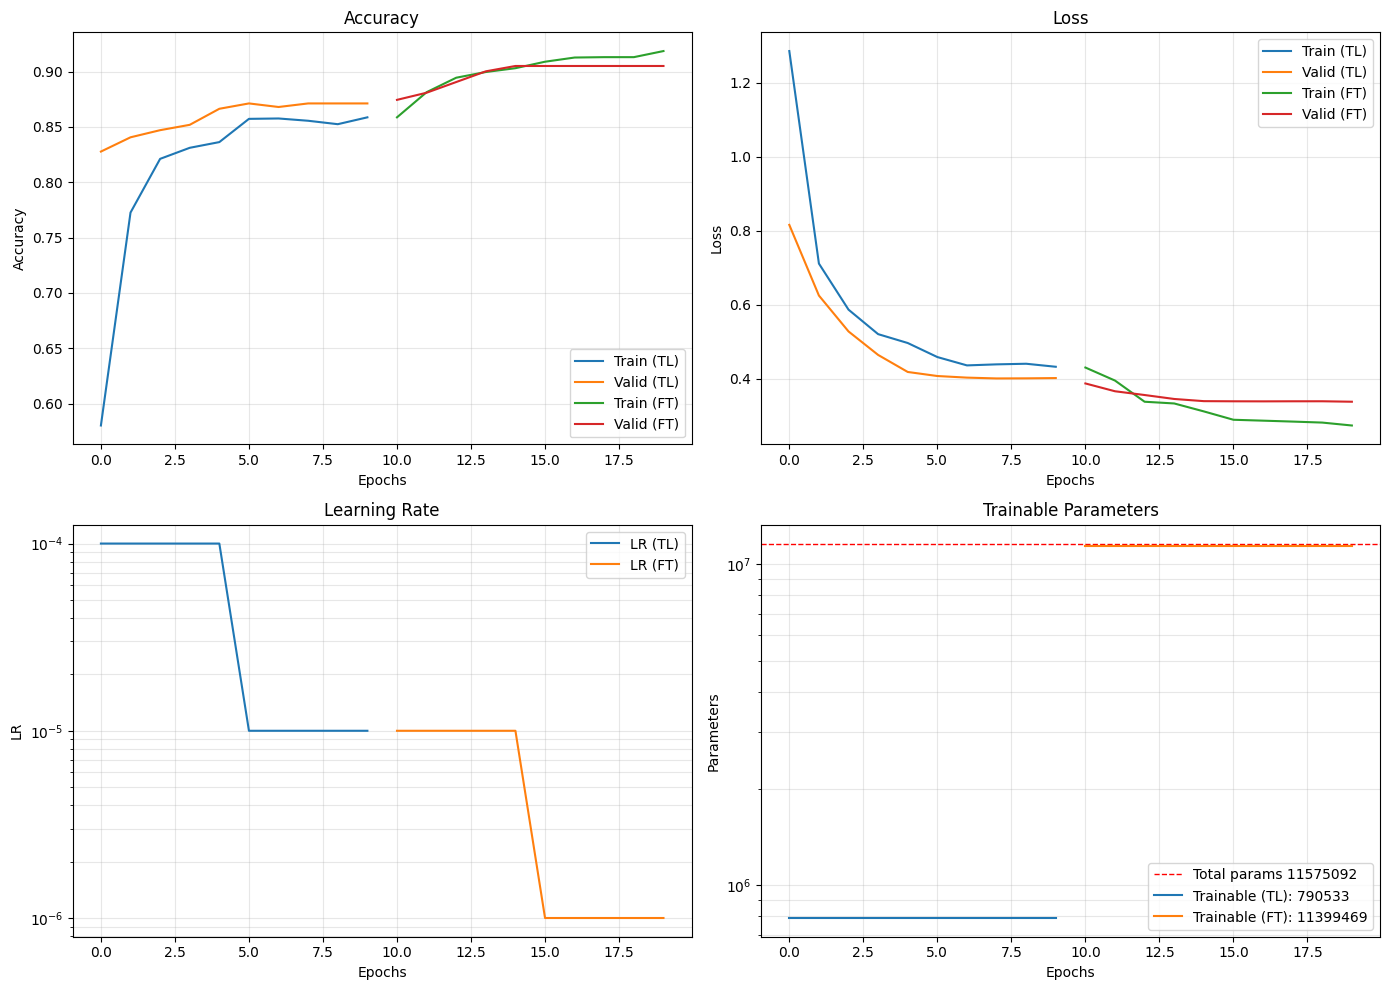

In [108]:
plot_loss_accuracy_tl_ft(history_tl,history_ft, n_trainable_tl, n_trainable_ft, n_params_tl,
                   save_dir = FIGURES_DIR,
                   save_name = f'acc_loss_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_filt.png')

SUMMARY history
Final train accuracy: 0.9184726476669312
Final train loss: 0.2736276090145111
Final test accuracy: 0.9049919247627258
Final test loss: 0.3378344178199768
======Test======
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 691ms/step


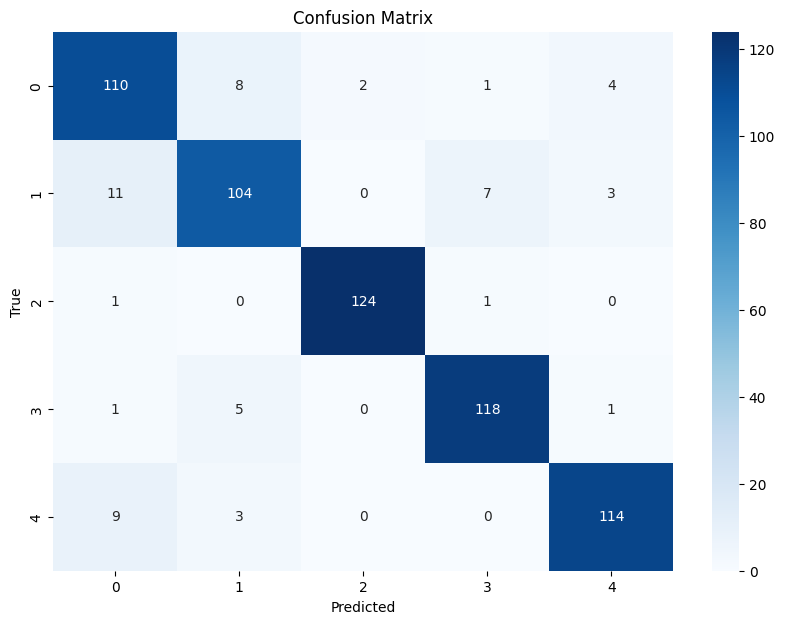

{
  "accuracy": 0.9090909090909091,
  "precision": 0.9095374143805796,
  "recall": 0.9089777777777778,
  "f1": 0.9090000959172004,
  "top_3_accuracy": 0.9952153110047847
}


In [ ]:
print("SUMMARY history")
print(f'Final train accuracy: {history_ft.history["accuracy"][-1]}')
print(f'Final train loss: {history_ft.history["loss"][-1]}')
print(f'Final valid accuracy: {history_ft.history["val_accuracy"][-1]}')
print(f'Final valid loss: {history_ft.history["val_loss"][-1]}')


print("======Test======")
y_true = ds_reduced_filtered['test']['labels']
y_pred = model.predict(tf_ds_test)
results_ft = eval_predicts(y_true, np.argmax(y_pred, axis=1), y_pred, k_values=[3],
        save_dir=FIGURES_DIR,
        save_name=f'cm_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_filt_test.png')
print(json.dumps(results_ft, indent=2))

El entrenamiento en Transfer Learning comenzó muy bien, aunque le era dificil generalizar los datos de entrenamiento pero finalmente en finetuning se sobreespecializó demasiado, aunque presenta mucho mejores métricas sobre los datos de prueba.

### Experimento 6

Ahora se va a probar con VGG19 que cuenta con más capas que VGG16.

In [110]:
NAME_MODEL = 'vgg19'
IMG_SIZE = 224
BATCH_SIZE = 64
OPTIMIZER = 'Adam'
LOSS = 'sparse_categorical_crossentropy'
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = len(target_labels)
LEARNING_RATE_TL = 1e-4
EPOCHS_TL = 10

In [111]:
tf_ds_train,  tf_ds_valid, tf_ds_test = preprocess_hf_to_tf(
    ds_reduced_filtered,
    BATCH_SIZE, NAME_MODEL,
    column = 'image',
    label_column='labels')

In [112]:
base_model = load_model(
    name_model = NAME_MODEL,
    input_shape = (IMG_SIZE, IMG_SIZE, 3)
)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu',kernel_regularizer=l2(5e-5))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)
model = keras.Model(inputs=base_model.input, outputs=output)

In [113]:
history_tl, model, n_params_tl, n_trainable_tl = train_tl(
    base_model,
    model,
    tf_ds_train,
    tf_ds_valid,
    epochs=EPOCHS_TL,
    learning_rate = LEARNING_RATE_TL,
    loss=LOSS,
    optimizer=OPTIMIZER,
    callbacks=callbacks
)

Number of parameters: 20291653
Number of non-trainable parameters: 20025410
Number of trainable parameters: 266245
Training model...

Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 22s 420ms/step - accuracy: 0.3935 - loss: 1.7529 - val_accuracy: 0.6296 - val_loss: 0.9772 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 18s 384ms/step - accuracy: 0.6133 - loss: 1.0910 - val_accuracy: 0.7198 - val_loss: 0.7630 - learning_rate: 1.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 16s 345ms/step - accuracy: 0.6629 - loss: 0.9005 - val_accuracy: 0.7665 - val_loss: 0.6581 - learning_rate: 1.0000e-04

Epoch 4: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 15s 318ms/step - accuracy: 0.7110 - lo

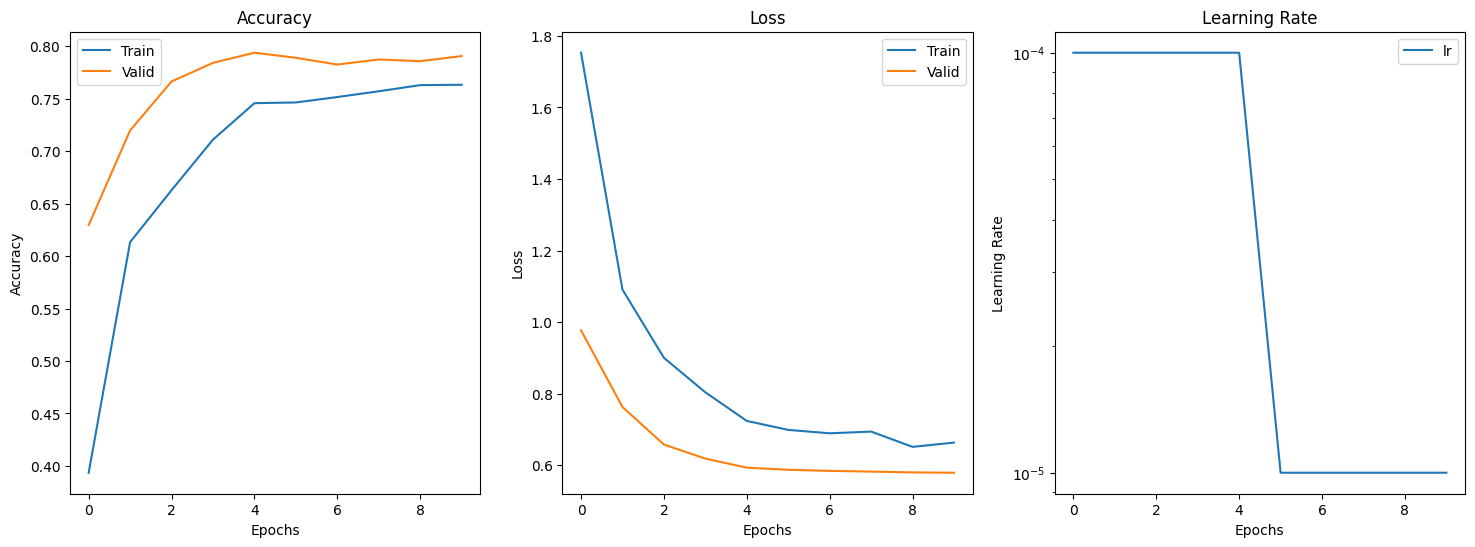

<Figure size 640x480 with 0 Axes>

In [114]:
plot_loss_accuracy(history_tl,
                   save_dir = FIGURES_DIR,
                   save_name = f'acc_loss_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_filt.png')

SUMMARY history
Final train accuracy: 0.7633299231529236
Final train loss: 0.6636101007461548
Final test accuracy: 0.7906602025032043
Final test loss: 0.5794053077697754
======Test======
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 202ms/step


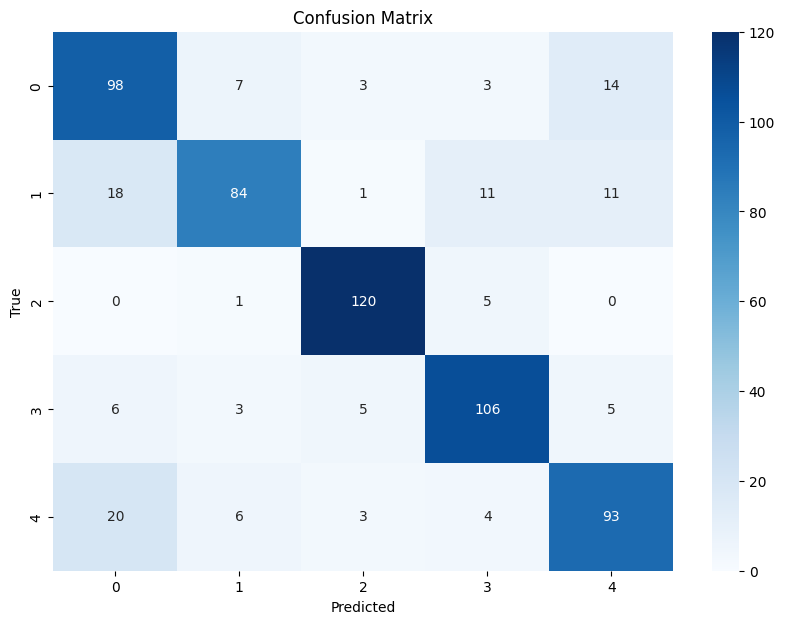

{
  "accuracy": 0.7990430622009569,
  "precision": 0.8017435819620724,
  "recall": 0.798895238095238,
  "f1": 0.7978622816200509,
  "top_3_accuracy": 0.9712918660287081
}


In [ ]:
print("SUMMARY history")
print(f'Final train accuracy: {history_tl.history["accuracy"][-1]}')
print(f'Final train loss: {history_tl.history["loss"][-1]}')
print(f'Final valid accuracy: {history_tl.history["val_accuracy"][-1]}')
print(f'Final valid loss: {history_tl.history["val_loss"][-1]}')


print("======Test======")
y_true = ds_reduced_filtered['test']['labels']
y_pred = model.predict(tf_ds_test)
results_tl = eval_predicts(y_true, np.argmax(y_pred, axis=1), y_pred, k_values=[3],
        save_dir=FIGURES_DIR,
        save_name=f'cm_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_filt_test.png')
print(json.dumps(results_tl, indent=2))

In [116]:
LEARNING_RATE_FT = 1e-5
EPOCHS_FT = 10

In [117]:
history_ft, model, n_params_ft, n_trainable_ft = train_ft(
    base_model,
    model,
    tf_ds_train,
    tf_ds_valid,
    epochs=EPOCHS_FT,
    learning_rate = LEARNING_RATE_FT,
    loss=LOSS,
    optimizer=OPTIMIZER,
    callbacks=callbacks
)

Number of parameters: 20291653
Number of non-trainable parameters: 1026
Number of trainable parameters: 20290629
Training model...

Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 1/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 37s 696ms/step - accuracy: 0.7592 - loss: 0.6808 - val_accuracy: 0.8116 - val_loss: 0.5604 - learning_rate: 1.0000e-05

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 28s 613ms/step - accuracy: 0.8063 - loss: 0.5448 - val_accuracy: 0.8132 - val_loss: 0.5251 - learning_rate: 1.0000e-05

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 28s 609ms/step - accuracy: 0.8345 - loss: 0.4652 - val_accuracy: 0.8325 - val_loss: 0.4596 - learning_rate: 1.0000e-05

Epoch 4: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 24s 522ms/step - accuracy: 0.8504 - loss

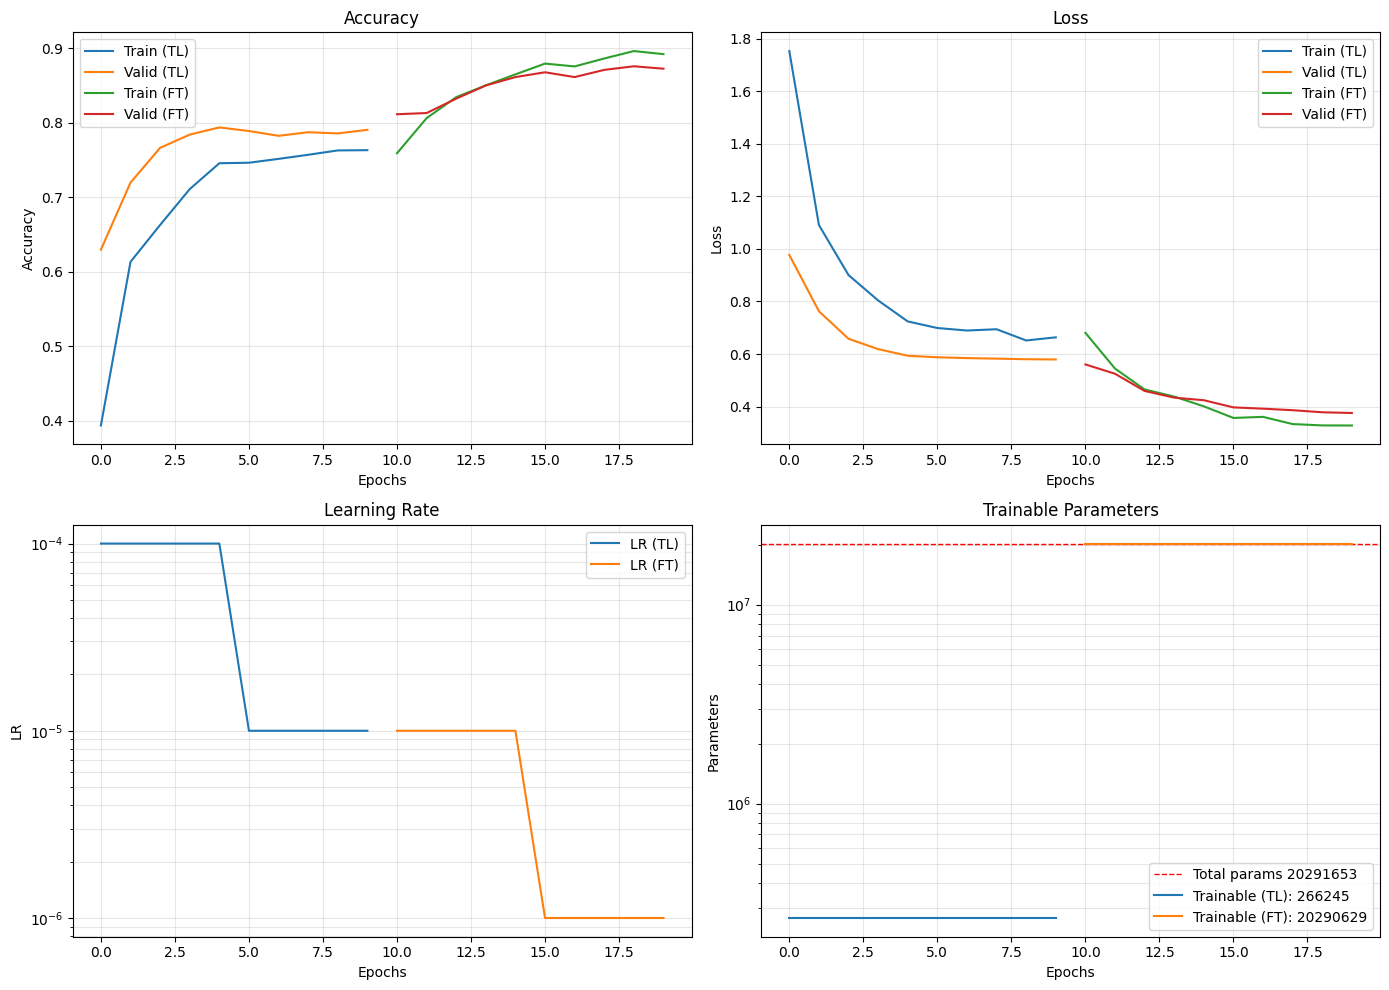

In [118]:
plot_loss_accuracy_tl_ft(history_tl,history_ft, n_trainable_tl, n_trainable_ft, n_params_tl,
                   save_dir = FIGURES_DIR,
                   save_name = f'acc_loss_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_filt.png')

SUMMARY history
Final train accuracy: 0.8923288583755493
Final train loss: 0.32812973856925964
Final test accuracy: 0.8727858066558838
Final test loss: 0.375680148601532
======Test======
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 193ms/step


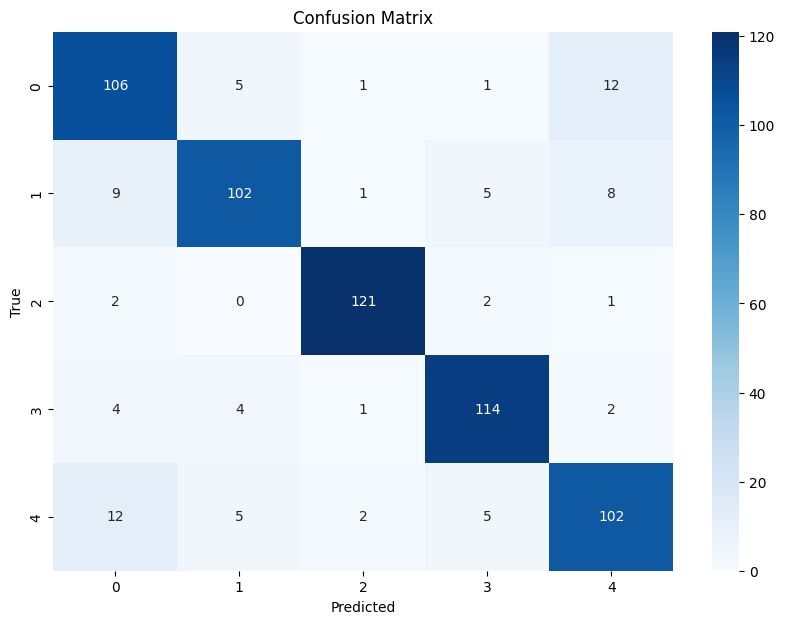

{
  "accuracy": 0.8692185007974481,
  "precision": 0.8700516163247288,
  "recall": 0.8691682539682539,
  "f1": 0.8692013648931323,
  "top_3_accuracy": 0.9904306220095693
}


In [ ]:
print("SUMMARY history")
print(f'Final train accuracy: {history_ft.history["accuracy"][-1]}')
print(f'Final train loss: {history_ft.history["loss"][-1]}')
print(f'Final valid accuracy: {history_ft.history["val_accuracy"][-1]}')
print(f'Final valid loss: {history_ft.history["val_loss"][-1]}')


print("======Test======")
y_true = ds_reduced_filtered['test']['labels']
y_pred = model.predict(tf_ds_test)
results_ft = eval_predicts(y_true, np.argmax(y_pred, axis=1), y_pred, k_values=[3],
        save_dir=FIGURES_DIR,
        save_name=f'cm_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_filt_test.png')
print(json.dumps(results_ft, indent=2))

Este modelo no ha conseguido mejorar a VGG16

## Escenario 2: Entrenamiento dataset filtrado

El siguiente paso es probar a realizar el entrenamiento sobre el ds filtrado, se agiliza el proceso y solo se invocará la configuración que mejor resultados ha dado

### Experimento 1

In [120]:
NAME_MODEL = 'vgg16'
IMG_SIZE = 224
BATCH_SIZE = 64
OPTIMIZER = 'Adam'
LOSS = 'sparse_categorical_crossentropy'
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = len(labels)
LEARNING_RATE_TL = 1e-4
EPOCHS_TL = 10

In [121]:
tf_ds_train,  tf_ds_valid, tf_ds_test = preprocess_hf_to_tf(
    ds_filtered,
    BATCH_SIZE, NAME_MODEL,
    column = 'image',
    label_column='labels')

In [122]:
base_model = load_model(
    name_model = NAME_MODEL,
    input_shape = (IMG_SIZE, IMG_SIZE, 3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu',kernel_regularizer=l2(5e-5))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)
model = keras.Model(inputs=base_model.input, outputs=output)

In [123]:
history_tl, model, n_params_tl, n_trainable_tl = train_tl(
    base_model,
    model,
    tf_ds_train,
    tf_ds_valid,
    epochs=EPOCHS_TL,
    learning_rate = LEARNING_RATE_TL,
    loss=LOSS,
    optimizer=OPTIMIZER,
    callbacks=callbacks
)

Number of parameters: 14987087
Number of non-trainable parameters: 14715714
Number of trainable parameters: 271375
Training model...

Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 1/10
136/137 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step - accuracy: 0.1428 - loss: 3.3224

2026-01-05 19:19:14.581056: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1127', 12 bytes spill stores, 24 bytes spill loads



137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.1433 - loss: 3.3193

2026-01-05 19:19:22.247748: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_253', 12 bytes spill stores, 24 bytes spill loads



137/137 ━━━━━━━━━━━━━━━━━━━━ 54s 374ms/step - accuracy: 0.2132 - loss: 2.9023 - val_accuracy: 0.4097 - val_loss: 2.0292 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 2/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 46s 336ms/step - accuracy: 0.3863 - loss: 2.0770 - val_accuracy: 0.5051 - val_loss: 1.6468 - learning_rate: 1.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 3/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 49s 360ms/step - accuracy: 0.4570 - loss: 1.8357 - val_accuracy: 0.5475 - val_loss: 1.5083 - learning_rate: 1.0000e-04

Epoch 4: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 4/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 44s 321ms/step - accuracy: 0.4933 - loss: 1.6646 - val_accuracy: 0.5668 - val_loss: 1.4252 - learning_rate: 1.0000e-04

Epoch 5: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 5/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 46s 334ms/step 

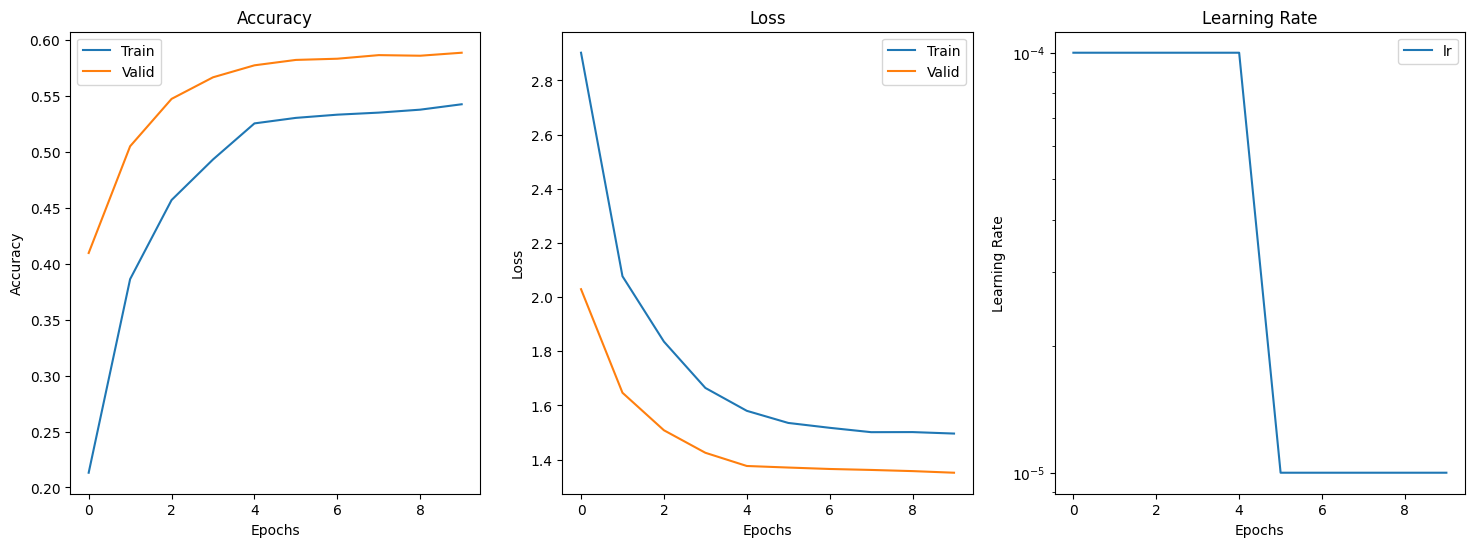

<Figure size 640x480 with 0 Axes>

In [124]:
plot_loss_accuracy(history_tl,
                   save_dir = FIGURES_DIR,
                   save_name = f'acc_loss_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_filt.png')

SUMMARY history
Final train accuracy: 0.5426472425460815
Final train loss: 1.4961351156234741
Final test accuracy: 0.5887399315834045
Final test loss: 1.3515329360961914
======Test======
30/30 ━━━━━━━━━━━━━━━━━━━━ 8s 247ms/step


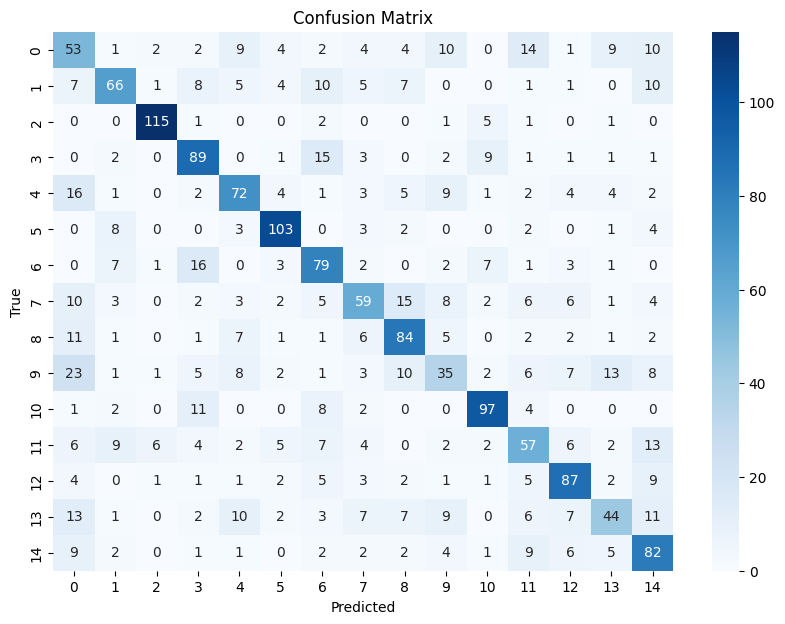

{
  "accuracy": 0.5993589743589743,
  "precision": 0.5967655042281399,
  "recall": 0.5989242600007275,
  "f1": 0.5942411839054464,
  "top_3_accuracy": 0.8306623931623932,
  "top_5_accuracy": 0.9139957264957265
}


In [ ]:
print("SUMMARY history")
print(f'Final train accuracy: {history_tl.history["accuracy"][-1]}')
print(f'Final train loss: {history_tl.history["loss"][-1]}')
print(f'Final valid accuracy: {history_tl.history["val_accuracy"][-1]}')
print(f'Final valid loss: {history_tl.history["val_loss"][-1]}')


print("======Test======")
y_true = ds_filtered['test']['labels']
y_pred = model.predict(tf_ds_test)
results_tl = eval_predicts(y_true, np.argmax(y_pred, axis=1), y_pred, k_values=[3,5],
        save_dir=FIGURES_DIR,
        save_name=f'cm_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_filt_test.png')
print(json.dumps(results_tl, indent=2))

In [126]:
LEARNING_RATE_FT = 1e-5
EPOCHS_FT = 10

In [127]:
history_ft, model, n_params_ft, n_trainable_ft = train_ft(
    base_model,
    model,
    tf_ds_train,
    tf_ds_valid,
    epochs=EPOCHS_FT,
    learning_rate = LEARNING_RATE_FT,
    loss=LOSS,
    optimizer=OPTIMIZER,
    callbacks=callbacks
)

Number of parameters: 14987087
Number of non-trainable parameters: 1026
Number of trainable parameters: 14986063
Training model...

Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 1/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 80s 543ms/step - accuracy: 0.5692 - loss: 1.4027 - val_accuracy: 0.6182 - val_loss: 1.2531 - learning_rate: 1.0000e-05

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 2/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 69s 500ms/step - accuracy: 0.6036 - loss: 1.2800 - val_accuracy: 0.6338 - val_loss: 1.2287 - learning_rate: 1.0000e-05

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 3/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 77s 559ms/step - accuracy: 0.6285 - loss: 1.1931 - val_accuracy: 0.6461 - val_loss: 1.1670 - learning_rate: 1.0000e-05

Epoch 4: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 4/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 76s 557ms/step - accuracy: 0.656

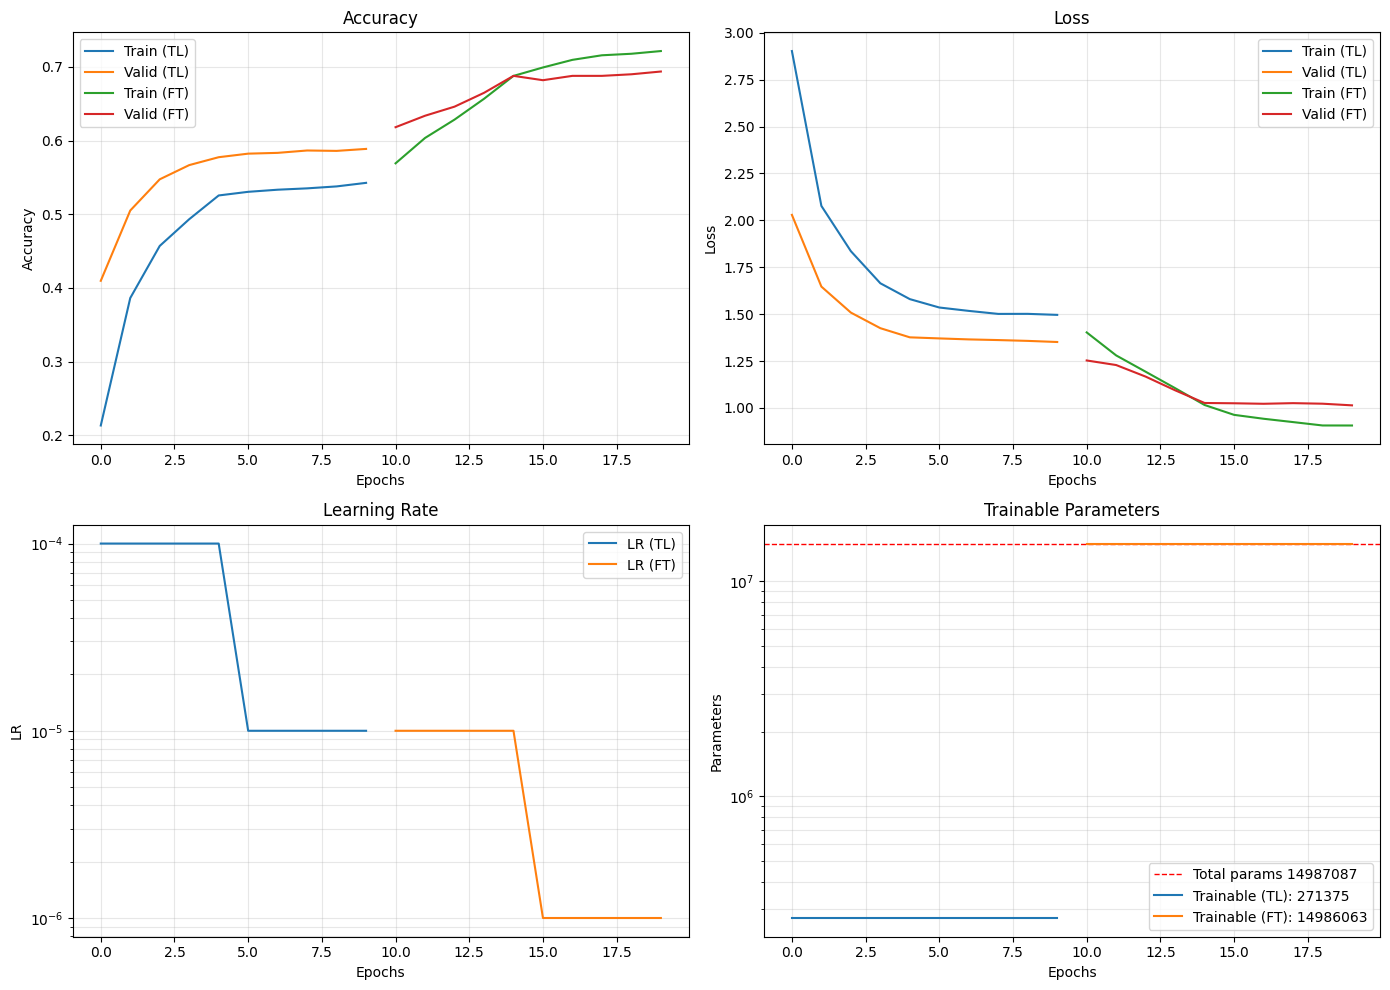

In [128]:
plot_loss_accuracy_tl_ft(history_tl,history_ft, n_trainable_tl, n_trainable_ft, n_params_tl,
                   save_dir = FIGURES_DIR,
                   save_name = f'acc_loss_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_filt.png')

SUMMARY history
Final train accuracy: 0.7216163277626038
Final train loss: 0.9064657092094421
Final test accuracy: 0.6938337683677673
Final test loss: 1.0138872861862183
======Test======
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 159ms/step


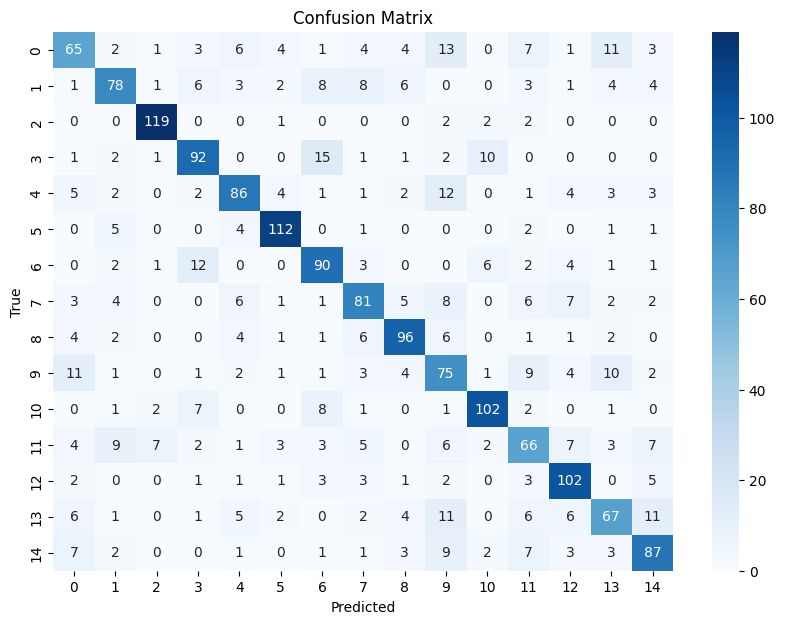

{
  "accuracy": 0.7040598290598291,
  "precision": 0.7026301752508324,
  "recall": 0.7037910525770916,
  "f1": 0.7020417304309647,
  "top_3_accuracy": 0.9027777777777778,
  "top_5_accuracy": 0.9540598290598291
}


In [ ]:
print("SUMMARY history")
print(f'Final train accuracy: {history_ft.history["accuracy"][-1]}')
print(f'Final train loss: {history_ft.history["loss"][-1]}')
print(f'Final valid accuracy: {history_ft.history["val_accuracy"][-1]}')
print(f'Final valid loss: {history_ft.history["val_loss"][-1]}')


print("======Test======")
y_true = ds_filtered['test']['labels']
y_pred = model.predict(tf_ds_test)
results_ft = eval_predicts(y_true, np.argmax(y_pred, axis=1), y_pred, k_values=[3,5],
        save_dir=FIGURES_DIR,
        save_name=f'cm_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_filt_test.png')
print(json.dumps(results_ft, indent=2))

Buena performance, buen compromiso en la curva de función de pérdidas y presenta un buen accuracy aún habiendo introducido más clases. Pero como era de esperar al introducir más clases las métricas son peores.

### Experimento 2

Ahora se decide probar con `EfficcientnetB3`

In [74]:
NAME_MODEL = 'efficientnetb3'
IMG_SIZE = 224
BATCH_SIZE = 64
OPTIMIZER = 'Adam'
LOSS = 'sparse_categorical_crossentropy'
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = len(labels)
LEARNING_RATE_TL =1e-4
EPOCHS_TL = 10

In [75]:
tf_ds_train,  tf_ds_valid, tf_ds_test = preprocess_hf_to_tf(
    ds_filtered,
    BATCH_SIZE, NAME_MODEL,
    column = 'image',
    label_column='labels')

In [76]:
base_model = load_model(
    name_model = NAME_MODEL,
    input_shape = (IMG_SIZE, IMG_SIZE, 3)
)

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu',kernel_regularizer=l2(5e-5))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)
model = keras.Model(inputs=base_model.input, outputs=output)

In [77]:
history_tl, model, n_params_tl, n_trainable_tl = train_tl(
    base_model,
    model,
    tf_ds_train,
    tf_ds_valid,
    epochs=EPOCHS_TL,
    learning_rate = LEARNING_RATE_TL,
    loss=LOSS,
    optimizer=OPTIMIZER,
    callbacks=callbacks
)

Number of parameters: 11580222
Number of non-trainable parameters: 10784599
Number of trainable parameters: 795663
Training model...

Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 1/10


2026-01-07 10:41:18.698485: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-07 10:41:19.138434: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19154', 64 bytes spill stores, 64 bytes spill loads

2026-01-07 10:41:21.964248: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 10:41:22.061855: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please 

136/137 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.2404 - loss: 2.8765

2026-01-07 10:42:11.653186: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 10:42:11.743175: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 10:42:11.841840: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 10:42:11.939123: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 10:42:12.036103: E external/local_xla/xla/stream_

137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step - accuracy: 0.2412 - loss: 2.8726

2026-01-07 10:42:33.822875: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 10:42:33.911419: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 10:42:34.011270: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 10:42:34.111354: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 10:42:34.211079: E external/local_xla/xla/stream_

137/137 ━━━━━━━━━━━━━━━━━━━━ 91s 475ms/step - accuracy: 0.3616 - loss: 2.3363 - val_accuracy: 0.6070 - val_loss: 1.5254 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 2/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 32s 235ms/step - accuracy: 0.5460 - loss: 1.5737 - val_accuracy: 0.6504 - val_loss: 1.1823 - learning_rate: 1.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 3/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 30s 221ms/step - accuracy: 0.5914 - loss: 1.3990 - val_accuracy: 0.6622 - val_loss: 1.1265 - learning_rate: 1.0000e-04

Epoch 4: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 4/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 31s 229ms/step - accuracy: 0.6244 - loss: 1.2952 - val_accuracy: 0.6718 - val_loss: 1.0998 - learning_rate: 1.0000e-04

Epoch 5: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 5/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 35s 254ms/step 

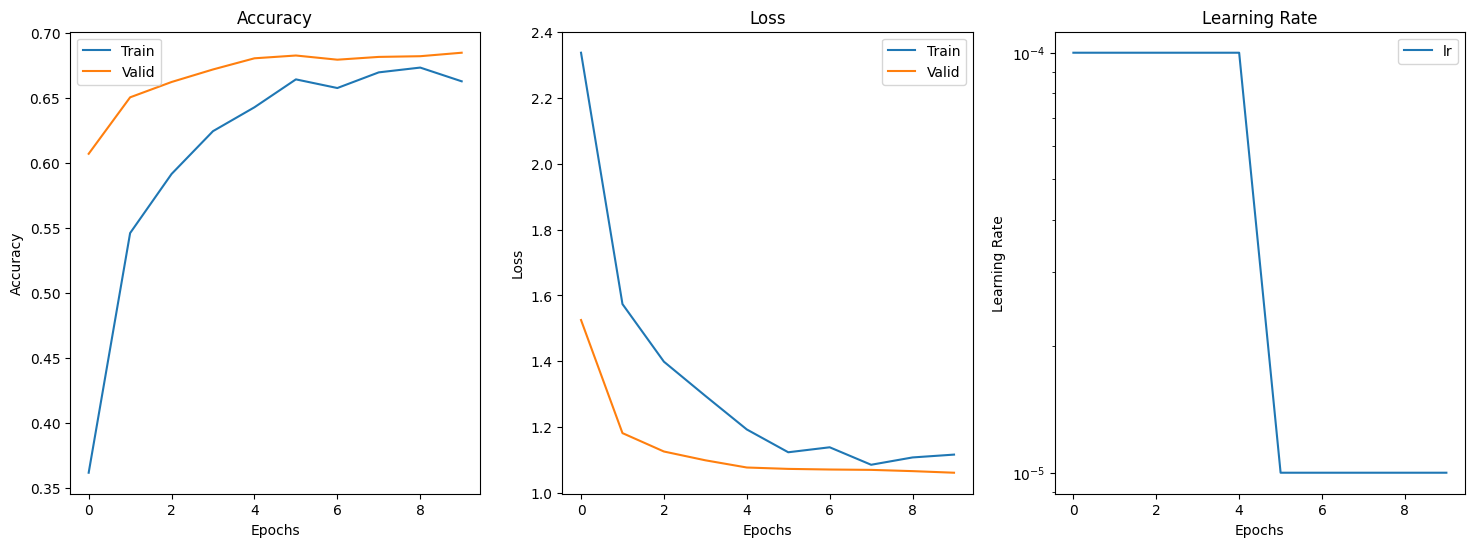

<Figure size 640x480 with 0 Axes>

In [78]:
plot_loss_accuracy(history_tl,
                   save_dir = FIGURES_DIR,
                   save_name = f'acc_loss_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_filt.png')

SUMMARY history
Final train accuracy: 0.6627252697944641
Final train loss: 1.1171075105667114
Final valid accuracy: 0.6847184896469116
Final valid loss: 1.0621414184570312
======Test======
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step

2026-01-07 10:47:50.923090: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 10:47:51.024469: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 10:47:51.128429: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 10:47:51.232155: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 10:47:51.333696: E external/local_xla/xla/stream_

30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 517ms/step


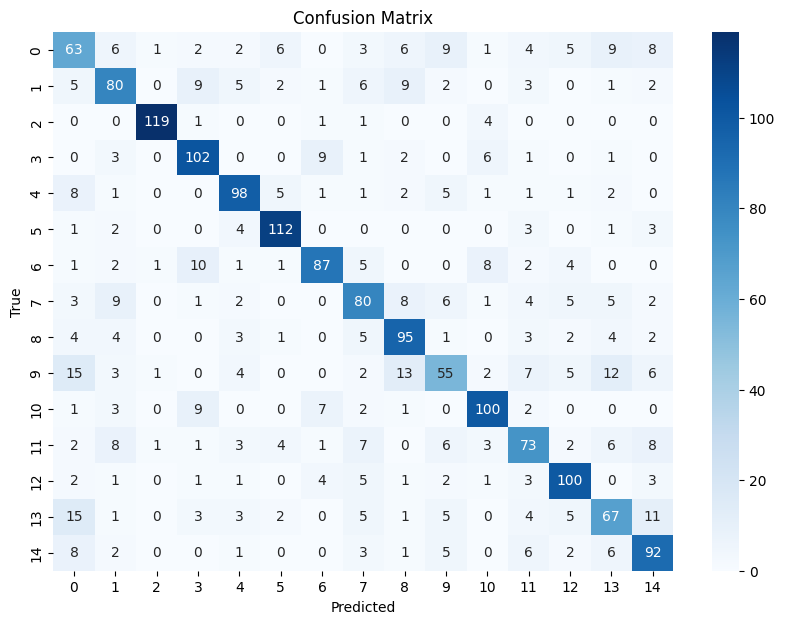

{
  "accuracy": 0.7067307692307693,
  "precision": 0.7041090731267207,
  "recall": 0.7063377468879319,
  "f1": 0.7039470333822667,
  "top_3_accuracy": 0.8969017094017094,
  "top_5_accuracy": 0.9545940170940171
}


In [79]:
print("SUMMARY history")
print(f'Final train accuracy: {history_tl.history["accuracy"][-1]}')
print(f'Final train loss: {history_tl.history["loss"][-1]}')
print(f'Final valid accuracy: {history_tl.history["val_accuracy"][-1]}')
print(f'Final valid loss: {history_tl.history["val_loss"][-1]}')


print("======Test======")
y_true = ds_filtered['test']['labels']
y_pred = model.predict(tf_ds_test)
results_tl = eval_predicts(y_true, np.argmax(y_pred, axis=1), y_pred, k_values=[3,5],
        save_dir=FIGURES_DIR,
        save_name=f'cm_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_filt_test.png')
print(json.dumps(results_tl, indent=2))

In [80]:
LEARNING_RATE_FT = 1e-5
EPOCHS_FT = 10

In [81]:
history_ft, model, n_params_ft, n_trainable_ft = train_ft(
    base_model,
    model,
    tf_ds_train,
    tf_ds_valid,
    epochs=EPOCHS_FT,
    learning_rate = LEARNING_RATE_FT,
    loss=LOSS,
    optimizer=OPTIMIZER,
    callbacks=callbacks
)

Number of parameters: 11580222
Number of non-trainable parameters: 175663
Number of trainable parameters: 11404599
Training model...

Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 1/10


2026-01-07 10:48:21.936262: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 10:48:22.040976: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 10:48:22.143402: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 10:48:22.248116: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 10:48:22.352102: E external/local_xla/xla/stream_

136/137 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.6808 - loss: 1.0695

2026-01-07 10:49:30.940727: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 10:49:31.038160: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


137/137 ━━━━━━━━━━━━━━━━━━━━ 123s 546ms/step - accuracy: 0.6802 - loss: 1.0694 - val_accuracy: 0.7040 - val_loss: 1.0057 - learning_rate: 1.0000e-05

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 2/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 46s 334ms/step - accuracy: 0.7072 - loss: 0.9918 - val_accuracy: 0.7212 - val_loss: 0.9705 - learning_rate: 1.0000e-05

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 3/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 42s 308ms/step - accuracy: 0.7226 - loss: 0.9252 - val_accuracy: 0.7282 - val_loss: 0.9433 - learning_rate: 1.0000e-05

Epoch 4: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 4/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 45s 325ms/step - accuracy: 0.7433 - loss: 0.8529 - val_accuracy: 0.7410 - val_loss: 0.9251 - learning_rate: 1.0000e-05

Epoch 5: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 5/10
137/137 ━━━━━━━━━━━━━━━━━━━━ 43s 317ms/step

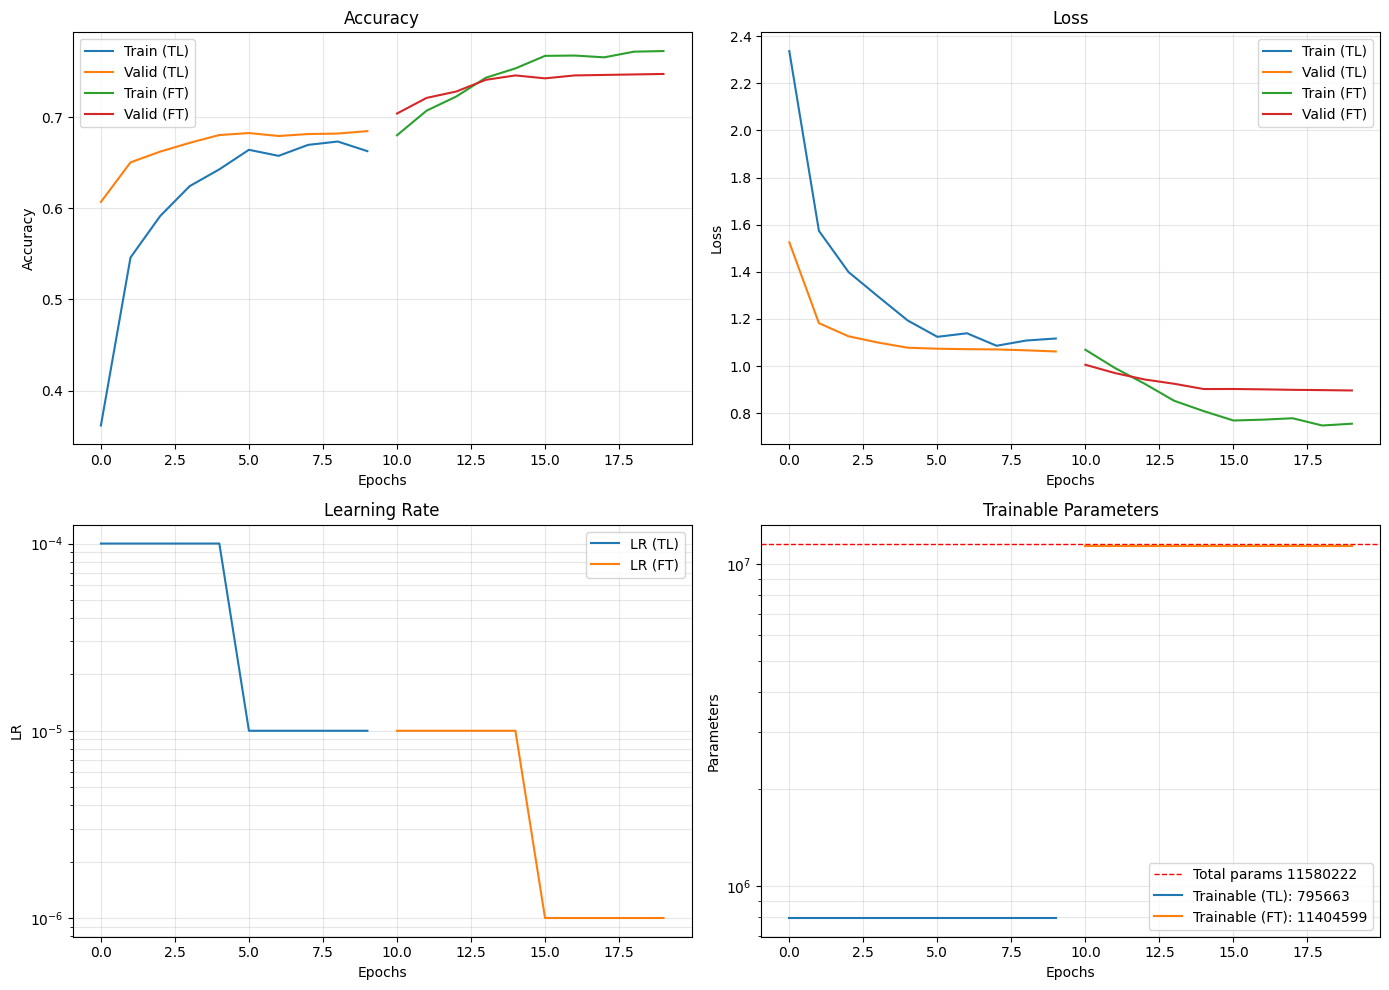

In [84]:
plot_loss_accuracy_tl_ft(history_tl,history_ft, n_trainable_tl, n_trainable_ft, n_params_tl,
                   save_dir = FIGURES_DIR,
                   save_name = f'acc_loss_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_filt.png')

SUMMARY history
Final train accuracy: 0.7725864052772522
Final train loss: 0.755669891834259
Final valid accuracy: 0.7474530935287476
Final valid loss: 0.8966558575630188
======Test======
30/30 ━━━━━━━━━━━━━━━━━━━━ 14s 302ms/step


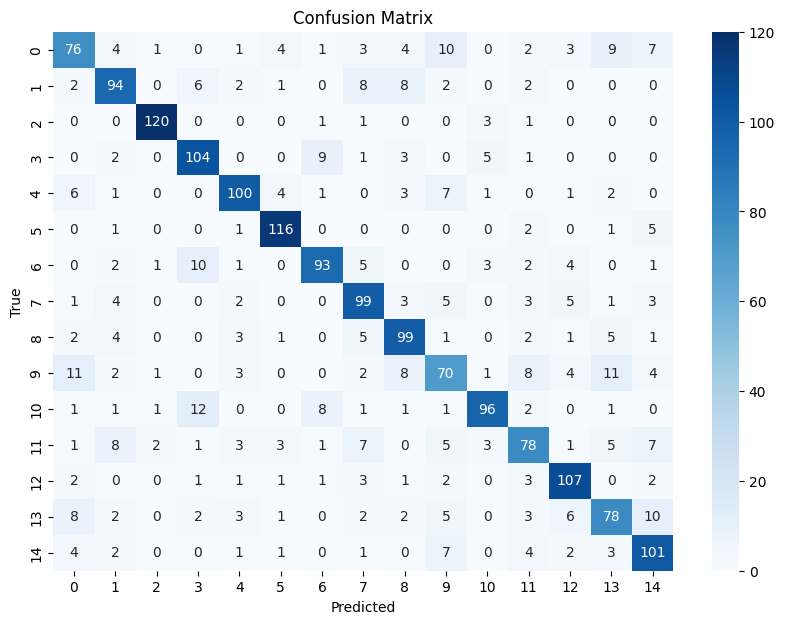

{
  "accuracy": 0.7644230769230769,
  "precision": 0.7632379604391275,
  "recall": 0.7640598613874131,
  "f1": 0.7625943877801614,
  "top_3_accuracy": 0.9204059829059829,
  "top_5_accuracy": 0.9642094017094017
}


In [83]:
print("SUMMARY history")
print(f'Final train accuracy: {history_ft.history["accuracy"][-1]}')
print(f'Final train loss: {history_ft.history["loss"][-1]}')
print(f'Final valid accuracy: {history_ft.history["val_accuracy"][-1]}')
print(f'Final valid loss: {history_ft.history["val_loss"][-1]}')


print("======Test======")
y_true = ds_filtered['test']['labels']
y_pred = model.predict(tf_ds_test)
results_ft = eval_predicts(y_true, np.argmax(y_pred, axis=1), y_pred, k_values=[3,5],
        save_dir=FIGURES_DIR,
        save_name=f'cm_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_filt_test.png')
print(json.dumps(results_ft, indent=2))

Efficientnet b3 sufre mucha sobreespecialización en los datos

## Escenario 3: Entrenamiento del dataset reducido y sin filtrar.

En este ejemplo se evaluará sobre un solo experimetno el mejor modelo obtenido en sobre el conjunto de datos reducido y filtrado para ver si el proceso de limpieza de datos realmente tuvo impacto en una mejora de resultados.

In [87]:
ds_reduced = ds.copy()

In [88]:
target_labels = [0,1,2,3,4]
ds_reduced["train"] = ds_reduced["train"].filter(lambda x: x["labels"] in target_labels)
ds_reduced["val"] = ds_reduced["val"].filter(lambda x: x["labels"] in target_labels)
ds_reduced["test"] = ds_reduced["test"].filter(lambda x: x["labels"] in target_labels)

In [89]:
print(f"Datos conjunto de entrenamiento:")
print(f"Original: {ds['train'].shape[0]} | Filtrado: {ds_filtered['train'].shape[0]} | Reducido - Filtrado: {ds_reduced_filtered['train'].shape[0]} | Reducido: {ds_reduced['train'].shape[0]}")

print(f"Datos conjunto de valid:")
print(f"Original: {ds['val'].shape[0]} | Filtrado: {ds_filtered['val'].shape[0]} | Reducido - Filtrado: {ds_reduced_filtered['val'].shape[0]} | Reducido: {ds_reduced['val'].shape[0]}")

print(f"Datos conjunto de test:")
print(f"Original: {ds['test'].shape[0]} | Filtrado: {ds_filtered['test'].shape[0]} | Reducido - Filtrado: {ds_reduced_filtered['test'].shape[0]} | Reducido: {ds_reduced['test'].shape[0]}")

print(f"Datos conjunto de noise:")
print(f"Original: {ds['noise'].shape[0]} | Filtrado: {ds_filtered['noise'].shape[0]}")

Datos conjunto de entrenamiento:
Original: 8819 | Filtrado: 8711 | Reducido - Filtrado: 2907 | Reducido: 2940
Datos conjunto de valid:
Original: 1891 | Filtrado: 1865 | Reducido - Filtrado: 621 | Reducido: 630
Datos conjunto de test:
Original: 1890 | Filtrado: 1872 | Reducido - Filtrado: 627 | Reducido: 630
Datos conjunto de noise:
Original: 5400 | Filtrado: 5344


### Experimento 1

El experimento se realizará sobre el modelo VGG16 y con Batch Size de 64

In [143]:
NAME_MODEL = 'vgg16'
IMG_SIZE = 224
BATCH_SIZE = 64
OPTIMIZER = 'Adam'
LOSS = 'sparse_categorical_crossentropy'
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = len(target_labels)
LEARNING_RATE_TL = 1e-4
EPOCHS_TL = 10

In [144]:
tf_ds_train,  tf_ds_valid, tf_ds_test = preprocess_hf_to_tf(
    ds_reduced,
    BATCH_SIZE, NAME_MODEL,
    column = 'image',
    label_column='labels')

In [145]:
base_model = load_model(
    name_model = NAME_MODEL,
    input_shape = (IMG_SIZE, IMG_SIZE, 3)
)

In [146]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu',kernel_regularizer=l2(5e-5))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

output = Dense(NUM_CLASSES, activation='softmax')(x)
model = keras.Model(inputs=base_model.input, outputs=output)

In [147]:
history_tl, model, n_params_tl, n_trainable_tl = train_tl(
    base_model,
    model,
    tf_ds_train,
    tf_ds_valid,
    epochs=EPOCHS_TL,
    learning_rate = LEARNING_RATE_TL,
    loss=LOSS,
    optimizer=OPTIMIZER,
    callbacks=callbacks
)

Number of parameters: 14981957
Number of non-trainable parameters: 14715714
Number of trainable parameters: 266245
Training model...

Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 1/10
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.3277 - loss: 2.0160

2026-01-05 19:54:22.311725: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-05 19:54:22.495618: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1127', 4 bytes spill stores, 4 bytes spill loads

2026-01-05 19:54:22.663260: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1787', 108 bytes spill stores, 108 bytes spill loads

2026-01-05 19:54:22.715078: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1127', 52 by

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.3295 - loss: 2.0092

2026-01-05 19:54:31.600812: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_253', 4 bytes spill stores, 4 bytes spill loads

2026-01-05 19:54:31.846954: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_253', 52 bytes spill stores, 52 bytes spill loads



46/46 ━━━━━━━━━━━━━━━━━━━━ 31s 621ms/step - accuracy: 0.4095 - loss: 1.7010 - val_accuracy: 0.6079 - val_loss: 1.1242 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 18s 390ms/step - accuracy: 0.5966 - loss: 1.1455 - val_accuracy: 0.7127 - val_loss: 0.7769 - learning_rate: 1.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 15s 333ms/step - accuracy: 0.6680 - loss: 0.9168 - val_accuracy: 0.7444 - val_loss: 0.6747 - learning_rate: 1.0000e-04

Epoch 4: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 14s 309ms/step - accuracy: 0.7122 - loss: 0.7986 - val_accuracy: 0.7746 - val_loss: 0.6287 - learning_rate: 1.0000e-04

Epoch 5: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 19s 404ms/step - accuracy

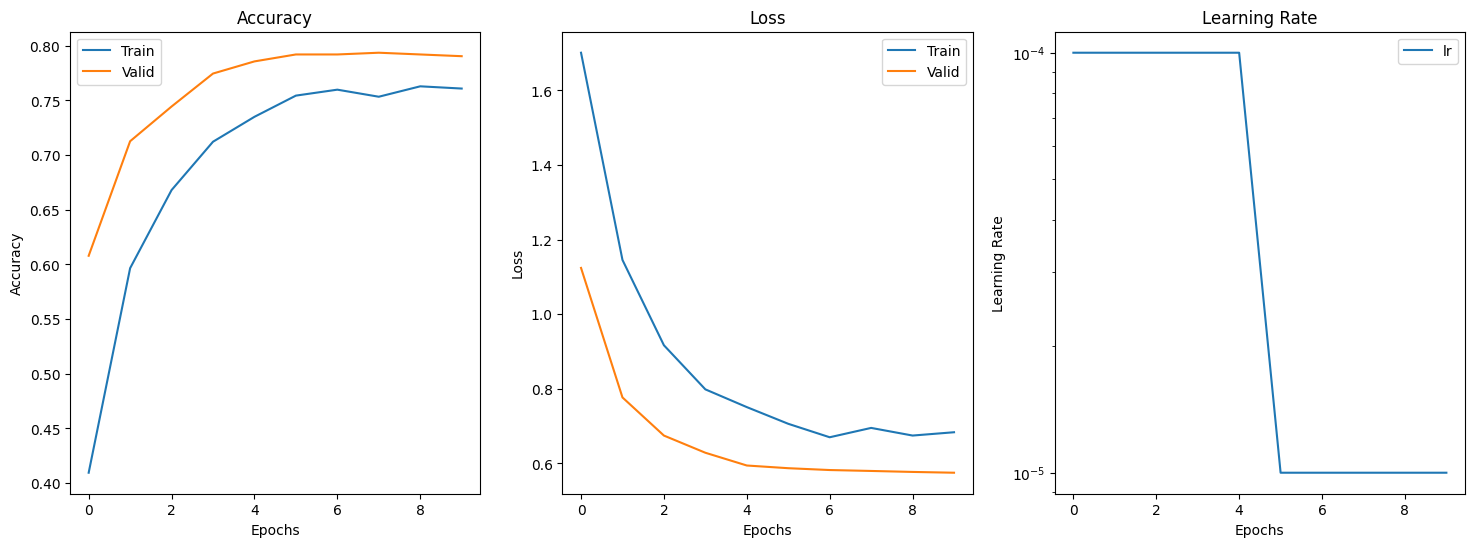

<Figure size 640x480 with 0 Axes>

In [148]:
plot_loss_accuracy(history_tl,
                   save_dir = FIGURES_DIR,
                   save_name = f'acc_loss_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red.png')

SUMMARY history
Final train accuracy: 0.7608843445777893
Final train loss: 0.683651328086853
Final test accuracy: 0.7904762029647827
Final test loss: 0.5751547813415527
======Test======
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 182ms/step


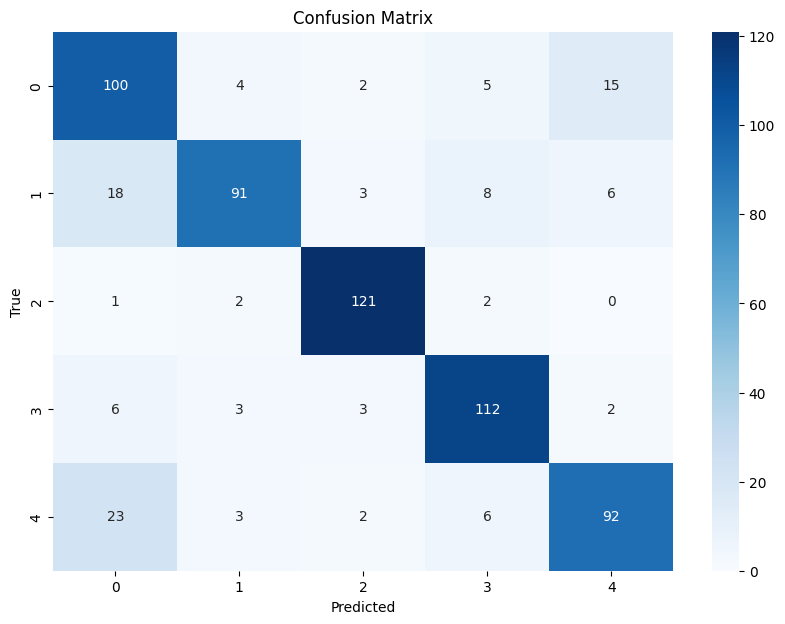

{
  "accuracy": 0.819047619047619,
  "precision": 0.8249880413204085,
  "recall": 0.819047619047619,
  "f1": 0.8189342831830411,
  "top_3_accuracy": 0.9825396825396825
}


In [ ]:
print("SUMMARY history")
print(f'Final train accuracy: {history_tl.history["accuracy"][-1]}')
print(f'Final train loss: {history_tl.history["loss"][-1]}')
print(f'Final valid accuracy: {history_tl.history["val_accuracy"][-1]}')
print(f'Final valid loss: {history_tl.history["val_loss"][-1]}')


print("======Test======")
y_true = ds_reduced['test']['labels']
y_pred = model.predict(tf_ds_test)
results_tl = eval_predicts(y_true, np.argmax(y_pred, axis=1), y_pred, k_values=[3],
        save_dir=FIGURES_DIR,
        save_name=f'cm_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_test.png')
print(json.dumps(results_tl, indent=2))

In [150]:
LEARNING_RATE_FT = 1e-5
EPOCHS_FT = 10

In [151]:
history_ft, model, n_params_ft, n_trainable_ft = train_ft(
    base_model,
    model,
    tf_ds_train,
    tf_ds_valid,
    epochs=EPOCHS_FT,
    learning_rate = LEARNING_RATE_FT,
    loss=LOSS,
    optimizer=OPTIMIZER,
    callbacks=callbacks
)

Number of parameters: 14981957
Number of non-trainable parameters: 1026
Number of trainable parameters: 14980933
Training model...

Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 1/10
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.7742 - loss: 0.6600

2026-01-05 19:57:58.371247: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng57{k2=7,k13=0,k14=1,k18=1,k23=0} for conv (f32[64,3,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[60,3,224,224]{3,2,1,0}, f32[60,64,224,224]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardFilter", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]} is taking a while...
2026-01-05 19:57:58.874036: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.502870472s
Trying algorithm eng57{k2=7,k13=0,k14=1,k18=1,k23=0} for conv (f32[64,3,3,3]{3,2,1,0}, u8[0]{0}) custom-call(f32[60,3,224,224]{3,2,1,0}, f32[60,64,224,224]{3,2,1,0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__

46/46 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.7786 - loss: 0.6440 - val_accuracy: 0.8000 - val_loss: 0.5871 - learning_rate: 1.0000e-05

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 30s 643ms/step - accuracy: 0.8071 - loss: 0.5531 - val_accuracy: 0.8476 - val_loss: 0.4817 - learning_rate: 1.0000e-05

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 23s 509ms/step - accuracy: 0.8303 - loss: 0.4965 - val_accuracy: 0.8540 - val_loss: 0.4902 - learning_rate: 1.0000e-05

Epoch 4: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 26s 563ms/step - accuracy: 0.8490 - loss: 0.4494 - val_accuracy: 0.8524 - val_loss: 0.4474 - learning_rate: 1.0000e-05

Epoch 5: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 28s 607ms/step - accuracy: 0

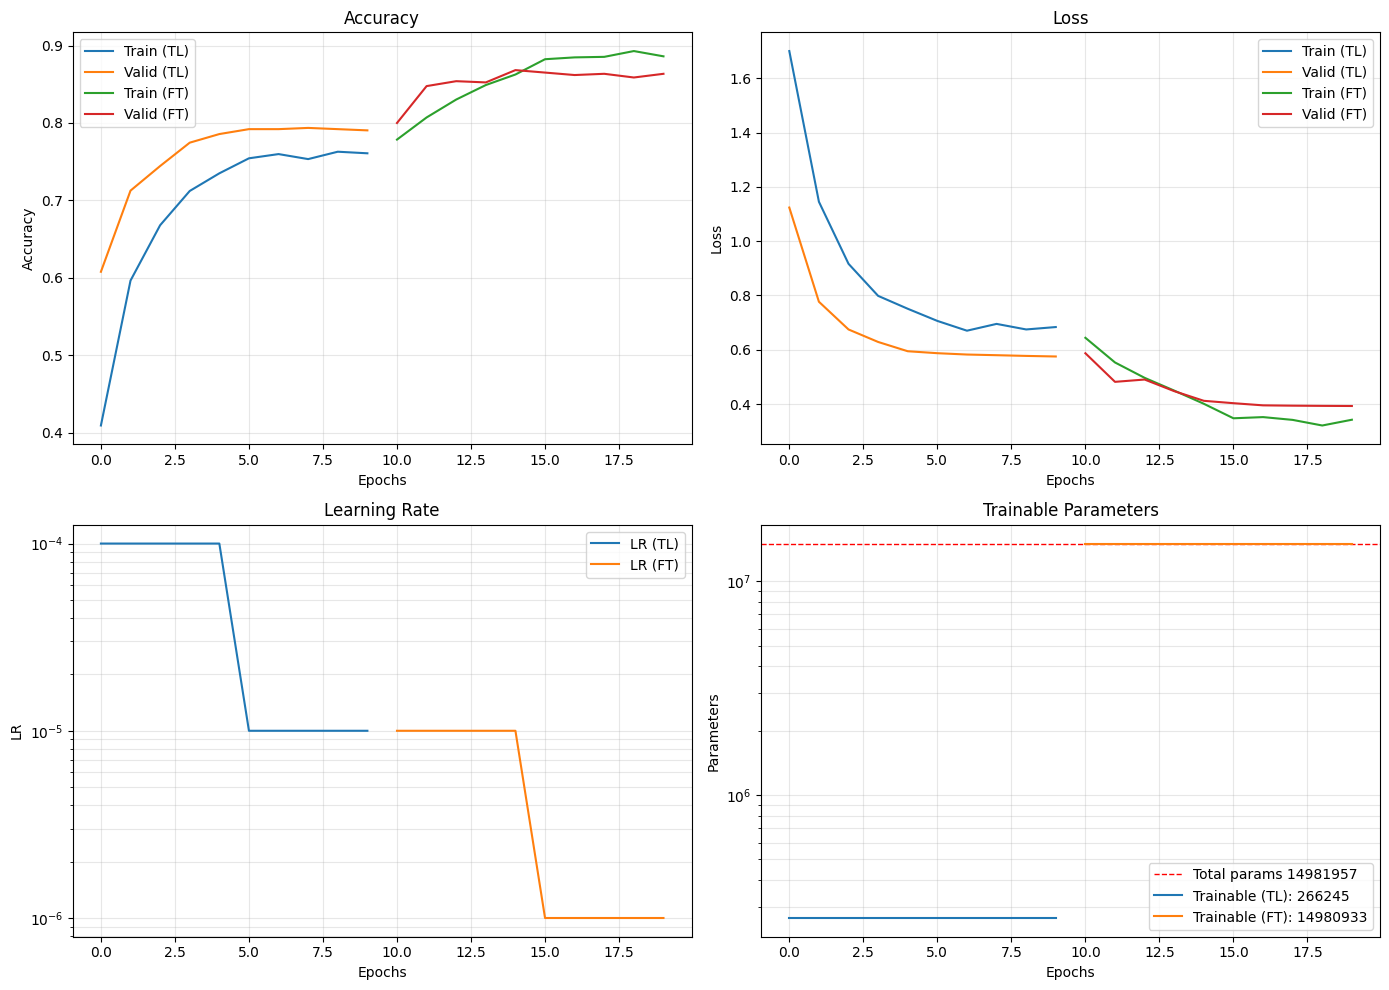

In [152]:
plot_loss_accuracy_tl_ft(history_tl,history_ft, n_trainable_tl, n_trainable_ft, n_params_tl,
                   save_dir = FIGURES_DIR,
                   save_name = f'acc_loss_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red.png')

SUMMARY history
Final train accuracy: 0.8860543966293335
Final train loss: 0.34201574325561523
Final test accuracy: 0.8634920716285706
Final test loss: 0.3926439583301544
======Test======
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 180ms/step


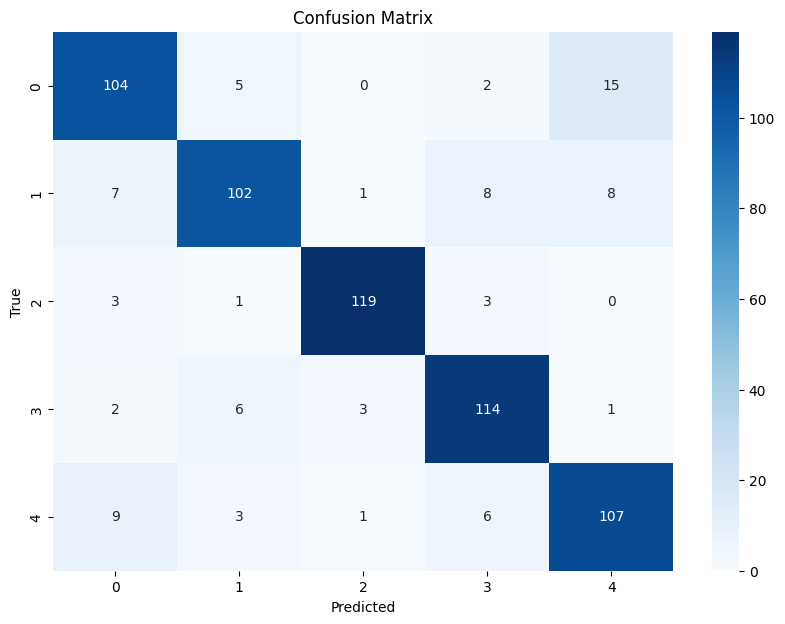

{
  "accuracy": 0.8666666666666667,
  "precision": 0.8674818082844677,
  "recall": 0.8666666666666666,
  "f1": 0.8666370274030507,
  "top_3_accuracy": 0.9904761904761905
}


In [ ]:
print("SUMMARY history")
print(f'Final train accuracy: {history_ft.history["accuracy"][-1]}')
print(f'Final train loss: {history_ft.history["loss"][-1]}')
print(f'Final valid accuracy: {history_ft.history["val_accuracy"][-1]}')
print(f'Final valid loss: {history_ft.history["val_loss"][-1]}')


print("======Test======")
y_true = ds_reduced['test']['labels']
y_pred = model.predict(tf_ds_test)
results_ft = eval_predicts(y_true, np.argmax(y_pred, axis=1), y_pred, k_values=[3],
        save_dir=FIGURES_DIR,
        save_name=f'cm_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_test.png')
print(json.dumps(results_ft, indent=2))

Este modelo al no haber filtrado los datos tiene una performance ligeramente peor que en el Experimento 3 del Escenario 1.

### Experimento 2

Se prueba con EfficientNetB0


In [92]:
NAME_MODEL = 'efficientnetb0'
IMG_SIZE = 224
BATCH_SIZE = 64
OPTIMIZER = 'Adam'
LOSS = 'sparse_categorical_crossentropy'
AUTOTUNE = tf.data.AUTOTUNE
NUM_CLASSES = len(target_labels)
LEARNING_RATE_TL = 1e-4
EPOCHS_TL = 10

In [93]:
tf_ds_train,  tf_ds_valid, tf_ds_test = preprocess_hf_to_tf(
    ds_reduced,
    BATCH_SIZE, NAME_MODEL,
    column = 'image',
    label_column='labels')

In [94]:
base_model = load_model(
    name_model = NAME_MODEL,
    input_shape = (IMG_SIZE, IMG_SIZE, 3)
)

In [95]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu',kernel_regularizer=l2(5e-5))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

output = Dense(NUM_CLASSES, activation='softmax')(x)
model = keras.Model(inputs=base_model.input, outputs=output)

In [96]:
history_tl, model, n_params_tl, n_trainable_tl = train_tl(
    base_model,
    model,
    tf_ds_train,
    tf_ds_valid,
    epochs=EPOCHS_TL,
    learning_rate = LEARNING_RATE_TL,
    loss=LOSS,
    optimizer=OPTIMIZER,
    callbacks=callbacks
)

Number of parameters: 4710056
Number of non-trainable parameters: 4050615
Number of trainable parameters: 659461
Training model...

Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 1/10
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.4627 - loss: 1.6135

2026-01-07 10:59:48.991530: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-01-07 10:59:49.128253: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_10394', 4 bytes spill stores, 4 bytes spill loads

2026-01-07 10:59:49.305398: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_11150', 104 bytes spill stores, 104 bytes spill loads

2026-01-07 10:59:49.357600: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_10394', 52

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 489ms/step - accuracy: 0.4654 - loss: 1.6050

2026-01-07 11:00:05.760577: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2082', 4 bytes spill stores, 4 bytes spill loads

2026-01-07 11:00:06.029698: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2082', 52 bytes spill stores, 52 bytes spill loads

2026-01-07 11:00:09.801124: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 11:00:09.901075: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 11:00:10.322619: E external/local_xla/xla

46/46 ━━━━━━━━━━━━━━━━━━━━ 48s 790ms/step - accuracy: 0.5878 - loss: 1.2213 - val_accuracy: 0.7540 - val_loss: 0.8366 - learning_rate: 1.0000e-04

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 216ms/step - accuracy: 0.7738 - loss: 0.6621 - val_accuracy: 0.8254 - val_loss: 0.6471 - learning_rate: 1.0000e-04

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step - accuracy: 0.8007 - loss: 0.5835 - val_accuracy: 0.8476 - val_loss: 0.5364 - learning_rate: 1.0000e-04

Epoch 4: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 234ms/step - accuracy: 0.8238 - loss: 0.5397 - val_accuracy: 0.8571 - val_loss: 0.4639 - learning_rate: 1.0000e-04

Epoch 5: LearningRateScheduler setting learning rate to 9.999999747378752e-05.
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 247ms/step - accuracy

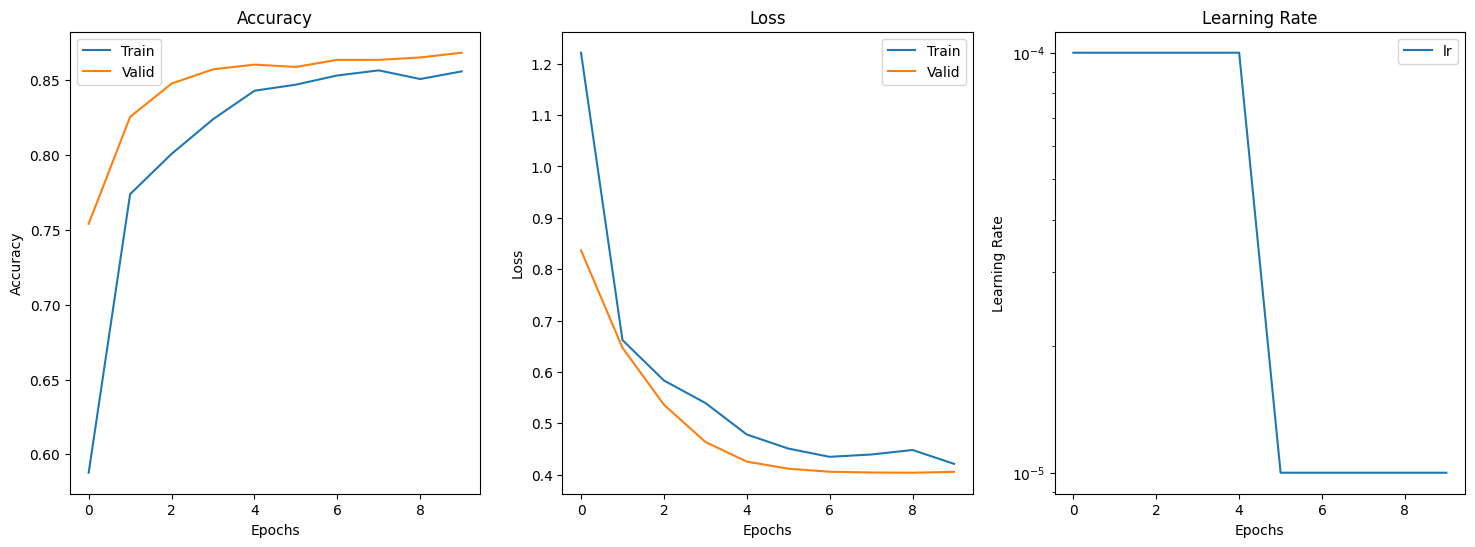

<Figure size 640x480 with 0 Axes>

In [97]:
plot_loss_accuracy(history_tl,
                   save_dir = FIGURES_DIR,
                   save_name = f'acc_loss_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red.png')

SUMMARY history
Final train accuracy: 0.8557823300361633
Final train loss: 0.4212683141231537
Final valid accuracy: 0.8682539463043213
Final valid loss: 0.405668169260025
======Test======
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 460ms/step


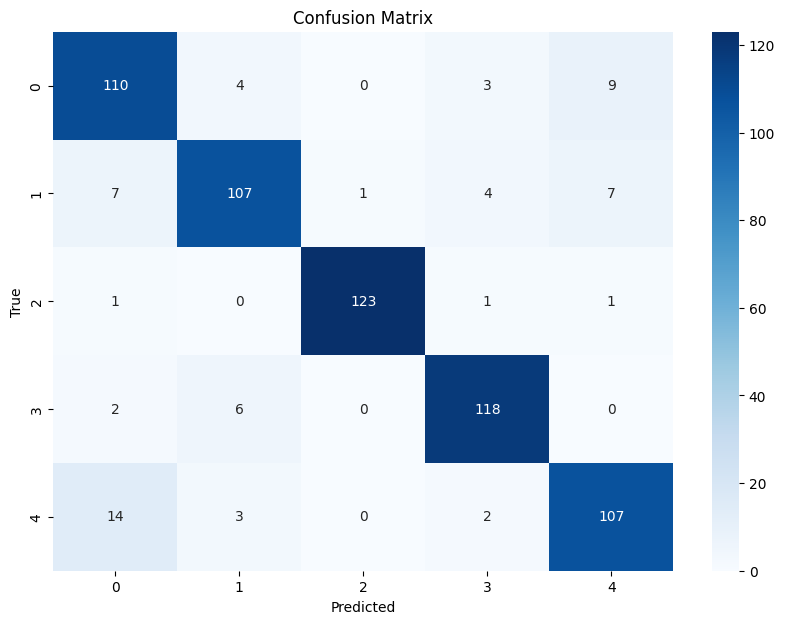

{
  "accuracy": 0.8968253968253969,
  "precision": 0.8978551797464291,
  "recall": 0.8968253968253969,
  "f1": 0.8970412807217109,
  "top_3_accuracy": 0.9904761904761905
}


In [98]:
print("SUMMARY history")
print(f'Final train accuracy: {history_tl.history["accuracy"][-1]}')
print(f'Final train loss: {history_tl.history["loss"][-1]}')
print(f'Final valid accuracy: {history_tl.history["val_accuracy"][-1]}')
print(f'Final valid loss: {history_tl.history["val_loss"][-1]}')


print("======Test======")
y_true = ds_reduced['test']['labels']
y_pred = model.predict(tf_ds_test)
results_tl = eval_predicts(y_true, np.argmax(y_pred, axis=1), y_pred, k_values=[3],
        save_dir=FIGURES_DIR,
        save_name=f'cm_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_test.png')
print(json.dumps(results_tl, indent=2))

In [99]:
LEARNING_RATE_FT = 1e-5
EPOCHS_FT = 10

In [100]:
history_ft, model, n_params_ft, n_trainable_ft = train_ft(
    base_model,
    model,
    tf_ds_train,
    tf_ds_valid,
    epochs=EPOCHS_FT,
    learning_rate = LEARNING_RATE_FT,
    loss=LOSS,
    optimizer=OPTIMIZER,
    callbacks=callbacks
)

Number of parameters: 4710056
Number of non-trainable parameters: 85083
Number of trainable parameters: 4624993
Training model...

Epoch 1: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 1/10


2026-01-07 11:02:10.018786: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 11:02:10.108827: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 11:02:10.209498: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 11:02:10.312069: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 11:02:10.412579: E external/local_xla/xla/stream_

45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.8535 - loss: 0.4311

2026-01-07 11:02:44.322179: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 11:02:44.419854: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 11:02:44.522718: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 11:02:44.621090: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-07 11:02:44.723905: E external/local_xla/xla/stream_

46/46 ━━━━━━━━━━━━━━━━━━━━ 76s 923ms/step - accuracy: 0.8602 - loss: 0.4227 - val_accuracy: 0.8714 - val_loss: 0.3938 - learning_rate: 1.0000e-05

Epoch 2: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 2/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 244ms/step - accuracy: 0.8748 - loss: 0.3865 - val_accuracy: 0.8778 - val_loss: 0.3913 - learning_rate: 1.0000e-05

Epoch 3: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 3/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 251ms/step - accuracy: 0.8888 - loss: 0.3532 - val_accuracy: 0.8825 - val_loss: 0.3801 - learning_rate: 1.0000e-05

Epoch 4: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 4/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 11s 247ms/step - accuracy: 0.8861 - loss: 0.3446 - val_accuracy: 0.8825 - val_loss: 0.3780 - learning_rate: 1.0000e-05

Epoch 5: LearningRateScheduler setting learning rate to 9.999999747378752e-06.
Epoch 5/10
46/46 ━━━━━━━━━━━━━━━━━━━━ 12s 252ms/step - accuracy

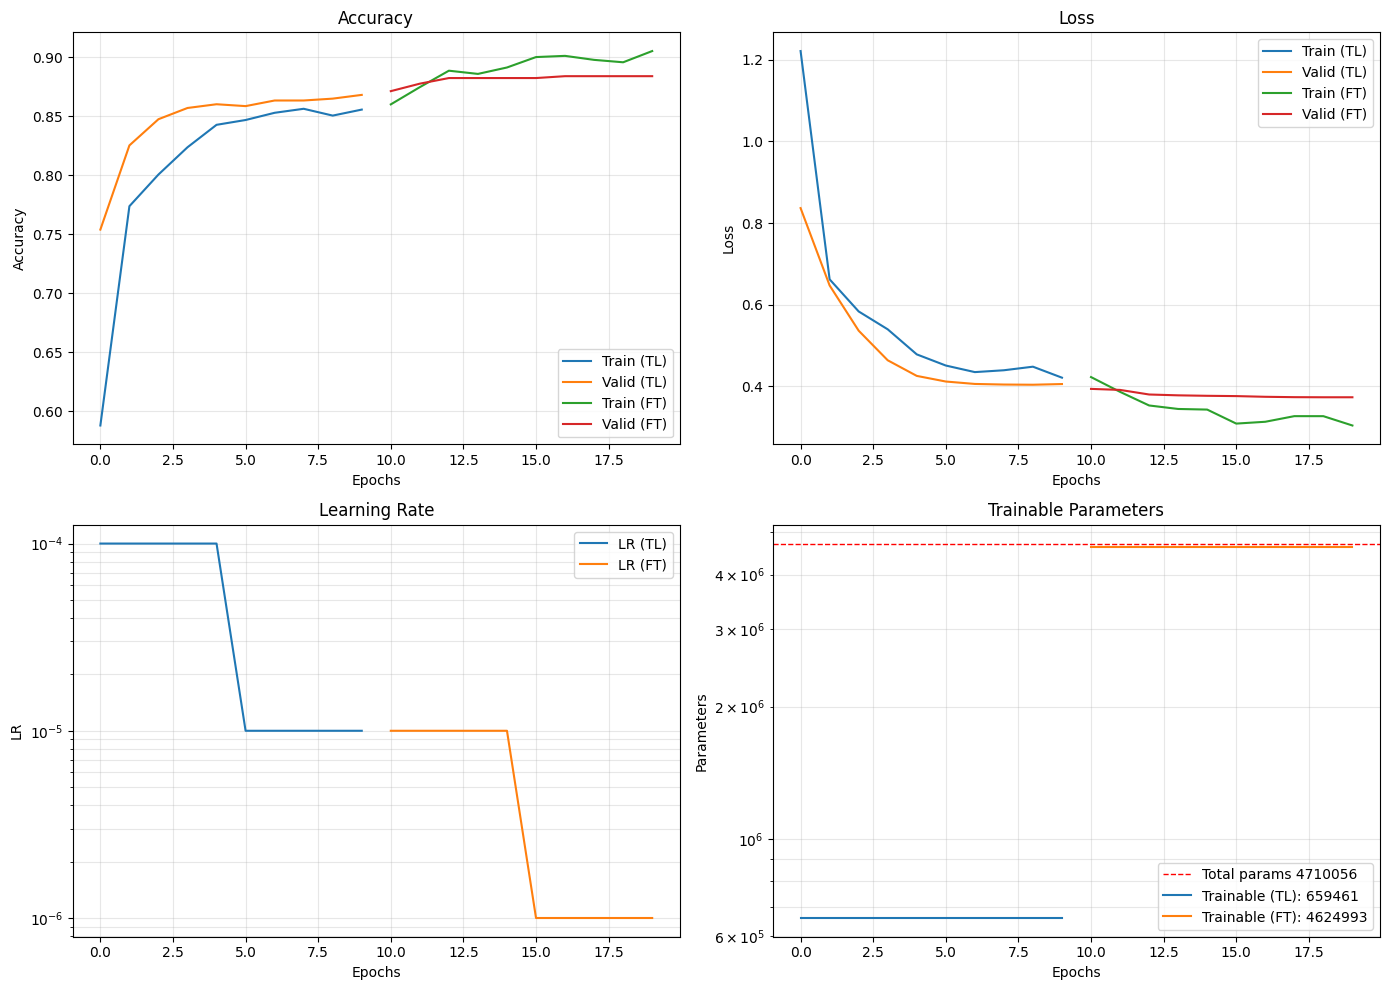

In [101]:
plot_loss_accuracy_tl_ft(history_tl,history_ft, n_trainable_tl, n_trainable_ft, n_params_tl,
                   save_dir = FIGURES_DIR,
                   save_name = f'acc_loss_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red.png')

SUMMARY history
Final train accuracy: 0.9054421782493591
Final train loss: 0.30412599444389343
Final valid accuracy: 0.8841269612312317
Final valid loss: 0.3732726573944092
======Test======
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 460ms/step


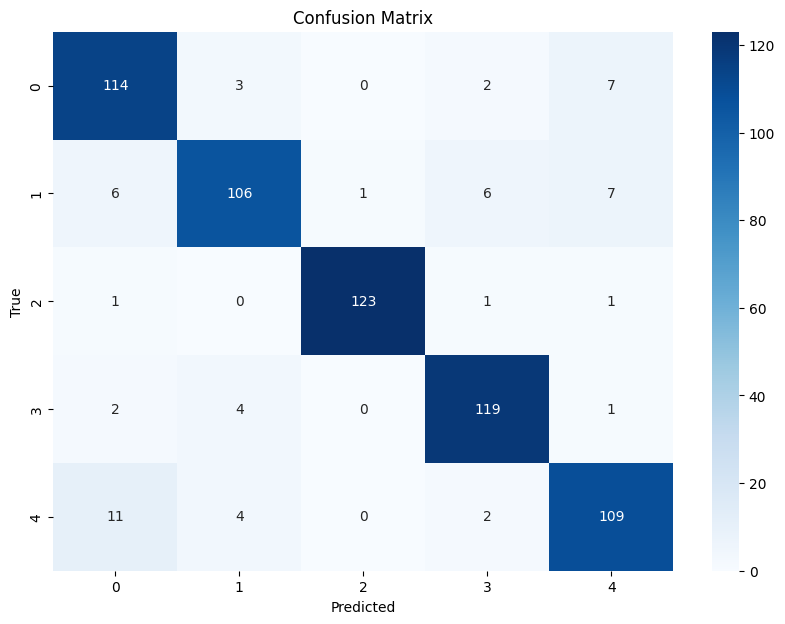

{
  "accuracy": 0.9063492063492063,
  "precision": 0.907209854779041,
  "recall": 0.9063492063492063,
  "f1": 0.9063128913753028,
  "top_3_accuracy": 0.9936507936507937
}


In [102]:
print("SUMMARY history")
print(f'Final train accuracy: {history_ft.history["accuracy"][-1]}')
print(f'Final train loss: {history_ft.history["loss"][-1]}')
print(f'Final valid accuracy: {history_ft.history["val_accuracy"][-1]}')
print(f'Final valid loss: {history_ft.history["val_loss"][-1]}')


print("======Test======")
y_true = ds_reduced['test']['labels']
y_pred = model.predict(tf_ds_test)
results_ft = eval_predicts(y_true, np.argmax(y_pred, axis=1), y_pred, k_values=[3],
        save_dir=FIGURES_DIR,
        save_name=f'cm_{NAME_MODEL}_bs_{BATCH_SIZE}_{OPTIMIZER}_ds_red_test.png')
print(json.dumps(results_ft, indent=2))